# 07 ¿Cómo contrata la Alcaldía de Barrancabermeja?

**La gran idea.** La Alcaldía contrata a miles de personas con contratos cortos, que se firman en oleadas marcadas por el
calendario del presupuesto y de las elecciones. Las personas encadenan un contrato tras otro, con semanas sin contrato entre uno y otro.

**Cómo está contada.** El cuaderno sigue una estructura de relato en tres actos, que va de lo general a lo particular:

| Parte | Pregunta guía |
|---|---|
| Prólogo | ¿Qué es un CPS y cómo leer esto? Retrato de una persona contratista típica (compuesto, no real). |
| 1  El tamaño | ¿Cuántos contratos y personas maneja cada alcalde? ¿Cuánto dinero? |
| 2  La vida de un contratista | ¿Cuánto dura un contrato? ¿Quiénes son los más estables? ¿Cuánto tarda la renovación? |
| 3 El dinero en el bolsillo | ¿Cuánto pacta un profesional y un apoyo con cada alcalde? ¿Cómo se reparte? |
| 4 Varias puertas | ¿Cuántas personas contratan con varias entidades? |
| 5 El reloj político | Calendario de firmas, Ley de Garantías, cambio de gobierno, rotación. |
| 6 Más allá de las personas | Dependencias, obras, convenios y empresas. |
| 7 Lo que no salta a la vista | Hallazgos que solo aparecen al exprimir los datos. |
| Prueba de estrés | ¿Se caen las conclusiones si se cambian los supuestos? |
| Epílogo | De dónde salen los datos, qué se hizo, por qué y con qué herramientas. |

Cada respuesta trae una tabla, una gráfica con título que ya dice la conclusión
**qué no significa**, su **nivel de evidencia** (dato descriptivo, patrón estadístico o anomalía que requiere documentos). Ningún nombre ni documento de contratista sale en productos públicos.

In [1]:
import base64, html, re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

RAIZ = Path.cwd().resolve()
# Busca la raíz del proyecto (carpeta que contiene funciones/secop_utils.py)
for _p in [RAIZ, *RAIZ.parents][:6]:
    if (_p / "funciones" / "secop_utils.py").exists():
        RAIZ = _p
        break
else:
    raise FileNotFoundError("No se encontró funciones/secop_utils.py; abra el notebook dentro del proyecto")
sys.path.insert(0, str(RAIZ / "funciones"))
import secop_utils as su

VERSION_NB = "07.v5.0"
ETAPA = "07_historia"
SALIDA = su.carpeta_etapa(RAIZ, ETAPA)
GRAF, TAB, INTERNO = SALIDA / "graficos", SALIDA / "tablas", SALIDA / "uso_interno_verificacion"
for d in (GRAF, TAB, INTERNO):
    d.mkdir(exist_ok=True)
    for viejo in d.glob("*"):  # limpia salidas de ejecuciones anteriores de esta etapa
        if viejo.is_file():
            viejo.unlink()

man01, r01 = su.abrir_etapa(RAIZ, "01_base")
man03, r03 = su.abrir_etapa(RAIZ, "03_cps")
man04, r04 = su.abrir_etapa(RAIZ, "04_comparabilidad")
man05, r05 = su.abrir_etapa(RAIZ, "05_patrones")
man06, r06 = su.abrir_etapa(RAIZ, "06_hallazgos")

b = su.leer_csv(r03["base_cps"])
ipc = su.leer_csv(r04["ipc"])
cat06 = su.leer_csv(r06["catalogo_hallazgos"]).set_index("id")
no_sost06 = su.leer_csv(r06["afirmaciones_no_sostenibles"])
robustez04 = su.leer_csv(r04["robustez"])
VALIDACION = man03["conteos"]["validacion_subtipo"]

## Utilidades: universos, ventanas, formato y registro de hallazgos

In [2]:
INICIO = pd.Timestamp("2021-04-01")        # primer mes con registro pleno de CPS en SECOP II (ver 01)
CAMBIO = pd.Timestamp("2024-01-01")        # posesión del nuevo alcalde
CORTE = b["fecha_firma"].max().normalize()  # última firma en la corrida congelada
MES_BASE = ipc["mes"].max()
IPC_BASE = float(ipc.loc[ipc["mes"].eq(MES_BASE), "ipc_indice"].iloc[0])
A, J = su.ADMINS
AZUL, NARANJA, GRIS, VERDE = su.COLORES[A], su.COLORES[J], su.COLORES["neutro"], "#1baf7a"
COLOR_GOB = {A: AZUL, J: NARANJA}
MESES_ES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
MESES_LARGOS = ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio", "agosto", "septiembre", "octubre",
                "noviembre", "diciembre"]
DIAS_ES = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
MES_DIAS = 30.4375
FUENTE = f"Fuente: SECOP II, datos.gov.co (jbjy-vk9h), firmas abr-2021 a {CORTE:%d-%m-%Y}. Cálculo propio."
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#9a9a95", "axes.labelcolor": "#333333",
                     "xtick.color": "#555555", "ytick.color": "#555555"})

# Ventanas: el gobierno completo observado (descriptivo, etapas distintas del mandato) y la ventana principal
# comparable del cuaderno 04 (enero–agosto del año 3). El año 2 no se usa: abril de 2021 es el mes de migración a SECOP II.
VENTANAS = pd.DataFrame([
    ["Gobierno completo observado", A, "2021-04-01", "2023-12-31"],
    ["Gobierno completo observado", J, "2024-01-01", str(CORTE.date())],
    ["Año 3 del mandato (ene–ago)", A, "2022-01-01", "2022-08-31"],
    ["Año 3 del mandato (ene–ago)", J, "2026-01-01", "2026-08-31"],
], columns=["ventana", "gobierno", "desde", "hasta"])
VENTANAS[["desde", "hasta"]] = VENTANAS[["desde", "hasta"]].apply(pd.to_datetime)
VENTANAS["meses"] = ((VENTANAS["hasta"] - VENTANAS["desde"]).dt.days + 1) / MES_DIAS
ORDEN_VENT = list(VENTANAS["ventana"].unique())
ROT_VENT = {"Gobierno completo observado": "Gobierno\ncompleto\n(33 y 32 meses)",
            "Año 3 del mandato (ene–ago)": "Año 3\nene–ago\n(2022 y 2026)"}


def en_ventana(df, fila, col="fecha_firma"):
    return df.loc[df[col].between(fila["desde"], fila["hasta"])]


def gobierno_de(fechas):
    return np.where(pd.Series(fechas).lt(CAMBIO).to_numpy(), A, J)


def con_real(df):
    # Pesos constantes por el IPC del mes de firma
    d = df.copy()
    d["mes"] = d["fecha_firma"].dt.to_period("M").dt.to_timestamp()
    d = d.merge(ipc, on="mes", how="left")
    d["valor_real"] = d["valor_contrato"] * IPC_BASE / d["ipc_indice"]
    d["valor_mensual_real"] = d["valor_mensual_equiv"] * IPC_BASE / d["ipc_indice"]
    return d


# Contratos válidos de la Alcaldía central firmados desde abril de 2021
central = con_real(b.loc[b["es_central"] & b["es_valido_general"] & b["fecha_firma"].ge(INICIO)])
central["anio"] = central["fecha_firma"].dt.year
central["gobierno"] = gobierno_de(central["fecha_firma"])
cps = central.loc[central["es_cps_estricto"] & central["apto_persona"]].copy()   # CPS de personas con identidad apta
PERSONA = "documento_identidad"
ANIO_PARCIAL = {2021: "abr–dic", CORTE.year: f"ene–{MESES_ES[CORTE.month - 1]}"}
ANIOS_COMPLETOS = list(range(INICIO.year + 1, CORTE.year))


def rotulo_anio(a):
    return f"{a}\n({ANIO_PARCIAL[a]})" if a in ANIO_PARCIAL else str(a)


def color_anio(a):
    return AZUL if a < CAMBIO.year else NARANJA


def es(texto):
    # Formato colombiano: 3,526.5 -> 3.526,5
    return re.sub(r"\d{1,3}(?:,\d{3})+(?:\.\d+)?|\d+\.\d+",
                  lambda m: m.group(0).translate(str.maketrans(",.", ".,")), texto)


def fecha_es(f):
    f = pd.Timestamp(f)
    return f"{f.day} de {MESES_LARGOS[f.month - 1]} de {f.year}"


def mm(x):
    return x / 1e9   # miles de millones


def millones(x):
    return x / 1e6


def guardar_fig(fig, nombre):
    fig.text(0.01, -0.01, FUENTE, fontsize=7, color=GRIS, ha="left", va="top")
    ruta = GRAF / nombre
    fig.tight_layout()
    fig.savefig(ruta, bbox_inches="tight", facecolor="white", metadata={"Software": None})
    plt.close(fig)
    display(Image(filename=str(ruta)))
    return ruta


def guardar_tabla(df, nombre):
    return su.guardar_csv(df, TAB / nombre)


def barras_gob(ax, etiquetas, valores_a, valores_j, fmt="{:,.0f}", titulo=""):
    # Barras pareadas Alfonso / Jonathan con etiqueta directa
    x = np.arange(len(etiquetas))
    for k, (vals, gob) in enumerate([(valores_a, A), (valores_j, J)]):
        barras = ax.bar(x + (k - 0.5) * 0.38, vals, width=0.36, color=COLOR_GOB[gob], label=gob)
        for r_, v in zip(barras, vals):
            if pd.notna(v):
                ax.text(r_.get_x() + r_.get_width() / 2, r_.get_height(), es(fmt.format(v)), ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x, etiquetas, fontsize=8)
    ax.set_title(titulo, fontsize=10)


INSIGHTS, SALIDAS = [], {}
NIVELES = {"Dato descriptivo", "Patrón estadístico", "Anomalía que requiere documentos", "No sostenible con SECOP"}
ESTADOS = {"PUBLICABLE", "PUBLICABLE_CON_CAUTELA", "SOLO_DIRECCION", "SOLO_INVESTIGACION", "NO_PUBLICABLE"}


def insight(iid, acto, pregunta, titulo, texto, no_significa, nivel, estado, universo, limitacion, tabla,
            grafico=None, cifra="", graficos_extra=()):
    # Registra un hallazgo con su evidencia; valida etiquetas y lo muestra
    assert nivel in NIVELES and estado in ESTADOS, (nivel, estado)
    slug = re.sub(r"[^a-z0-9]+", "_", su.normalizar_texto(pd.Series([titulo])).iloc[0])[:40].strip("_")
    ruta_t = guardar_tabla(tabla, f"{iid.lower()}_{slug}.csv")
    SALIDAS[f"tabla_{iid}"] = ruta_t
    graficos = [g for g in [grafico, *graficos_extra] if g is not None]
    for g in graficos:
        SALIDAS[f"grafico_{g.stem}"] = g
    fila = dict(id=iid, acto=acto, pregunta=pregunta, titulo=titulo, texto=es(texto), cifra_clave=es(cifra),
                no_significa=no_significa, nivel=nivel, estado_publicacion=estado, universo=universo,
                limitacion=limitacion, tabla=su.rel(ruta_t, RAIZ),
                grafico=";".join(su.rel(g, RAIZ) for g in graficos))
    INSIGHTS[:] = [i for i in INSIGHTS if i["id"] != iid] + [fila]
    display(Markdown(f"#### {iid} · {pregunta}\n\n**{titulo}.** {fila['texto']}\n\n**Qué no significa:** {no_significa}\n\n"
                     f"*Nivel:* {nivel} · *Estado:* `{estado}` · *Límite:* {limitacion}"))


# Verificación de cobertura hecha en el 01 (depende de la conexión al ejecutarlo)
ver01 = su.leer_csv(r01["verificaciones_externas"]).set_index("prueba")
carpeta01 = r01["base_inicial"].parent
ruta_s1 = carpeta01 / "verificacion_secop_i_alcaldia_2021.csv"
ruta_ent = carpeta01 / "verificacion_entidades_barrancabermeja.csv"
# Se leen como texto: la columna "mes" es un número de mes, no una fecha
s1 = (pd.read_csv(ruta_s1, dtype=str, encoding="utf-8-sig")
      if ver01.loc["secop_i_alcaldia_2021", "estado"] == "VERIFICADO" and ruta_s1.exists() else None)
ent_v = (pd.read_csv(ruta_ent, dtype=str, encoding="utf-8-sig")
         if ver01.loc["entidades_ciudad_barrancabermeja", "estado"] == "VERIFICADO" and ruta_ent.exists() else None)
COB2021 = {"verificado": s1 is not None}
if s1 is not None:
    s1["mes"], s1["n"] = pd.to_numeric(s1["mes"]), pd.to_numeric(s1["n"])
    COB2021.update(ene_mar=int(s1.loc[s1["mes"].le(3), "n"].sum()), abr_dic=int(s1.loc[s1["mes"].ge(4), "n"].sum()))
    TXT_2021 = es(f"verificado: SECOP I tiene {COB2021['ene_mar']:,} registros de la Alcaldía de enero a marzo de 2021 y solo "
                  f"{COB2021['abr_dic']} de abril en adelante")
else:
    TXT_2021 = "sin verificación externa en esta ejecución (el 01 no pudo consultar SECOP I); abril de 2021 es el primer mes con registro pleno en SECOP II"

# Referencias externas versionadas: se reescriben solo si faltan o son de una versión anterior
VERSION_REF = "2026-09-22"


def referencia(ruta, filas, columnas):
    if ruta.exists():
        actual = pd.read_csv(ruta, encoding="utf-8-sig", dtype=str)
        if "version_referencia" in actual.columns and actual["version_referencia"].eq(VERSION_REF).all():
            return
    su.guardar_csv(pd.DataFrame(filas, columns=columnas).assign(version_referencia=VERSION_REF), ruta)


ruta_restr = RAIZ / "datos" / "referencias" / "restricciones_electorales.csv"
if True:
    referencia(ruta_restr, [
        ["presidencial_2022", "2022-01-29", "2022-06-19", "Art. 33", "Prohíbe la contratación directa en todas las entidades",
         "https://www.infobae.com/america/colombia/2022/01/26/ley-de-garantias-entra-en-funcionamiento-este-sabado-29-de-enero-le-explicamos-en-que-consiste/"],
        ["territorial_2023", "2023-06-29", "2023-10-29", "Art. 38 par.", "Prohíbe convenios interadministrativos y modificar la nómina; no prohíbe la contratación directa de CPS",
         "https://www.eltiempo.com/politica/gobierno/ley-de-garantias-cuales-son-las-restricciones-por-elecciones-regionales-782201"],
        ["territorial_art38_2026", "2025-11-08", "2026-06-21", "Art. 38 par.", "Prohíbe a alcaldes celebrar convenios interadministrativos para ejecutar recursos",
         "https://www.colombiacompra.gov.co/wp-content/uploads/2025/10/Circular-006-ABC-de-Ley-de-Garantias-Dig.pdf"],
        ["presidencial_2026", "2026-01-31", "2026-06-21", "Art. 33", "Prohíbe la contratación directa; según CCE no cobija prórrogas ni adiciones de contratos vigentes. Segunda vuelta el 21-jun-2026",
         "https://www.colombiacompra.gov.co/wp-content/uploads/2025/10/Circular-006-ABC-de-Ley-de-Garantias-Dig.pdf; https://www.registraduria.gov.co/Se-cerraron-las-urnas-de-la-segunda-vuelta-de-las-elecciones-presidenciales.html"],
    ], ["periodo", "fecha_inicio", "fecha_fin", "norma", "alcance", "fuente_url"])
restr = su.leer_csv(ruta_restr)
SALIDAS["referencia_restricciones"] = ruta_restr

ruta_smmlv = RAIZ / "datos" / "referencias" / "salario_minimo.csv"
if True:
    referencia(ruta_smmlv, [
        [2021, 908526, "Decreto 1785 de 2020", ""],
        [2022, 1000000, "Decreto 1724 de 2021", ""],
        [2023, 1160000, "Decreto 2613 de 2022", ""],
        [2024, 1300000, "Decreto 2292 de 2023", ""],
        [2025, 1423500, "Decreto 1572 de 2024", ""],
        [2026, 1750905, "Decreto 1469 de 2025; tras su suspensión provisional (feb-2026), el Decreto transitorio 0159 de 2026 fijó el mismo valor",
         "https://www.alcaldiabogota.gov.co/sisjur//normas/Norma1.jsp?i=191925; https://chapmanwilches.com/en/gobierno-nacional-fija-el-salario-minimo-mensual-transitorio-para-2026-en-1-750-905-decreto-0159-de-2026-del-ministerio-del-trabajo/"],
    ], ["anio", "smmlv", "norma", "fuente_url"])
smmlv = pd.read_csv(ruta_smmlv, encoding="utf-8-sig").set_index("anio")["smmlv"].astype(float)
SALIDAS["referencia_smmlv"] = ruta_smmlv
cps["smmlv"] = cps["anio"].map(smmlv)
cps["valor_mensual_smmlv"] = cps["valor_mensual_equiv"] / cps["smmlv"]
cpsi = cps.loc[cps["apto_intervalo"]].copy()                                      # CPS con vigencia 1–366 días
cpsi["meses"] = cpsi["duracion_dias_incl"] / MES_DIAS

print(f"Corte: {CORTE.date()} | IPC base {MES_BASE:%Y-%m} = {IPC_BASE} | contratos centrales: {len(central):,} | "
      f"CPS de personas: {len(cps):,} | personas: {cps[PERSONA].nunique():,} | subtipo: {VALIDACION}")
VENTANAS

Corte: 2026-09-04 | IPC base 2026-08 = 160.42 | contratos centrales: 27,909 | CPS de personas: 26,128 | personas: 8,663 | subtipo: SIN_VALIDACION_MANUAL


,ventana,gobierno,desde,hasta,meses
0,Gobierno completo observado,Alfonso Eljach,2021-04-01,2023-12-31,33.018480
1,Gobierno completo observado,Jonathan Vásquez,2024-01-01,2026-09-04,32.131417
2,Año 3 del mandato (ene–ago),Alfonso Eljach,2022-01-01,2022-08-31,7.983573
3,Año 3 del mandato (ene–ago),Jonathan Vásquez,2026-01-01,2026-08-31,7.983573


### Episodios: la unidad para medir continuidad
Un **episodio** une los contratos de una misma persona que se solapan o se tocan. Entre dos episodios hay al menos un día sin contrato.
Con episodios se mide cuánto tiempo seguido tiene contrato una persona y cuánto espera entre uno y otro.

In [3]:
e = cpsi.sort_values([PERSONA, "fecha_inicio", "fin_excl"])[[PERSONA, "fecha_inicio", "fin_excl"]].copy()
e["fin_prev"] = e.groupby(PERSONA)["fin_excl"].cummax().groupby(e[PERSONA]).shift()
e["episodio"] = (e["fin_prev"].isna() | e["fecha_inicio"].gt(e["fin_prev"])).cumsum()
episodios = (e.groupby("episodio").agg(documento=(PERSONA, "first"), inicio=("fecha_inicio", "min"),
                                       fin_excl=("fin_excl", "max"), contratos=(PERSONA, "size"))
             .sort_values(["documento", "inicio"]).reset_index(drop=True))
episodios["siguiente_inicio"] = episodios.groupby("documento")["inicio"].shift(-1)
episodios["dias_sin_contrato"] = (episodios["siguiente_inicio"] - episodios["fin_excl"]).dt.days
episodios["gobierno_fin"] = gobierno_de(episodios["fin_excl"] - pd.Timedelta(days=1))
episodios["meses"] = (episodios["fin_excl"] - episodios["inicio"]).dt.days / MES_DIAS
print(f"{len(episodios):,} episodios de {episodios['documento'].nunique():,} personas; "
      f"mediana {episodios['meses'].median():.1f} meses por episodio")

25,490 episodios de 8,621 personas; mediana 3.5 meses por episodio


### Dependencia que contrata (extraída del objeto del contrato)
SECOP II no trae la dependencia en un campo propio. Se busca en el objeto del contrato; si no aparece, queda sin asignar.

In [4]:
DEPENDENCIAS = [
    ("Educación", r"secretar\w* (?:distrital )?de (?:educacion|eduacion)"),
    ("Interior", r"secretar\w* (?:distrital )?del interior"),
    ("Planeación", r"secretar\w* ?(?:distrital )?de ?planeacion"),
    ("Jurídica", r"secretar\w* (?:distrital )?juridica"),
    ("Infraestructura", r"secretar\w* (?:distrital )?de infraestructura"),
    ("Hacienda", r"secretar\w* (?:distrital )?de hacienda"),
    ("Talento humano", r"secretar\w* (?:distrital )?de talento humano"),
    ("Seguridad y convivencia", r"secretar\w* (?:distrital )?de seguridad"),
    ("Mujer, familia e inclusión", r"secretar\w* (?:distrital )?de (?:las? )?mujer"),
    ("Adulto mayor", r"secretar\w* (?:distrital )?(?:del|de) adulto mayor"),
    ("Cultura", r"secretar\w* (?:distrital )?de cultura"),
    ("Salud", r"secretar\w* (?:distrital |local )?de salud"),
    ("Ambiente", r"secretar\w* (?:distrital )?(?:de )?(?:medio )?ambiente"),
    ("Recurso físico", r"secretar\w* (?:distrital )?de recurso"),
    ("Empleo y desarrollo económico", r"secretar\w* (?:distrital )?(?:de )?(?:empleo|empresa|desarrollo economico)"),
    ("Gestión del riesgo", r"gestion del? riesgo"),
    ("Agricultura", r"secretar\w* (?:distrital )?de agricultura"),
    ("Espacio público", r"secretar\w* (?:distrital )?de espacio publico"),
    ("TIC", r"secretar\w* (?:distrital )?(?:de )?(?:las )?tic\b"),
    ("General", r"secretar\w* general"),
    ("Despacho y oficinas", r"oficina (?:asesora|de control|de prensa|de comunicaciones|de contratacion)|despacho del alcalde"),
]


def dependencia(serie_texto):
    t = su.normalizar_texto(serie_texto).fillna("")
    out = pd.Series(pd.NA, index=serie_texto.index, dtype="object")
    for nombre, patron in DEPENDENCIAS:
        out[out.isna() & t.str.contains(patron, regex=True)] = nombre
    return out


cps["dependencia"] = dependencia(cps["descripcion_del_proceso"])
cpsi["dependencia"] = cps.loc[cpsi.index, "dependencia"]
print(f"Dependencia identificada en {cps['dependencia'].notna().mean() * 100:.0f} % de los CPS")

Dependencia identificada en 50 % de los CPS


# 1  El tamaño: ¿cuánto maneja cada alcalde?
## P1  ¿Cuántos contratos firma cada alcalde y cuántos son contratos con personas (CPS)?

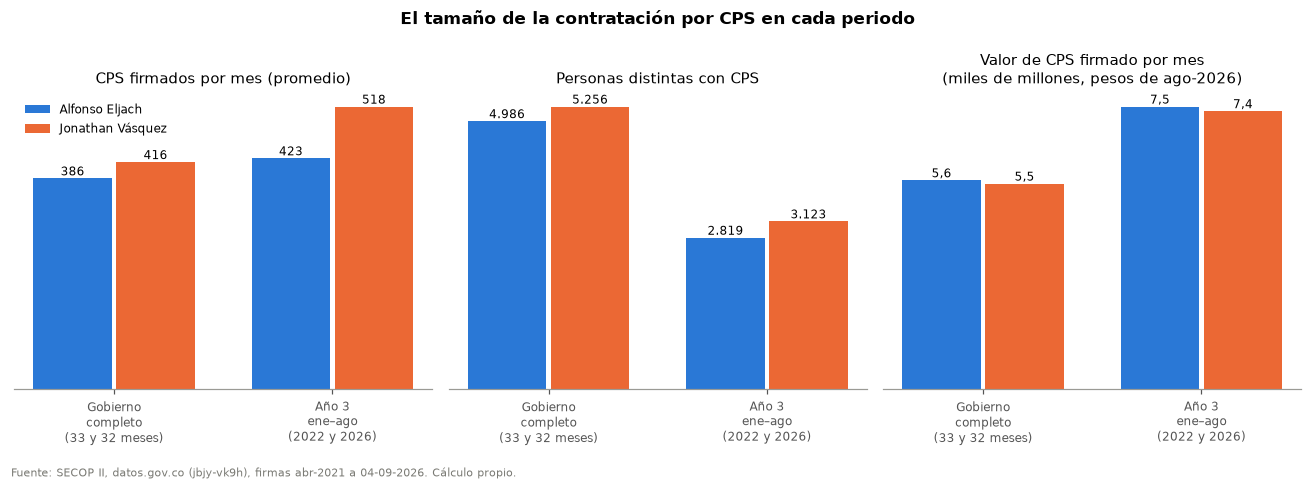

#### P01 · ¿Cuántos contratos firma cada alcalde y cuántos son con personas?

**Nueve de cada diez contratos son CPS con personas.** En los 33 meses observados del gobierno de Alfonso Eljach (abr-2021 a dic-2023) la Alcaldía central firmó 13.669 contratos; 12.755 fueron CPS con 4.986 personas distintas (386 CPS al mes). En los 32 meses de Jonathan Vásquez (ene-2024 al corte) firmó 14.240 contratos; 13.373 CPS con 5.256 personas (416 al mes). Los dos periodos no son la misma etapa del mandato, así que la comparación justa es el año 3 (enero–agosto de 2022 y de 2026): 3.378 CPS con 2.819 personas con Alfonso y 4.133 con 3.123 con Jonathan. La dirección (más CPS y más personas en el periodo de Jonathan) se mantiene con todas las ventanas del cuaderno 04, pero el tamaño del aumento cambia según la ventana: de +10,8 % a +26,5 % en personas y de +22,4 % a +25,4 % en contratos.

**Qué no significa:** Más contratos no significa más empleo ni mejor gestión: un mismo trabajo puede partirse en varios contratos cortos. Los gobiernos están en etapas distintas del mandato; por eso se comparan ventanas equivalentes.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE` · *Límite:* El periodo de Alfonso empieza en abril de 2021 (verificado: SECOP I tiene 734 registros de la Alcaldía de enero a marzo de 2021 y solo 31 de abril en adelante).

,ventana,gobierno,desde,hasta,meses,contratos_total,cps_personas,pct_cps,personas_distintas,cps_por_persona,cps_por_mes,valor_real_cps,valor_real_total,valor_real_cps_por_mes,pct_valor_cps,contratos_sin_ipc
0,Gobierno completo observado,Alfonso Eljach,2021-04-01,2023-12-31,33.018480,13669,12755,93.313337,4986,2.558163,386.298818,1.836866e+11,1.079483e+12,5.563145e+09,17.016168,0
1,Gobierno completo observado,Jonathan Vásquez,2024-01-01,2026-09-04,32.131417,14240,13373,93.911517,5256,2.544330,416.197022,1.758740e+11,9.295678e+11,5.473584e+09,18.919977,46
2,Año 3 del mandato (ene–ago),Alfonso Eljach,2022-01-01,2022-08-31,7.983573,3567,3378,94.701430,2819,1.198297,423.118827,6.006845e+10,2.182621e+11,7.524006e+09,27.521248,0
3,Año 3 del mandato (ene–ago),Jonathan Vásquez,2026-01-01,2026-08-31,7.983573,4352,4133,94.967831,3123,1.323407,517.688014,5.911387e+10,1.883021e+11,7.404438e+09,31.393100,0


In [5]:
filas = []
for _, v in VENTANAS.iterrows():
    tod, c_ = en_ventana(central, v), en_ventana(cps, v)
    filas.append({"ventana": v["ventana"], "gobierno": v["gobierno"], "desde": v["desde"], "hasta": v["hasta"],
                  "meses": v["meses"], "contratos_total": len(tod), "cps_personas": len(c_),
                  "pct_cps": len(c_) / len(tod) * 100, "personas_distintas": c_[PERSONA].nunique(),
                  "cps_por_persona": len(c_) / c_[PERSONA].nunique(), "cps_por_mes": len(c_) / v["meses"],
                  "valor_real_cps": c_["valor_real"].sum(), "valor_real_total": tod["valor_real"].sum(),
                  "valor_real_cps_por_mes": c_["valor_real"].sum() / v["meses"],
                  "pct_valor_cps": c_["valor_real"].sum() / tod["valor_real"].sum() * 100,
                  "contratos_sin_ipc": int(tod["valor_real"].isna().sum())})
t_p1 = pd.DataFrame(filas)
piv = lambda col: t_p1.pivot(index="ventana", columns="gobierno", values=col).loc[ORDEN_VENT]

fig, ax = plt.subplots(1, 3, figsize=(12, 4.2))
etq = [ROT_VENT[v] for v in ORDEN_VENT]
barras_gob(ax[0], etq, piv("cps_por_mes")[A], piv("cps_por_mes")[J], titulo="CPS firmados por mes (promedio)")
barras_gob(ax[1], etq, piv("personas_distintas")[A], piv("personas_distintas")[J], titulo="Personas distintas con CPS")
barras_gob(ax[2], etq, mm(piv("valor_real_cps_por_mes")[A]), mm(piv("valor_real_cps_por_mes")[J]), fmt="{:,.1f}",
           titulo="Valor de CPS firmado por mes\n(miles de millones, pesos de ago-2026)")
for a_ in ax:
    a_.set_yticks([])
    a_.spines["left"].set_visible(False)
ax[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("El tamaño de la contratación por CPS en cada periodo", fontweight="bold", fontsize=11)
g_p1 = guardar_fig(fig, "a1_universo_por_ventana.png")

gc = t_p1.loc[t_p1["ventana"].eq(ORDEN_VENT[0])].set_index("gobierno")
a3 = t_p1.loc[t_p1["ventana"].eq(ORDEN_VENT[1])].set_index("gobierno")
rng = robustez04.set_index("metrica")
rango_personas = rng.loc["personas", ["anio3_ene_ago", "meses_16_32", "meses_17_32"]].astype(float)
rango_cps = rng.loc["contratos", ["anio3_ene_ago", "meses_16_32", "meses_17_32"]].astype(float)
insight("P01", "Acto 1 · El tamaño", "¿Cuántos contratos firma cada alcalde y cuántos son con personas?",
        "Nueve de cada diez contratos son CPS con personas",
        f"En los {gc.loc[A, 'meses']:.0f} meses observados del gobierno de Alfonso Eljach (abr-2021 a dic-2023) la Alcaldía central firmó "
        f"{gc.loc[A, 'contratos_total']:,} contratos; {gc.loc[A, 'cps_personas']:,} fueron CPS con {gc.loc[A, 'personas_distintas']:,} personas "
        f"distintas ({gc.loc[A, 'cps_por_mes']:,.0f} CPS al mes). En los {gc.loc[J, 'meses']:.0f} meses de Jonathan Vásquez (ene-2024 al corte) firmó "
        f"{gc.loc[J, 'contratos_total']:,} contratos; {gc.loc[J, 'cps_personas']:,} CPS con {gc.loc[J, 'personas_distintas']:,} personas "
        f"({gc.loc[J, 'cps_por_mes']:,.0f} al mes). Los dos periodos no son la misma etapa del mandato, así que la comparación "
        f"justa es el año 3 (enero–agosto de 2022 y de 2026): {a3.loc[A, 'cps_personas']:,} CPS con {a3.loc[A, 'personas_distintas']:,} personas "
        f"con Alfonso y {a3.loc[J, 'cps_personas']:,} con {a3.loc[J, 'personas_distintas']:,} con Jonathan. La dirección (más CPS y más personas "
        f"en el periodo de Jonathan) se mantiene con todas las ventanas del cuaderno 04, pero el tamaño del aumento cambia según la ventana: "
        f"de {rango_personas.min():+.1f} % a {rango_personas.max():+.1f} % en personas y de {rango_cps.min():+.1f} % a {rango_cps.max():+.1f} % en contratos.",
        "Más contratos no significa más empleo ni mejor gestión: un mismo trabajo puede partirse en varios contratos cortos. "
        "Los gobiernos están en etapas distintas del mandato; por eso se comparan ventanas equivalentes.",
        "Dato descriptivo", "PUBLICABLE", "Contratos válidos de la Alcaldía central (NIT 890201900); CPS de personas con identidad apta",
        f"El periodo de Alfonso empieza en abril de 2021 ({TXT_2021}).", t_p1, g_p1,
        cifra=f"{gc.loc[A, 'cps_personas']:,} CPS ({A}) y {gc.loc[J, 'cps_personas']:,} ({J})")
t_p1

## P2 ¿Cuánto dinero es y qué parte se va en CPS?

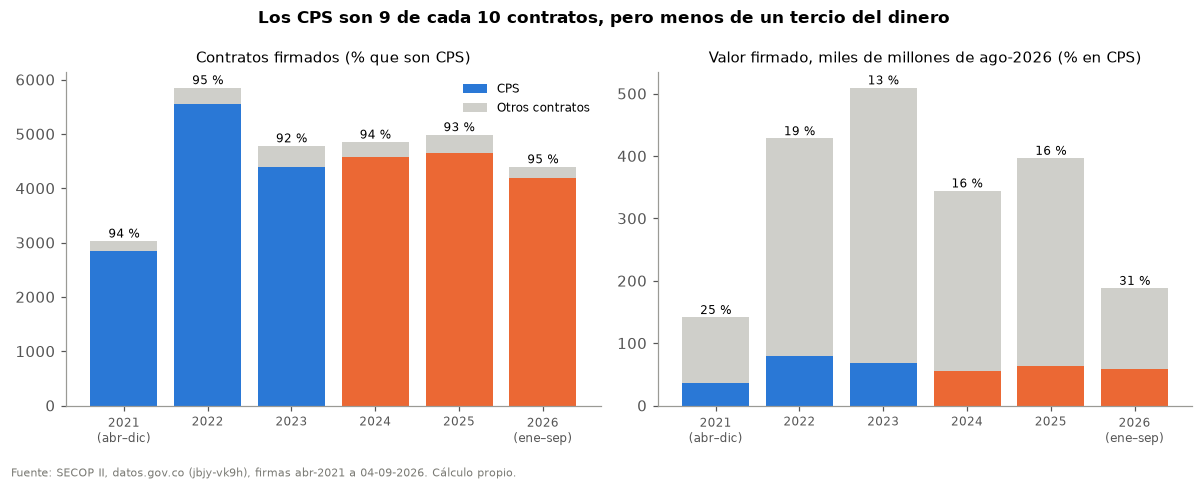

#### P02 · ¿Cuánto dinero es y qué parte se va en CPS?

**Muchos contratos, poca plata.** Cada año entre 92 % y 95 % de los contratos son CPS, pero se llevan entre 13 % y 31 % del valor firmado. En todo el gobierno observado de Alfonso los CPS sumaron 183,7 miles de millones de pesos constantes (5,6 al mes) y en el de Jonathan 175,9 (5,5 al mes). El resto del dinero va a obras, convenios, bienes y servicios de empresas (Acto 6).

**Qué no significa:** Es valor pactado al firmar, no pagado. Un año con mucha obra hace que los CPS pesen menos en porcentaje.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE` · *Límite:* 2021 y el año del corte son parciales; el valor de los meses sin IPC publicado queda fuera de las sumas.

In [6]:
t01 = (central.groupby("anio")
       .agg(contratos=("id_contrato", "size"), cps=("es_cps_estricto", "sum"), valor_real_total=("valor_real", "sum"),
            valor_real_cps=("valor_real", lambda s: s[central.loc[s.index, "es_cps_estricto"]].sum()))
       .reset_index())
t01["pct_contratos_cps"] = t01["cps"] / t01["contratos"] * 100
t01["pct_valor_cps"] = t01["valor_real_cps"] / t01["valor_real_total"] * 100
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(len(t01))
ax[0].bar(x, t01["cps"], color=[color_anio(a) for a in t01["anio"]], label="CPS")
ax[0].bar(x, t01["contratos"] - t01["cps"], bottom=t01["cps"], color="#cfcfca", label="Otros contratos")
ax[1].bar(x, mm(t01["valor_real_cps"]), color=[color_anio(a) for a in t01["anio"]], label="CPS")
ax[1].bar(x, mm(t01["valor_real_total"] - t01["valor_real_cps"]), bottom=mm(t01["valor_real_cps"]), color="#cfcfca", label="Otros")
for i, r in t01.iterrows():
    ax[0].text(i, r["contratos"] + 60, f"{r['pct_contratos_cps']:.0f} %", ha="center", fontsize=8)
    ax[1].text(i, mm(r["valor_real_total"]) + 5, f"{r['pct_valor_cps']:.0f} %", ha="center", fontsize=8)
for a_, t_ in zip(ax, ["Contratos firmados (% que son CPS)", "Valor firmado, miles de millones de ago-2026 (% en CPS)"]):
    a_.set_xticks(x, [rotulo_anio(a) for a in t01["anio"]], fontsize=8)
    a_.set_title(t_, fontsize=10)
ax[0].legend(frameon=False, fontsize=8)
fig.suptitle("Los CPS son 9 de cada 10 contratos, pero menos de un tercio del dinero", fontweight="bold", fontsize=11)
g_p2 = guardar_fig(fig, "a1_cps_vs_total_por_anio.png")
insight("P02", "Acto 1 · El tamaño", "¿Cuánto dinero es y qué parte se va en CPS?",
        "Muchos contratos, poca plata",
        f"Cada año entre {t01['pct_contratos_cps'].min():.0f} % y {t01['pct_contratos_cps'].max():.0f} % de los contratos son CPS, "
        f"pero se llevan entre {t01['pct_valor_cps'].min():.0f} % y {t01['pct_valor_cps'].max():.0f} % del valor firmado. En todo el gobierno "
        f"observado de Alfonso los CPS sumaron {mm(gc.loc[A, 'valor_real_cps']):,.1f} miles de millones de pesos constantes "
        f"({mm(gc.loc[A, 'valor_real_cps_por_mes']):,.1f} al mes) y en el de Jonathan {mm(gc.loc[J, 'valor_real_cps']):,.1f} "
        f"({mm(gc.loc[J, 'valor_real_cps_por_mes']):,.1f} al mes). El resto del dinero va a obras, convenios, bienes y servicios de empresas (Acto 6).",
        "Es valor pactado al firmar, no pagado. Un año con mucha obra hace que los CPS pesen menos en porcentaje.",
        "Dato descriptivo", "PUBLICABLE", "Contratos válidos de la Alcaldía central",
        "2021 y el año del corte son parciales; el valor de los meses sin IPC publicado queda fuera de las sumas.", t01, g_p2,
        cifra=f"{t01['pct_contratos_cps'].median():.0f} % de los contratos y {t01['pct_valor_cps'].median():.0f} % del valor (mediana anual)")

# 2  La vida de un contratista
## P3 ¿Cuánto dura un contrato? ¿Cuántos pasan de 6 o 7 meses?

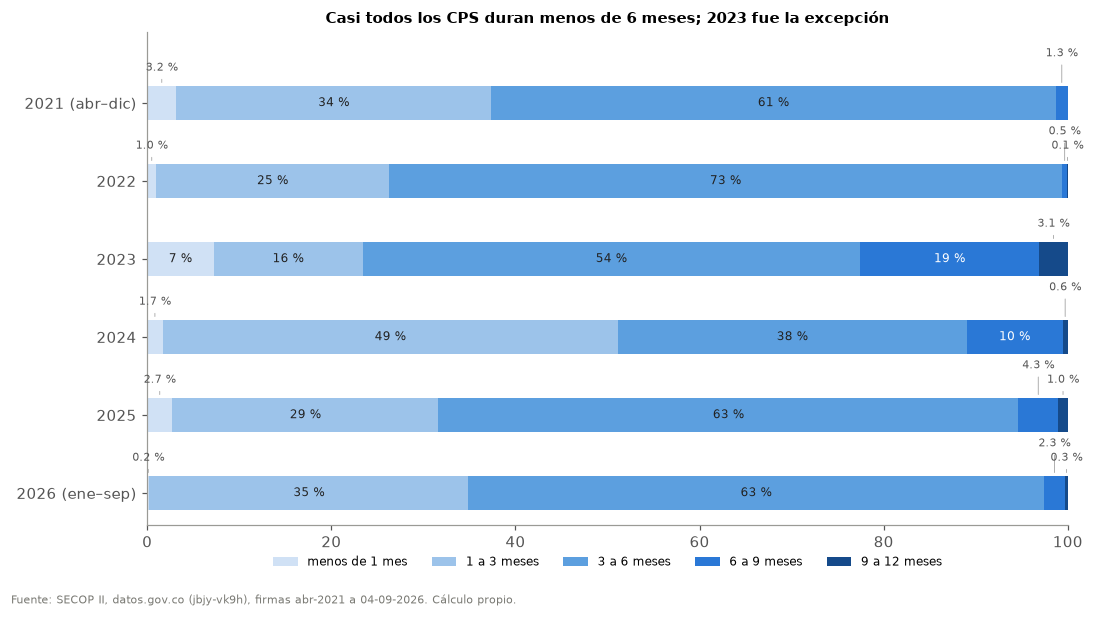

#### P03 · ¿Cuánto dura un contrato? ¿Cuántos pasan de 6 o 7 meses?

**Contratos cortos.** Un CPS dura en promedio 3,7 meses con Alfonso y 3,5 con Jonathan (mediana 3,9 y 3,0). Los contratos de 6 meses o más son la excepción: 1.052 (8,3 %) con Alfonso y 499 (3,8 %) con Jonathan; de 7 meses o más, 419 y 169. De los de 7 meses o más de Alfonso, 385 se firmaron en 2023 (el 9 % de los CPS de ese año, el último del gobierno): esa tanda explica casi toda la diferencia. En la ventana comparable (enero–agosto del año 3) los de 7 meses o más fueron 0,4 % y 0,3 %, y los de 6 meses o más 1,0 % y 2,5 %: no hay una diferencia de fondo entre gobiernos. En los años completos solo entre el 0,1 % y el 0,2 % de los CPS termina después del 31 de diciembre del año en que se firmó.

**Qué no significa:** Un contrato corto no implica un servicio mal prestado. El dato no dice por qué se pactan así (presupuesto anual, planeación u otras razones).

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE` · *Límite:* Vigencia pactada registrada (ya incluye prórrogas), no días trabajados.

,ventana,gobierno,cps,mediana_meses,promedio_meses,cps_6_meses_o_mas,pct_6_meses_o_mas,cps_7_meses_o_mas,pct_7_meses_o_mas,cps_menos_de_3_meses,pct_menos_de_3_meses
0,Gobierno completo observado,Alfonso Eljach,12683,3.9,3.7,1052,8.3,419,3.3,4638,36.6
1,Gobierno completo observado,Jonathan Vásquez,13285,3.0,3.5,499,3.8,169,1.3,6139,46.2
2,Año 3 del mandato (ene–ago),Alfonso Eljach,3346,4.1,4.3,33,1.0,12,0.4,560,16.7
3,Año 3 del mandato (ene–ago),Jonathan Vásquez,4078,3.9,4.0,101,2.5,13,0.3,1443,35.4


In [37]:
filas = []
for _, v in VENTANAS.iterrows():
    c_ = en_ventana(cpsi, v)
    filas.append({"ventana": v["ventana"], "gobierno": v["gobierno"], "cps": len(c_),
                  "mediana_meses": c_["meses"].median(), "promedio_meses": c_["meses"].mean(),
                  "cps_6_meses_o_mas": int(c_["meses"].ge(6).sum()), "pct_6_meses_o_mas": c_["meses"].ge(6).mean() * 100,
                  "cps_7_meses_o_mas": int(c_["meses"].ge(7).sum()), "pct_7_meses_o_mas": c_["meses"].ge(7).mean() * 100,
                  "cps_menos_de_3_meses": int(c_["meses"].lt(3).sum()), "pct_menos_de_3_meses": c_["meses"].lt(3).mean() * 100})
t_p3 = pd.DataFrame(filas)
bandas = pd.cut(cpsi["duracion_dias_incl"], [0, 30, 91, 182, 274, 367], right=False,  # mismos cortes que el 06
                labels=["menos de 1 mes", "1 a 3 meses", "3 a 6 meses", "6 a 9 meses", "9 a 12 meses"])
t_p3b = pd.crosstab(cpsi["anio"], bandas, normalize="index").mul(100)
t_p3b["mediana_meses"] = cpsi.groupby("anio")["meses"].median()
t_p3b["pct_7_meses_o_mas"] = cpsi.groupby("anio")["meses"].apply(lambda s: s.ge(7).mean() * 100)
t_p3b["pct_cruza_al_anio_siguiente"] = cpsi.assign(x=cpsi["fecha_fin"].dt.year.gt(cpsi["anio"])).groupby("anio")["x"].mean() * 100
t_p3b = t_p3b.reset_index()

fig, ax = plt.subplots(figsize=(10, 5.4))
n = len(t_p3b)
paso, alto = 1.9, 0.85
y_pos = np.arange(n) * paso
izq = np.zeros(n)
tonos = ["#d0e1f5", "#9cc3ea", "#5c9fdf", "#2a78d6", "#154a8a"]
n_etq_fuera = np.zeros(n, dtype=int)  # cuenta etiquetas fuera de la barra por año, para alternar su altura y que no se encimen
for col, ton in zip(bandas.cat.categories, tonos):
    vals = t_p3b[col].to_numpy()
    ax.barh(y_pos, vals, left=izq, height=alto, color=ton, label=col)
    for i, (l, w) in enumerate(zip(izq, vals)):
        if w <= 0:
            continue
        centro = l + w / 2
        if w >= 6:
            ax.text(centro, y_pos[i], f"{w:.0f} %", ha="center", va="center", fontsize=8, color="white" if ton in tonos[3:] else "#222222")
        else:
            nivel = n_etq_fuera[i] % 2
            y_txt = y_pos[i] - alto / 2 - (0.3 if nivel == 0 else 0.65)
            ax.annotate(f"{w:.1f} %", xy=(centro, y_pos[i] - alto / 2), xytext=(centro, y_txt), ha="center", va="bottom",
                        fontsize=7, color="#555555", arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.6))
            n_etq_fuera[i] += 1
    izq += vals
ax.set_yticks(y_pos)
ax.set_yticklabels([rotulo_anio(a).replace("\n", " ") for a in t_p3b["anio"]])
ax.set_ylim(y_pos[-1] + alto / 2 + 0.35, y_pos[0] - alto / 2 - 1.3)
ax.set_xlim(0, 100)
ax.margins(x=0)
ax.legend(ncol=5, frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.04))
ax.set_title(f"Casi todos los CPS duran menos de 6 meses; {int(t_p3b.set_index('anio')['pct_7_meses_o_mas'].idxmax())} fue la excepción", fontsize=10, fontweight="bold")
g_p3 = guardar_fig(fig, "a2_duracion_por_anio.png")

gp3 = t_p3.loc[t_p3["ventana"].eq(ORDEN_VENT[0])].set_index("gobierno")
a3p3 = t_p3.loc[t_p3["ventana"].eq(ORDEN_VENT[1])].set_index("gobierno")
largos_2023 = int((cpsi["anio"].eq(2023) & cpsi["meses"].ge(7)).sum())
d3 = t_p3b.set_index("anio")
insight("P03", "Acto 2 · La vida de un contratista", "¿Cuánto dura un contrato? ¿Cuántos pasan de 6 o 7 meses?",
        "Contratos cortos",
        f"Un CPS dura en promedio {gp3.loc[A, 'promedio_meses']:.1f} meses con Alfonso y {gp3.loc[J, 'promedio_meses']:.1f} con Jonathan "
        f"(mediana {gp3.loc[A, 'mediana_meses']:.1f} y {gp3.loc[J, 'mediana_meses']:.1f}). Los contratos de 6 meses o más son la excepción: "
        f"{gp3.loc[A, 'cps_6_meses_o_mas']:,} ({gp3.loc[A, 'pct_6_meses_o_mas']:.1f} %) con Alfonso y {gp3.loc[J, 'cps_6_meses_o_mas']:,} "
        f"({gp3.loc[J, 'pct_6_meses_o_mas']:.1f} %) con Jonathan; de 7 meses o más, {gp3.loc[A, 'cps_7_meses_o_mas']:,} y "
        f"{gp3.loc[J, 'cps_7_meses_o_mas']:,}. De los de 7 meses o más de Alfonso, {largos_2023:,} se firmaron en 2023 (el "
        f"{d3.loc[2023, 'pct_7_meses_o_mas']:.0f} % de los CPS de ese año, el último del gobierno): esa tanda explica casi toda la diferencia. "
        f"En la ventana comparable (enero–agosto del año 3) los de 7 meses o más fueron {a3p3.loc[A, 'pct_7_meses_o_mas']:.1f} % y "
        f"{a3p3.loc[J, 'pct_7_meses_o_mas']:.1f} %, y los de 6 meses o más {a3p3.loc[A, 'pct_6_meses_o_mas']:.1f} % y {a3p3.loc[J, 'pct_6_meses_o_mas']:.1f} %: "
        f"no hay una diferencia de fondo entre gobiernos. En los años completos solo entre el "
        f"{d3.loc[ANIOS_COMPLETOS, 'pct_cruza_al_anio_siguiente'].min():.1f} % y el {d3.loc[ANIOS_COMPLETOS, 'pct_cruza_al_anio_siguiente'].max():.1f} % "
        f"de los CPS termina después del 31 de diciembre del año en que se firmó.",
        "Un contrato corto no implica un servicio mal prestado. El dato no dice por qué se pactan así (presupuesto anual, planeación u otras razones).",
        "Dato descriptivo", "PUBLICABLE", "CPS de personas, Alcaldía central, vigencia 1–366 días",
        "Vigencia pactada registrada (ya incluye prórrogas), no días trabajados.", pd.concat([t_p3, t_p3b], ignore_index=True), g_p3,
        cifra=f"duración mediana de {d3['mediana_meses'].min():.1f} a {d3['mediana_meses'].max():.1f} meses según el año; menos de 1 de cada 10 pasa de 6 meses")
t_p3.round(1)

## P4 ¿Quiénes son "los más estables"?
Una persona puede encadenar varios contratos cortos. Aquí se suman los días con contrato de cada persona en cada año calendario
(sin contar dos veces los días en que tuvo dos contratos a la vez).

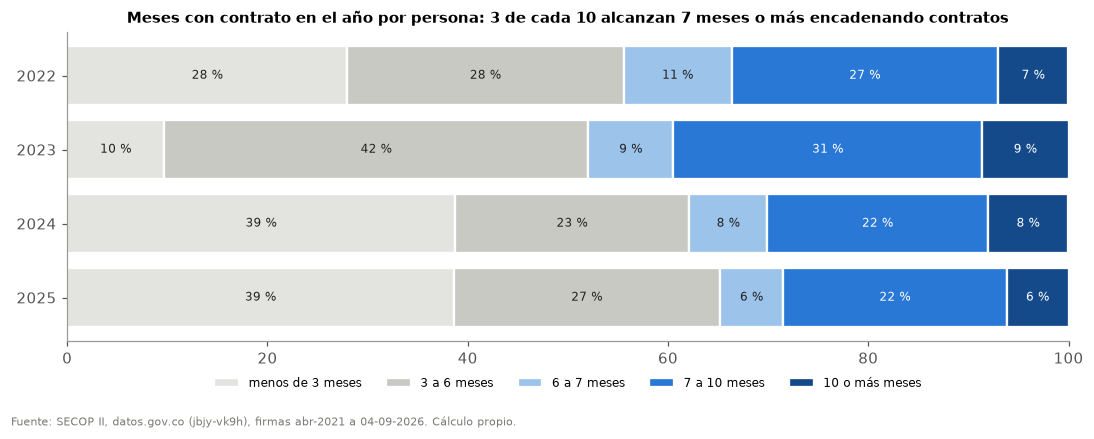

#### P04 · ¿Cuántas personas son "las más estables" (7 meses o más con contrato en el año)?

**Contratos cortos, personas que encadenan.** Aunque pocos contratos pasan de 7 meses, muchas personas suman 7 meses o más con contrato en el año encadenando varios: 2022: 1.186 personas (34 %); 2023: 1.198 personas (39 %); 2024: 801 personas (30 %); 2025: 921 personas (28 %). Con 10 meses o más, casi todo el año, solo entre 6 % y 9 %. La persona típica tuvo contrato entre 4,0 y 5,7 meses del año y firmó en promedio 1,4 a 1,7 contratos. 2022 y 2023 son los años 3 y 4 de Alfonso; 2024 y 2025, los años 1 y 2 de Jonathan.

**Qué no significa:** No mide ingresos anuales ni empleo: fuera de la Alcaldía la persona puede tener otros trabajos.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Etapas distintas del mandato; fechas pactadas, no días trabajados.

,anio,gobierno,personas,mediana_meses_con_contrato,promedio_meses_con_contrato,personas_6_meses_o_mas,pct_6_meses_o_mas,personas_7_meses_o_mas,pct_7_meses_o_mas,personas_10_meses_o_mas,pct_10_meses_o_mas,contratos_por_persona,pct_personas_3_contratos_o_mas
0,2022,Alfonso Eljach,3526,5.3,5.6,1567,44.4,1186,33.6,249,7.1,1.6,3.3
1,2023,Alfonso Eljach,3035,5.7,6.1,1456,48.0,1198,39.5,262,8.6,1.4,7.3
2,2024,Jonathan Vásquez,2663,4.0,5.1,1009,37.9,801,30.1,215,8.1,1.7,15.5
3,2025,Jonathan Vásquez,3233,4.0,5.0,1126,34.8,921,28.5,200,6.2,1.4,3.1


In [8]:
filas, bandas_pa = [], []
for y in ANIOS_COMPLETOS:
    cp = su.cobertura_por_persona(cpsi, f"{y}-01-01", f"{y + 1}-01-01")
    m = cp["meses_cubiertos"]
    filas.append({"anio": y, "gobierno": A if y < CAMBIO.year else J, "personas": len(cp),
                  "mediana_meses_con_contrato": m.median(), "promedio_meses_con_contrato": m.mean(),
                  "personas_6_meses_o_mas": int(m.ge(6).sum()), "pct_6_meses_o_mas": m.ge(6).mean() * 100,
                  "personas_7_meses_o_mas": int(m.ge(7).sum()), "pct_7_meses_o_mas": m.ge(7).mean() * 100,
                  "personas_10_meses_o_mas": int(m.ge(10).sum()), "pct_10_meses_o_mas": m.ge(10).mean() * 100,
                  "contratos_por_persona": cp["contratos"].mean(),
                  "pct_personas_3_contratos_o_mas": cp["contratos"].ge(3).mean() * 100})
    bandas_pa.append(pd.cut(m, [0, 3, 6, 7, 10, 13], right=False,
                            labels=["menos de 3", "3 a 6", "6 a 7", "7 a 10", "10 o más"]).value_counts(normalize=True, sort=False).mul(100).rename(y))
t_p4 = pd.DataFrame(filas)
t_p4b = pd.DataFrame(bandas_pa)

fig, ax = plt.subplots(figsize=(10, 3.8))
izq = np.zeros(len(t_p4b))
tonos = ["#e3e3df", "#c9c9c4", "#9cc3ea", "#2a78d6", "#154a8a"]
for col, ton in zip(t_p4b.columns, tonos):
    ax.barh([str(a) for a in t_p4b.index], t_p4b[col], left=izq, color=ton, label=f"{col} meses", edgecolor="white", linewidth=1.5)
    for i, (l, w) in enumerate(zip(izq, t_p4b[col])):
        if w >= 5:
            ax.text(l + w / 2, i, f"{w:.0f} %", ha="center", va="center", fontsize=8, color="white" if ton in tonos[3:] else "#222222")
    izq += t_p4b[col].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.legend(ncol=5, frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.set_title("Meses con contrato en el año por persona: 3 de cada 10 alcanzan 7 meses o más encadenando contratos",
             fontsize=10, fontweight="bold")
g_p4 = guardar_fig(fig, "a2_meses_con_contrato_por_persona.png")

p4 = t_p4.set_index("anio")
insight("P04", "Acto 2 · La vida de un contratista", "¿Cuántas personas son \"las más estables\" (7 meses o más con contrato en el año)?",
        "Contratos cortos, personas que encadenan",
        f"Aunque pocos contratos pasan de 7 meses, muchas personas suman 7 meses o más con contrato en el año encadenando varios: "
        + "; ".join(f"{a}: {r['personas_7_meses_o_mas']:,} personas ({r['pct_7_meses_o_mas']:.0f} %)" for a, r in p4.iterrows())
        + f". Con 10 meses o más, casi todo el año, solo entre {p4['pct_10_meses_o_mas'].min():.0f} % y {p4['pct_10_meses_o_mas'].max():.0f} %. "
        f"La persona típica tuvo contrato entre {p4['mediana_meses_con_contrato'].min():.1f} y {p4['mediana_meses_con_contrato'].max():.1f} meses "
        f"del año y firmó en promedio {p4['contratos_por_persona'].min():.1f} a {p4['contratos_por_persona'].max():.1f} contratos. "
        f"2022 y 2023 son los años 3 y 4 de Alfonso; 2024 y 2025, los años 1 y 2 de Jonathan.",
        "No mide ingresos anuales ni empleo: fuera de la Alcaldía la persona puede tener otros trabajos.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "CPS de personas, Alcaldía central, años calendario completos",
        "Etapas distintas del mandato; fechas pactadas, no días trabajados.", t_p4.merge(t_p4b.reset_index(names="anio"), on="anio"),
        g_p4, cifra=f"{p4['pct_7_meses_o_mas'].min():.0f}–{p4['pct_7_meses_o_mas'].max():.0f} % de las personas con 7 meses o más al año")
t_p4.round(1)

## P5  ¿Cuáles son los contratos más largos que dio cada alcalde?


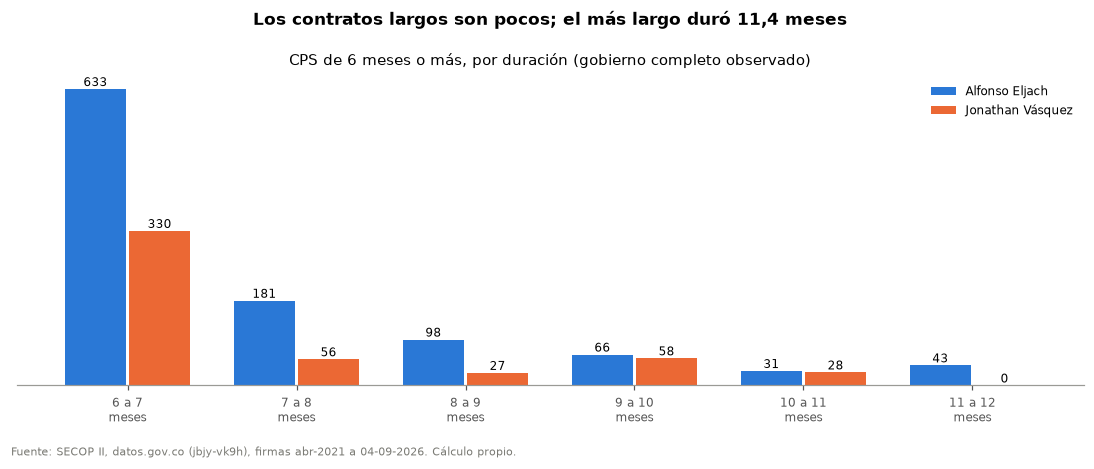

#### P05 · ¿Cuáles son los contratos más largos que dio cada alcalde?

**Ningún CPS válido llega a un año.** El CPS más largo del gobierno de Alfonso duró 11,4 meses y el de Jonathan 10,6. Con Alfonso hubo 140 CPS de 9 meses o más (74 de 10 o más); con Jonathan, 86 (28). En el año 3 (enero–agosto) fueron 4 y 12. De los CPS de 9 meses o más, tuvieron prórroga el 24 % con Alfonso y el 48 % con Jonathan. Además, 1 CPS con más de 366 días de vigencia registrada se deja fuera de estos cálculos por ser probable error de registro (sigue en la base).

**Qué no significa:** Un contrato largo no es un privilegio ni un empleo: sigue siendo un CPS. La lista con nombres queda para verificación interna.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE` · *Límite:* Se publican conteos por banda de duración; la lista de contratos queda para verificación interna.

,ventana,gobierno,maximo_meses,cps_9_meses_o_mas,cps_10_meses_o_mas,cps_11_meses_o_mas,pct_9_o_mas_con_prorroga,pct_9_o_mas_firmados_en_enero,cps_vigencia_mayor_366_dias_excluidos
0,Gobierno completo observado,Alfonso Eljach,11.4,140,74,43,23.6,50.7,0
1,Gobierno completo observado,Jonathan Vásquez,10.6,86,28,0,47.7,52.3,1
2,Año 3 del mandato (ene–ago),Alfonso Eljach,10.4,4,4,0,0.0,75.0,0
3,Año 3 del mandato (ene–ago),Jonathan Vásquez,10.6,12,10,0,100.0,100.0,1


In [9]:
filas = []
for _, v in VENTANAS.iterrows():
    c_, todos_c = en_ventana(cpsi, v), en_ventana(cps, v)
    j9 = c_.loc[c_["meses"].ge(9)]
    filas.append({"ventana": v["ventana"], "gobierno": v["gobierno"], "maximo_meses": c_["meses"].max(),
                  "cps_9_meses_o_mas": len(j9), "cps_10_meses_o_mas": int(c_["meses"].ge(10).sum()),
                  "cps_11_meses_o_mas": int(c_["meses"].ge(11).sum()),
                  "pct_9_o_mas_con_prorroga": j9["flag_dias_adicionados"].mean() * 100 if len(j9) else np.nan,
                  "pct_9_o_mas_firmados_en_enero": j9["fecha_firma"].dt.month.eq(1).mean() * 100 if len(j9) else np.nan,
                  "cps_vigencia_mayor_366_dias_excluidos": int((~todos_c["apto_intervalo"] & todos_c["duracion_dias_incl"].gt(366)).sum())})
t_p5 = pd.DataFrame(filas)
for _c in ["cps_9_meses_o_mas", "cps_10_meses_o_mas", "cps_11_meses_o_mas", "cps_vigencia_mayor_366_dias_excluidos"]:
    t_p5[_c] = t_p5[_c].astype(int)
largos = (cpsi.sort_values(["meses", "fecha_firma", "id_contrato"], ascending=[False, True, True])
          .groupby("gobierno").head(15).copy())
largos["mes_firma"] = largos["fecha_firma"].dt.strftime("%Y-%m")
largos["meses_redondeados"] = largos["meses"].round(1)
# Tabla pública: solo conteos por banda de duración (una fila por contrato podría ubicarse en SECOP)
BANDAS_LARGAS = [6, 7, 8, 9, 10, 11, 12.1]
ETQ_LARGAS = ["6 a 7", "7 a 8", "8 a 9", "9 a 10", "10 a 11", "11 a 12"]
t_p5b = (pd.crosstab(pd.cut(cpsi["meses"], BANDAS_LARGAS, right=False, labels=ETQ_LARGAS), cpsi["gobierno"])
         .reindex(ETQ_LARGAS).fillna(0).astype(int).rename_axis("meses").reset_index())
su.guardar_csv(largos[["gobierno", "id_contrato", "fecha_firma", "fecha_inicio", "fecha_fin", "meses", "nombre_proveedor",
                       "valor_contrato", "url_secop"]], INTERNO / "contratos_mas_largos.csv")

fig, ax = plt.subplots(figsize=(10, 4))
barras_gob(ax, [f"{e}\nmeses" for e in ETQ_LARGAS], t_p5b[A].to_numpy(), t_p5b[J].to_numpy(),
           titulo="CPS de 6 meses o más, por duración (gobierno completo observado)")
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.legend(frameon=False, fontsize=8)
p5 = t_p5.set_index(["ventana", "gobierno"])
n366 = int(t_p5.loc[t_p5["ventana"].eq(ORDEN_VENT[0]), "cps_vigencia_mayor_366_dias_excluidos"].sum())
gA, gJ = p5.loc[(ORDEN_VENT[0], A)], p5.loc[(ORDEN_VENT[0], J)]
fig.suptitle(es(f"Los contratos largos son pocos; el más largo duró {max(gA['maximo_meses'], gJ['maximo_meses']):.1f} meses"),
             fontweight="bold", fontsize=11)
g_p5 = guardar_fig(fig, "a2_contratos_mas_largos.png")
insight("P05", "Acto 2 · La vida de un contratista", "¿Cuáles son los contratos más largos que dio cada alcalde?",
        "Ningún CPS válido llega a un año",
        f"El CPS más largo del gobierno de Alfonso duró {gA['maximo_meses']:.1f} meses y el de Jonathan {gJ['maximo_meses']:.1f}. Con Alfonso hubo "
        f"{int(gA['cps_9_meses_o_mas']):,} CPS de 9 meses o más ({int(gA['cps_10_meses_o_mas']):,} de 10 o más); con Jonathan, {int(gJ['cps_9_meses_o_mas']):,} "
        f"({int(gJ['cps_10_meses_o_mas']):,}). En el año 3 (enero–agosto) fueron {int(p5.loc[(ORDEN_VENT[1], A), 'cps_9_meses_o_mas'])} y "
        f"{int(p5.loc[(ORDEN_VENT[1], J), 'cps_9_meses_o_mas'])}. De los CPS de 9 meses o más, tuvieron prórroga el "
        f"{gA['pct_9_o_mas_con_prorroga']:.0f} % con Alfonso y el {gJ['pct_9_o_mas_con_prorroga']:.0f} % con Jonathan. Además, "
        f"{n366} {'CPS' if n366 != 1 else 'CPS'} con más de 366 días de vigencia registrada "
        f"{'se dejan' if n366 != 1 else 'se deja'} fuera de estos cálculos por ser probable error de registro (sigue en la base).",
        "Un contrato largo no es un privilegio ni un empleo: sigue siendo un CPS. La lista con nombres queda para verificación interna.",
        "Dato descriptivo", "PUBLICABLE", "CPS de personas, Alcaldía central, vigencia 1–366 días",
        "Se publican conteos por banda de duración; la lista de contratos queda para verificación interna.",
        pd.concat([t_p5, t_p5b], ignore_index=True), g_p5,
        cifra=f"máximo {gA['maximo_meses']:.1f} ({A}) y {gJ['maximo_meses']:.1f} meses ({J})")
t_p5.round(1)

## P6 Cuando se acaba un contrato, ¿cuánto tarda la renovación?
Cada final de episodio se sigue **365 días**: solo entran episodios que terminaron al menos un año antes del corte, para que ningún
periodo tenga más tiempo de "esperar" (sesgo de censura). Los finales entre noviembre de 2023 y enero de 2024 (cambio de gobierno)
van aparte. Los resultados se muestran **por año de terminación**: el año del calendario electoral pesa más que el gobierno.

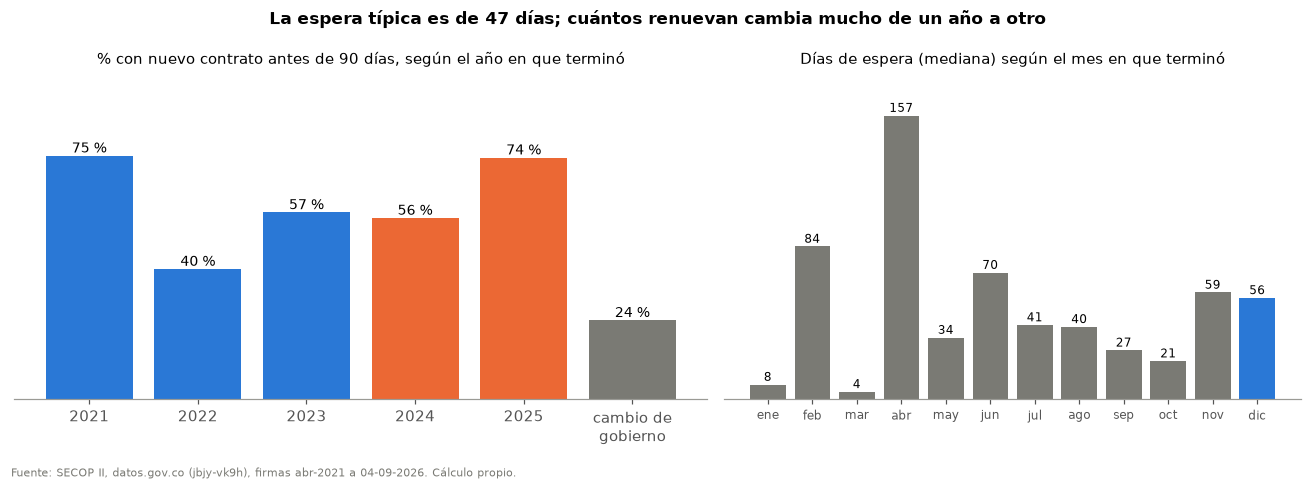

#### P06 · Cuando se acaba un contrato, ¿cuánto tarda la renovación?

**Mes y medio de espera típica.** Entre quienes vuelven a tener un CPS con la Alcaldía en menos de un año, la espera promedio es de 72 días (2,4 meses) y la mediana de 47 días: la mitad espera menos de mes y medio. Pero cuántos renuevan depende mucho del año: antes de 90 días volvió a tener contrato entre el 40 % (finales de 2022) y el 75 % (finales de 2021). Esa variación entre años es mayor que la diferencia entre gobiernos, por eso no se compara a los alcaldes con este indicador. En el cambio de gobierno solo el 39 % volvió dentro del año. Quien termina en diciembre espera una mediana de 56 días: el vacío de enero.

**Qué no significa:** Esperar no significa estar desempleado: la persona puede trabajar en otra parte. No renovar no es despido.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Seguimiento igual de 365 días; solo ve la Alcaldía central. El Q04 del 06 mide pausas dentro de una ventana (otra definición) y da cifras distintas.

,grupo,finales_de_contrato,pct_renueva_15_dias,pct_renueva_30_dias,pct_renueva_60_dias,pct_renueva_90_dias,pct_renueva_180_dias,pct_renueva_365_dias,promedio_dias_espera,promedio_meses_espera,mediana_dias_espera,p75_dias_espera
0,Todos (sin el cambio de gobierno),15579,9.4,23.6,44.8,55.2,67.5,74.9,72.1,2.4,47.0,95.0
1,2021,2781,6.7,30.6,68.8,74.6,78.5,82.1,50.2,1.6,36.0,50.0
2,2022,5426,2.7,10.0,25.7,39.8,58.9,69.6,95.4,3.1,79.0,129.0
3,2023,1620,15.8,40.9,55.7,57.2,60.6,63.8,42.8,1.4,25.0,38.0
4,2024,4405,13.4,24.8,43.6,55.5,68.6,77.6,78.1,2.6,51.0,105.0
5,2025,1347,21.2,39.2,62.2,74.0,84.2,85.7,47.2,1.5,34.0,64.0
7,Cambio de gobierno (nov-23 a ene-24),2610,6.4,12.4,20.1,24.1,31.2,39.3,105.6,3.5,56.0,160.0


In [38]:
SEG = 365
TRANSICION = ("2023-11-01", "2024-01-31")
obs = episodios.loc[episodios["fin_excl"].le(CORTE - pd.Timedelta(days=SEG))].copy()
obs["en_transicion"] = obs["fin_excl"].between(*TRANSICION)
obs["anio_fin"] = (obs["fin_excl"] - pd.Timedelta(days=1)).dt.year
obs["periodo"] = np.where(obs["en_transicion"], "Cambio de gobierno (nov-23 a ene-24)", obs["gobierno_fin"])
obs["renovo_365"] = obs["dias_sin_contrato"].le(SEG)
PLAZOS = [15, 30, 60, 90, 180, 365]


def resumen_renovacion(d, etiqueta):
    r_ = d.loc[d["renovo_365"], "dias_sin_contrato"]
    fila = {"grupo": etiqueta, "finales_de_contrato": len(d)}
    fila.update({f"pct_renueva_{p}_dias": d["dias_sin_contrato"].le(p).mean() * 100 for p in PLAZOS})
    fila.update({"promedio_dias_espera": r_.mean(), "promedio_meses_espera": r_.mean() / MES_DIAS,
                 "mediana_dias_espera": r_.median(), "p75_dias_espera": r_.quantile(0.75)})
    return fila


fuera_tr = obs.loc[~obs["en_transicion"]]
t_p6 = pd.DataFrame([resumen_renovacion(fuera_tr, "Todos (sin el cambio de gobierno)")]
                    + [resumen_renovacion(d, str(a)) for a, d in fuera_tr.groupby("anio_fin")]
                    + [resumen_renovacion(d, p) for p, d in obs.groupby("periodo")])
obs["mes_fin"] = (obs["fin_excl"] - pd.Timedelta(days=1)).dt.month
t_p6b = fuera_tr.assign(mes_fin=obs["mes_fin"]).loc[lambda d: d["renovo_365"]].groupby("mes_fin")["dias_sin_contrato"].agg(
    ["count", "mean", "median"]).reset_index()
t_p6b["mes"] = t_p6b["mes_fin"].map(lambda m: MESES_LARGOS[m - 1])
p6 = t_p6.set_index("grupo")
anios_fin = [g for g in p6.index if g.isdigit()]
tot6 = p6.loc["Todos (sin el cambio de gobierno)"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.2, 1]})
vals = [p6.loc[a, "pct_renueva_90_dias"] for a in anios_fin] + [p6.loc["Cambio de gobierno (nov-23 a ene-24)", "pct_renueva_90_dias"]]
cols = [color_anio(int(a)) for a in anios_fin] + [GRIS]
ax[0].bar(anios_fin + ["cambio de\ngobierno"], vals, color=cols)
for k, v in enumerate(vals):
    ax[0].text(k, v + 1, f"{v:.0f} %", ha="center", fontsize=9)
ax[0].set_ylim(0, 100)
ax[0].set_yticks([])
ax[0].spines["left"].set_visible(False)
ax[0].set_title("% con nuevo contrato antes de 90 días, según el año en que terminó", fontsize=10)
ax[1].bar(t_p6b["mes_fin"], t_p6b["median"], color=GRIS)
ax[1].bar(12, float(t_p6b.loc[t_p6b["mes_fin"].eq(12), "median"].iloc[0]), color=AZUL)
for m, v in zip(t_p6b["mes_fin"], t_p6b["median"]):
    ax[1].text(m, v + 2, f"{v:.0f}", ha="center", fontsize=8)
ax[1].set_ylim(0, t_p6b["median"].max() * 1.15)
ax[1].set_xticks(range(1, 13), MESES_ES, fontsize=8)
ax[1].set_yticks([])
ax[1].spines["left"].set_visible(False)
ax[1].set_title("Días de espera (mediana) según el mes en que terminó", fontsize=10)
fig.suptitle(es(f"La espera típica es de {tot6['mediana_dias_espera']:.0f} días; cuántos renuevan cambia mucho de un año a otro"),
             fontweight="bold", fontsize=11)
g_p6 = guardar_fig(fig, "a2_tiempo_de_renovacion.png")

r90 = p6.loc[anios_fin, "pct_renueva_90_dias"]
insight("P06", "Acto 2 · La vida de un contratista", "Cuando se acaba un contrato, ¿cuánto tarda la renovación?",
        "Mes y medio de espera típica",
        f"Entre quienes vuelven a tener un CPS con la Alcaldía en menos de un año, la espera promedio es de {tot6['promedio_dias_espera']:.0f} días "
        f"({tot6['promedio_meses_espera']:.1f} meses) y la mediana de {tot6['mediana_dias_espera']:.0f} días: la mitad espera menos de mes y medio. "
        f"Pero cuántos renuevan depende mucho del año: antes de 90 días volvió a tener contrato entre el {r90.min():.0f} % (finales de "
        f"{r90.idxmin()}) y el {r90.max():.0f} % (finales de {r90.idxmax()}). Esa variación entre años es mayor que la diferencia entre "
        f"gobiernos, por eso no se compara a los alcaldes con este indicador. En el cambio de gobierno solo el "
        f"{p6.loc['Cambio de gobierno (nov-23 a ene-24)', 'pct_renueva_365_dias']:.0f} % volvió dentro del año. Quien termina en diciembre espera "
        f"una mediana de {t_p6b.loc[t_p6b['mes_fin'].eq(12), 'median'].iloc[0]:.0f} días: el vacío de enero.",
        "Esperar no significa estar desempleado: la persona puede trabajar en otra parte. No renovar no es despido.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "Episodios de CPS de la Alcaldía central terminados al menos 365 días antes del corte",
        f"Seguimiento igual de {SEG} días; solo ve la Alcaldía central. El Q04 del 06 mide pausas dentro de una ventana (otra definición) y da "
        "cifras distintas.",
        pd.concat([t_p6.loc[~t_p6["grupo"].isin([A, J])],  # sin filas por gobierno: esa comparación no se publica
                   t_p6b.rename(columns={"count": "renovaciones", "mean": "promedio_dias", "median": "mediana_dias"})], ignore_index=True),
        g_p6, cifra=f"espera mediana {tot6['mediana_dias_espera']:.0f} días; promedio {tot6['promedio_meses_espera']:.1f} meses")
t_p6.loc[~t_p6["grupo"].isin([A, J])].round(1)

## P7 ¿Cuántas personas tienen contrato vigente cada día?
Se cuenta, día por día, cuántas personas distintas tenían al menos un CPS vigente y cuánto valor diario comprometían esos contratos
(valor del contrato ÷ días de vigencia).

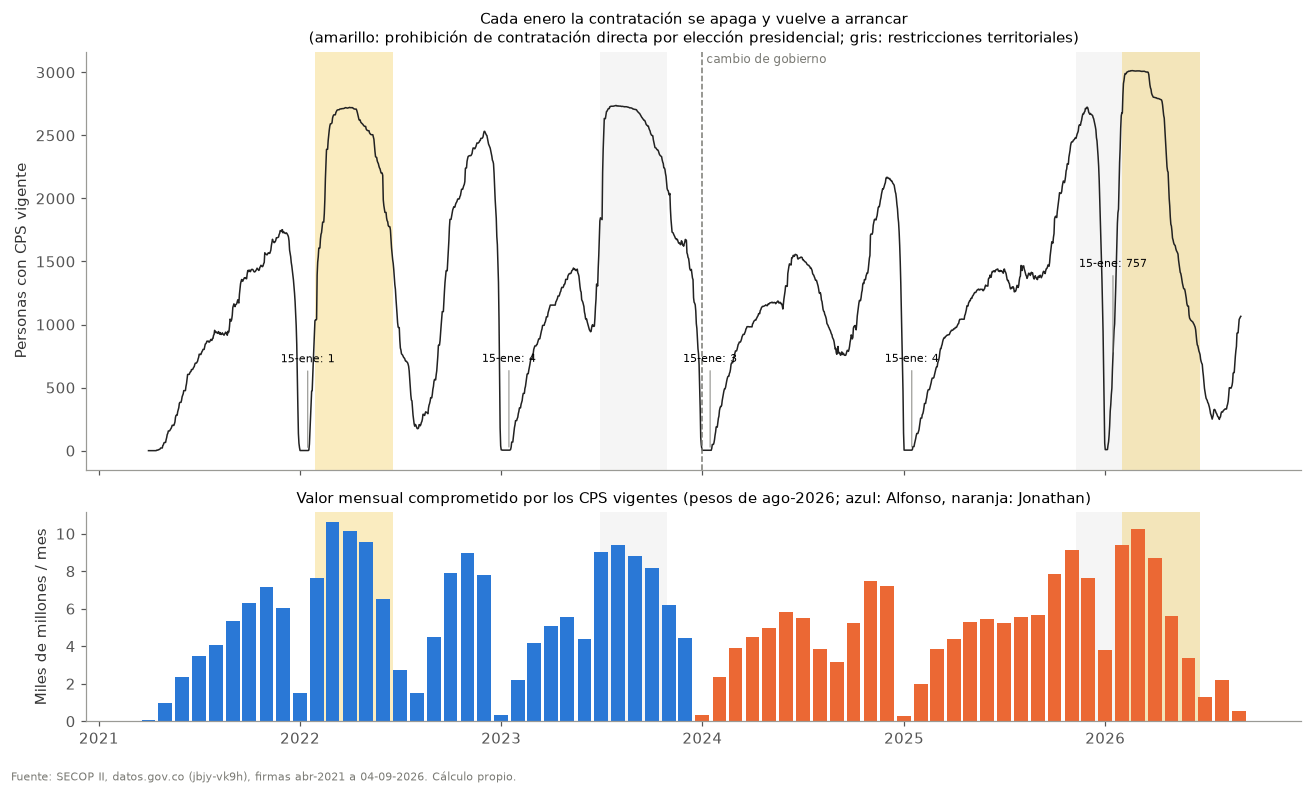

#### P07 · ¿Cuántas personas tienen contrato vigente cada día?

**Cada enero la contratación se apaga.** En un día cualquiera de los años completos había en promedio entre 1.124 y 1.661 personas con CPS vigente, con picos de hasta 2.737 (3.013 en 2026). Pero el 15 de enero de 2022 a 2025 había entre 1 y 4 personas: cada año hubo entre 19 y 24 días con menos de 100 contratistas. 2026 rompe el patrón: el 15 de enero ya había 757. Coincide con que ese año los CPS empezaron a firmarse antes: la primera tanda de enero (10 o más CPS en un día) llegó el 5 de enero, frente al 15–18 de enero de los años completos (Acto 5).

**Qué no significa:** No significa que los servicios se suspendan ni que las personas queden sin ingresos: describe la vigencia pactada de los CPS.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Fechas pactadas; una terminación anticipada no registrada infla la vigencia.

,anio,promedio_personas_dia,minimo,maximo,dias_con_menos_de_100,valor_real_comprometido,fecha_maximo,personas_15_enero,personas_15_marzo,primera_tanda_enero
0,2021,924.363636,0,1752,35,3.578384e+10,2021-11-30,<NA>,<NA>,NaT
1,2022,1661.093151,1,2722,19,7.939389e+10,2022-04-01,1,2709,2022-01-17
2,2023,1541.178082,4,2737,24,6.771150e+10,2023-07-28,4,950,2023-01-18
3,2024,1123.877049,3,2167,23,5.427957e+10,2024-11-30,3,922,2024-01-17
4,2025,1346.786301,4,2724,23,6.219283e+10,2025-11-29,4,897,2025-01-15
5,2026,1558.364372,8,3013,7,4.518386e+10,2026-02-17,757,3004,2026-01-05


In [11]:
DIAS = pd.date_range(INICIO, CORTE, freq="D")


def serie_diaria(inicios, fines_excl, pesos):
    # Suma por día con arreglo de diferencias: +peso al inicio, -peso al fin (exclusivo)
    n = len(DIAS)
    dif = np.zeros(n + 1)
    i = np.clip(DIAS.searchsorted(pd.DatetimeIndex(inicios)), 0, n)
    f = np.clip(DIAS.searchsorted(pd.DatetimeIndex(fines_excl)), 0, n)
    np.add.at(dif, i, pesos)
    np.add.at(dif, f, -np.asarray(pesos, dtype=float))
    return np.cumsum(dif)[:n]


costo = cpsi.loc[cpsi["valor_real"].notna()]
diario = pd.DataFrame({"fecha": DIAS,
                       "personas_con_cps": serie_diaria(episodios["inicio"], episodios["fin_excl"], np.ones(len(episodios))).round().astype(int),
                       "valor_diario_real": serie_diaria(costo["fecha_inicio"], costo["fin_excl"],
                                                         (costo["valor_real"] / costo["duracion_dias_incl"]).to_numpy())})
diario["anio"] = diario["fecha"].dt.year
diario["mes"] = diario["fecha"].dt.to_period("M").dt.to_timestamp()
t_p7 = (diario.groupby("anio").agg(promedio_personas_dia=("personas_con_cps", "mean"), minimo=("personas_con_cps", "min"),
                                   maximo=("personas_con_cps", "max"),
                                   dias_con_menos_de_100=("personas_con_cps", lambda s: int(s.lt(100).sum())),
                                   valor_real_comprometido=("valor_diario_real", "sum")).reset_index())
t_p7["fecha_maximo"] = t_p7["anio"].map(diario.loc[diario.groupby("anio")["personas_con_cps"].idxmax()].set_index("anio")["fecha"])
for _dia, _col in [("01-15", "personas_15_enero"), ("03-15", "personas_15_marzo")]:
    _v = diario.loc[diario["fecha"].dt.strftime("%m-%d").eq(_dia)].set_index("anio")["personas_con_cps"]
    t_p7[_col] = t_p7["anio"].map(_v).astype("Int64")
mensual = diario.groupby("mes").agg(personas_promedio=("personas_con_cps", "mean"), valor_real_mes=("valor_diario_real", "sum")).reset_index()

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for _, r in restr.iterrows():
    for a_ in ax:
        a_.axvspan(r["fecha_inicio"], r["fecha_fin"], color="#f2c94c" if r["norma"] == "Art. 33" else "#d9d9d9",
                   alpha=0.35 if r["norma"] == "Art. 33" else 0.25, lw=0)
ax[0].plot(diario["fecha"], diario["personas_con_cps"], color="#222222", lw=1)
ax[0].axvline(CAMBIO, color=GRIS, ls="--", lw=1)
ax[0].text(CAMBIO, diario["personas_con_cps"].max() * 1.02, " cambio de gobierno", fontsize=8, color=GRIS)
for a in sorted(diario["anio"].unique())[1:]:
    f = pd.Timestamp(f"{a}-01-15")
    v = int(diario.loc[diario["fecha"].eq(f), "personas_con_cps"].iloc[0])
    ax[0].annotate(es(f"15-ene: {v:,}"), (f, v), xytext=(f, v + 700), fontsize=7, ha="center",
                   arrowprops=dict(arrowstyle="-", color=GRIS, lw=0.6))
ax[0].set_ylabel("Personas con CPS vigente")
ax[0].set_title("Cada enero la contratación se apaga y vuelve a arrancar\n"
                "(amarillo: prohibición de contratación directa por elección presidencial; gris: restricciones territoriales)", fontsize=10)
ax[1].bar(mensual["mes"], mm(mensual["valor_real_mes"]), width=25, color=[color_anio(m.year) for m in mensual["mes"]])
ax[1].set_ylabel("Miles de millones / mes")
ax[1].set_title("Valor mensual comprometido por los CPS vigentes (pesos de ago-2026; azul: Alfonso, naranja: Jonathan)", fontsize=10)
g_p7 = guardar_fig(fig, "a2_pulso_diario.png")

p7 = t_p7.set_index("anio")
_dia_firma = cps.groupby("fecha_firma").size()
primera_tanda = pd.Series({a: _dia_firma.loc[(_dia_firma.index.year == a) & (_dia_firma.index.month == 1) & (_dia_firma.values >= 10)].index.min()
                           for a in [*ANIOS_COMPLETOS, CORTE.year]})
t_p7["primera_tanda_enero"] = t_p7["anio"].map(primera_tanda)
insight("P07", "Acto 2 · La vida de un contratista", "¿Cuántas personas tienen contrato vigente cada día?",
        "Cada enero la contratación se apaga",
        f"En un día cualquiera de los años completos había en promedio entre {p7.loc[ANIOS_COMPLETOS, 'promedio_personas_dia'].min():,.0f} y "
        f"{p7.loc[ANIOS_COMPLETOS, 'promedio_personas_dia'].max():,.0f} personas con CPS vigente, con picos de hasta "
        f"{int(p7.loc[ANIOS_COMPLETOS, 'maximo'].max()):,} ({int(p7.loc[CORTE.year, 'maximo']):,} en {CORTE.year}). Pero el 15 de enero de 2022 a 2025 había entre {p7.loc[2022:2025, 'personas_15_enero'].min()} "
        f"y {p7.loc[2022:2025, 'personas_15_enero'].max()} personas: cada año hubo entre {p7.loc[ANIOS_COMPLETOS, 'dias_con_menos_de_100'].min()} y "
        f"{p7.loc[ANIOS_COMPLETOS, 'dias_con_menos_de_100'].max()} días con menos de 100 contratistas. {CORTE.year} rompe el patrón: el 15 de enero "
        f"ya había {p7.loc[CORTE.year, 'personas_15_enero']:,}. Coincide con que ese año los CPS empezaron a firmarse antes: la "
        f"primera tanda de enero (10 o más CPS en un día) llegó el {primera_tanda.loc[CORTE.year].day} de enero, frente al "
        f"{primera_tanda.loc[ANIOS_COMPLETOS].dt.day.min()}–{primera_tanda.loc[ANIOS_COMPLETOS].dt.day.max()} de enero de los años completos (Acto 5).",
        "No significa que los servicios se suspendan ni que las personas queden sin ingresos: describe la vigencia pactada de los CPS.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "CPS de personas, Alcaldía central, vigencia 1–366 días",
        "Fechas pactadas; una terminación anticipada no registrada infla la vigencia.", t_p7, g_p7,
        cifra=f"15-ene: {p7.loc[2022:2025, 'personas_15_enero'].min()}–{p7.loc[2022:2025, 'personas_15_enero'].max()} personas; promedio diario "
              f"{p7.loc[ANIOS_COMPLETOS, 'promedio_personas_dia'].min():,.0f}–{p7.loc[ANIOS_COMPLETOS, 'promedio_personas_dia'].max():,.0f}")
SALIDAS["serie_diaria"] = guardar_tabla(diario.drop(columns=["mes"]), "serie_diaria_personas_valor.csv")
t_p7

## P8 · ¿Qué tan frecuentes son las prórrogas?

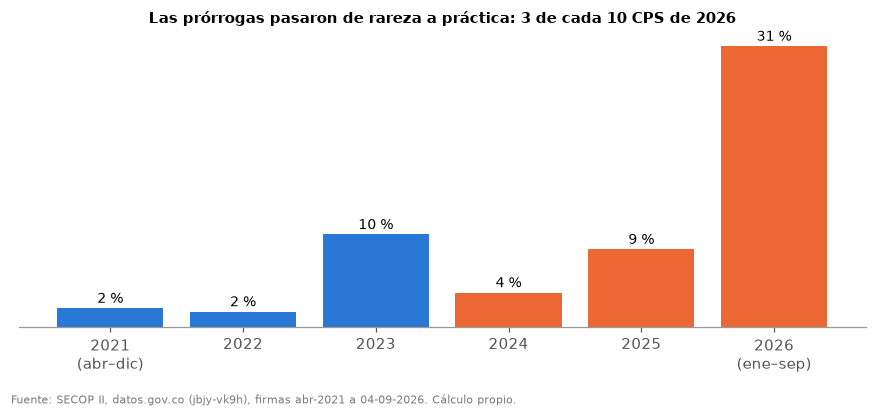

#### P08 · ¿Qué tan frecuentes son las prórrogas?

**Las prórrogas se volvieron frecuentes.** El porcentaje de CPS con días adicionados pasó de 2 % en 2022 a 31 % en 2026 (hasta el corte), con una prórroga mediana de 32 días. En 2026 casi todas son de contratos firmados en enero, antes de la Ley de Garantías (Acto 5).

**Qué no significa:** Prorrogar está previsto en la ley y el dato no evalúa cada prórroga. Lo que cambia es la forma de contratar: más extensiones de contratos vigentes.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Los contratos de 2026 siguen en ejecución y pueden sumar más prórrogas.

,anio,cps,con_dias_adicionados,mediana_dias_adicionados,pct_con_dias_adicionados,pct_en_ejecucion
0,2021,2838,58,26.5,2.0,4.1
1,2022,5537,92,15.0,1.7,2.1
2,2023,4380,448,41.0,10.2,8.9
3,2024,4558,172,18.5,3.8,22.0
4,2025,4639,398,30.0,8.6,41.8
5,2026,4176,1300,32.0,31.1,63.0


In [12]:
t_p8 = cps.groupby("anio").agg(cps=("id_contrato", "size"), con_dias_adicionados=("flag_dias_adicionados", "sum"),
                               mediana_dias_adicionados=("dias_adicionados", lambda s: s[s.gt(0)].median())).reset_index()
t_p8["pct_con_dias_adicionados"] = t_p8["con_dias_adicionados"] / t_p8["cps"] * 100
t_p8["pct_en_ejecucion"] = t_p8["anio"].map(cps.groupby("anio")["estado_contrato"].apply(lambda s: s.eq("En ejecución").mean() * 100))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar([rotulo_anio(a) for a in t_p8["anio"]], t_p8["pct_con_dias_adicionados"], color=[color_anio(a) for a in t_p8["anio"]])
for i, v in enumerate(t_p8["pct_con_dias_adicionados"]):
    ax.text(i, v + 0.6, f"{v:.0f} %", ha="center", fontsize=9)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_title("Las prórrogas pasaron de rareza a práctica: 3 de cada 10 CPS de 2026", fontsize=10, fontweight="bold")
g_p8 = guardar_fig(fig, "a2_prorrogas.png")
d8 = t_p8.set_index("anio")
insight("P08", "Acto 2 · La vida de un contratista", "¿Qué tan frecuentes son las prórrogas?",
        "Las prórrogas se volvieron frecuentes",
        f"El porcentaje de CPS con días adicionados pasó de {d8.loc[2022, 'pct_con_dias_adicionados']:.0f} % en 2022 a "
        f"{d8.loc[CORTE.year, 'pct_con_dias_adicionados']:.0f} % en {CORTE.year} (hasta el corte), con una prórroga mediana de "
        f"{d8.loc[CORTE.year, 'mediana_dias_adicionados']:.0f} días. En {CORTE.year} casi todas son de contratos firmados en enero, antes de la "
        f"Ley de Garantías (Acto 5).",
        "Prorrogar está previsto en la ley y el dato no evalúa cada prórroga. Lo que cambia es la forma de contratar: más extensiones de contratos vigentes.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "CPS de personas, Alcaldía central",
        f"Los contratos de {CORTE.year} siguen en ejecución y pueden sumar más prórrogas.", t_p8, g_p8,
        cifra=f"{d8.loc[2022, 'pct_con_dias_adicionados']:.0f} % → {d8.loc[CORTE.year, 'pct_con_dias_adicionados']:.0f} % de CPS prorrogados")
t_p8.round(1)

# 3 El dinero en el bolsillo
## P9 ¿Cuánto pacta al mes un profesional y un apoyo a la gestión con cada alcalde?
**Valor mensual equivalente** = valor del contrato ÷ meses pactados. **No es un salario**: no descuenta seguridad social ni impuestos,
y la persona puede tener meses sin contrato. Se muestra en tres monedas: pesos de cada año (nominal), pesos constantes de
agosto de 2026 (descontando la inflación) y salarios mínimos del año de firma.

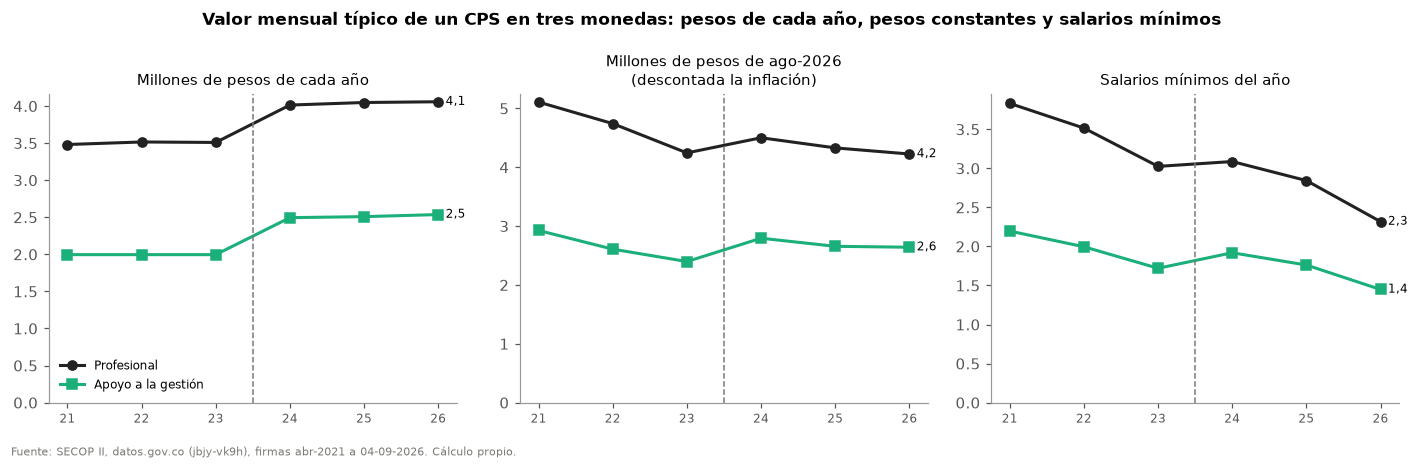

#### P09 · ¿Cuánto pacta al mes un profesional y un apoyo a la gestión con cada alcalde?

**Más pesos, menos poder de compra con el paso del tiempo.** En pesos de cada año, con Alfonso (abr-2021 a dic-2023) un CPS profesional pactó en promedio 3,72 millones al mes (mediana 3,51) y uno de apoyo a la gestión 2,07 (mediana 2,00). Con Jonathan (ene-2024 al corte): profesional 4,25 (mediana 4,02) y apoyo 2,60 (mediana 2,54). En pesos de cada año las cifras incluyen el efecto de la inflación. Descontando la inflación, la mediana profesional pasó de 5,1 millones en 2021 a 4,2 en 2026 (pesos de agosto de 2026), y en salarios mínimos de 3,8 a 2,3: los honorarios crecieron menos que la inflación y mucho menos que el salario mínimo. La caída empezó en 2022 y 2023, tuvo un repunte en 2024 y siguió después, así que no se atribuye a un alcalde (el 06 marca esa comparación como no publicable). En apoyo a la gestión la mediana real cambió -9,7 % entre 2021 y 2026, o -9,7 % si los contratos de subtipo ambiguo se cuentan como apoyo: la magnitud depende del clasificador.

**Qué no significa:** No es salario ni ingreso: no descuenta aportes ni cuenta los meses sin contrato. No dice si un gobierno paga más o menos que otro.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* El subtipo profesional/apoyo sale del texto del contrato (SIN_VALIDACION_MANUAL). IPC nacional.

,ventana,gobierno,subtipo,contratos,promedio_nominal,mediana_nominal
0,Gobierno completo observado,Alfonso Eljach,Profesional,5894,3723680.0,3512019.0
1,Gobierno completo observado,Alfonso Eljach,Apoyo a la gestión,6237,2065902.0,1995902.0
2,Gobierno completo observado,Jonathan Vásquez,Profesional,6548,4249817.0,4024793.0
3,Gobierno completo observado,Jonathan Vásquez,Apoyo a la gestión,6467,2601024.0,2536458.0
4,Año 3 del mandato (ene–ago),Alfonso Eljach,Profesional,1602,3773572.0,3527525.0
5,Año 3 del mandato (ene–ago),Alfonso Eljach,Apoyo a la gestión,1701,2013289.0,1995902.0
6,Año 3 del mandato (ene–ago),Jonathan Vásquez,Profesional,1842,4255675.0,4058333.0
7,Año 3 del mandato (ene–ago),Jonathan Vásquez,Apoyo a la gestión,2215,2698062.0,2536458.0


In [13]:
SUBTIPOS = ["Profesional", "Apoyo a la gestión"]
vm = cps.loc[cps["apto_valor_mensual"] & cps["valor_mensual_real"].notna() & cps["subtipo_cps"].isin(SUBTIPOS)]
filas = []
for _, v in VENTANAS.iterrows():
    for sub in SUBTIPOS:
        d = en_ventana(vm, v)
        d = d.loc[d["subtipo_cps"].eq(sub)]
        filas.append({"ventana": v["ventana"], "gobierno": v["gobierno"], "subtipo": sub, "contratos": len(d),
                      "promedio_nominal": d["valor_mensual_equiv"].mean(), "mediana_nominal": d["valor_mensual_equiv"].median(),
                      "promedio_real": d["valor_mensual_real"].mean(), "mediana_real": d["valor_mensual_real"].median(),
                      "p25_real": d["valor_mensual_real"].quantile(0.25), "p75_real": d["valor_mensual_real"].quantile(0.75),
                      "mediana_salarios_minimos": d["valor_mensual_smmlv"].median()})
t_p9 = pd.DataFrame(filas)
t_p9b = (vm.groupby(["anio", "subtipo_cps"]).agg(contratos=("valor_mensual_equiv", "size"),
                                                  mediana_nominal=("valor_mensual_equiv", "median"),
                                                  mediana_real=("valor_mensual_real", "median"),
                                                  mediana_salarios_minimos=("valor_mensual_smmlv", "median")).reset_index())
t_p9b["salario_minimo"] = t_p9b["anio"].map(smmlv)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for sub, color, mk in [("Profesional", "#222222", "o"), ("Apoyo a la gestión", VERDE, "s")]:
    d = t_p9b.loc[t_p9b["subtipo_cps"].eq(sub)]
    for a_, col, esc in zip(ax, ["mediana_nominal", "mediana_real", "mediana_salarios_minimos"], [1e6, 1e6, 1]):
        a_.plot(d["anio"], d[col] / esc, marker=mk, color=color, lw=2, ms=6, label=sub)
        a_.text(d["anio"].iloc[-1] + 0.1, d[col].iloc[-1] / esc, es(f"{d[col].iloc[-1] / esc:.1f}"), va="center", fontsize=8)
for a_, t_ in zip(ax, ["Millones de pesos de cada año", "Millones de pesos de ago-2026\n(descontada la inflación)",
                       "Salarios mínimos del año"]):
    a_.set_title(t_, fontsize=10)
    a_.axvline(CAMBIO.year - 0.5, color=GRIS, ls="--", lw=1)
    a_.set_xticks(sorted(t_p9b["anio"].unique()), [str(a)[2:] for a in sorted(t_p9b["anio"].unique())], fontsize=8)
    a_.set_ylim(bottom=0)
ax[0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("Valor mensual típico de un CPS en tres monedas: pesos de cada año, pesos constantes y salarios mínimos",
             fontweight="bold", fontsize=11)
g_p9 = guardar_fig(fig, "a3_honorarios_tres_monedas.png")

h = t_p9.loc[t_p9["ventana"].eq(ORDEN_VENT[0])].set_index(["gobierno", "subtipo"])
P, AP = "Profesional", "Apoyo a la gestión"
serie = t_p9b.set_index(["subtipo_cps", "anio"])
a0, a1 = int(t_p9b["anio"].min()), int(t_p9b["anio"].max())
# Sensibilidad al clasificador: contar los "Ambiguo" como apoyo
# apto_valor_mensual excluye los ambiguos; se replica su regla (30 días o más, valor positivo) para incluirlos
vm_amb = cps.loc[cps["subtipo_cps"].isin([AP, "Ambiguo"]) & cps["valor_contrato"].gt(0) & cps["duracion_dias_incl"].ge(30)
                 & cps["valor_mensual_real"].notna()]
sens_apoyo = pd.DataFrame({"solo_apoyo": vm.loc[vm["subtipo_cps"].eq(AP)].groupby("anio")["valor_mensual_real"].median(),
                           "apoyo_mas_ambiguos": vm_amb.groupby("anio")["valor_mensual_real"].median()})
apo = (sens_apoyo["solo_apoyo"].iloc[-1] / sens_apoyo["solo_apoyo"].iloc[0] - 1) * 100
apo_amb = (sens_apoyo["apoyo_mas_ambiguos"].iloc[-1] / sens_apoyo["apoyo_mas_ambiguos"].iloc[0] - 1) * 100
insight("P09", "Acto 3 · El dinero en el bolsillo", "¿Cuánto pacta al mes un profesional y un apoyo a la gestión con cada alcalde?",
        "Más pesos, menos poder de compra con el paso del tiempo",
        f"En pesos de cada año, con Alfonso (abr-2021 a dic-2023) un CPS profesional pactó en promedio {millones(h.loc[(A, P), 'promedio_nominal']):.2f} "
        f"millones al mes (mediana {millones(h.loc[(A, P), 'mediana_nominal']):.2f}) y uno de apoyo a la gestión {millones(h.loc[(A, AP), 'promedio_nominal']):.2f} "
        f"(mediana {millones(h.loc[(A, AP), 'mediana_nominal']):.2f}). Con Jonathan (ene-2024 al corte): profesional "
        f"{millones(h.loc[(J, P), 'promedio_nominal']):.2f} (mediana {millones(h.loc[(J, P), 'mediana_nominal']):.2f}) y apoyo "
        f"{millones(h.loc[(J, AP), 'promedio_nominal']):.2f} (mediana {millones(h.loc[(J, AP), 'mediana_nominal']):.2f}). En pesos de cada año las "
        f"cifras incluyen el efecto de la inflación. Descontando la inflación, la mediana profesional pasó de {millones(serie.loc[(P, a0), 'mediana_real']):.1f} millones "
        f"en {a0} a {millones(serie.loc[(P, a1), 'mediana_real']):.1f} en {a1} (pesos de agosto de 2026), y en salarios mínimos de "
        f"{serie.loc[(P, a0), 'mediana_salarios_minimos']:.1f} a {serie.loc[(P, a1), 'mediana_salarios_minimos']:.1f}: los honorarios crecieron menos "
        f"que la inflación y mucho menos que el salario mínimo. La caída empezó en 2022–2023, tuvo un repunte en 2024 y siguió después, así que no se atribuye a un "
        f"alcalde (el 06 marca esa comparación como no publicable). En apoyo a la gestión la mediana real cambió "
        f"{apo:+.1f} % entre {a0} y {a1}, o {apo_amb:+.1f} % si los contratos de subtipo ambiguo se cuentan como apoyo: la magnitud "
        f"depende del clasificador.".replace("2022–2023", "2022 y 2023"),
        "No es salario ni ingreso: no descuenta aportes ni cuenta los meses sin contrato. No dice si un gobierno paga más o menos que otro.",
        "Dato descriptivo", "PUBLICABLE_CON_CAUTELA", "CPS de personas con 30 días o más y subtipo claro, Alcaldía central",
        f"El subtipo profesional/apoyo sale del texto del contrato ({VALIDACION}). IPC nacional.",
        # Por periodo solo pesos de cada año: la comparación real entre gobiernos no se publica (Q06B del 06)
        pd.concat([t_p9.drop(columns=["promedio_real", "mediana_real", "p25_real", "p75_real", "mediana_salarios_minimos"]),
                   t_p9b, sens_apoyo.reset_index(names="anio")], ignore_index=True), g_p9,
        cifra=(f"mediana profesional descontando inflación: {millones(serie.loc[(P, a0), 'mediana_real']):.1f} M ({a0}) → "
               f"{millones(serie.loc[(P, a1), 'mediana_real']):.1f} M ({a1}) al mes"))
t_p9.drop(columns=["promedio_real", "mediana_real", "p25_real", "p75_real", "mediana_salarios_minimos"]).round(0)

## P10 A la misma persona, ¿le cambió el valor mensual?
Dos diseños con la misma persona (así se elimina el efecto de contratar perfiles distintos): (1) su último CPS con Alfonso frente a su
primer CPS con Jonathan, del mismo subtipo; (2) del cuaderno 04, la misma persona en enero–agosto de 2022 frente a enero–agosto de 2026.

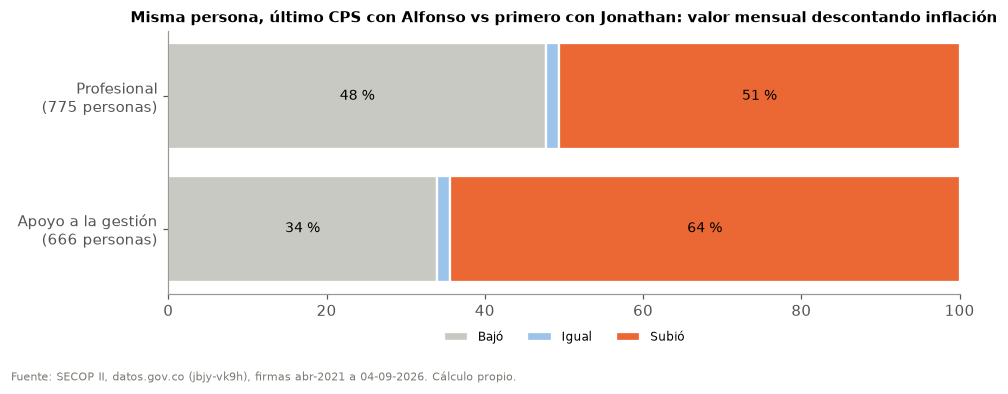

#### P10 · A la misma persona, ¿le cambió el valor mensual?

**Para la misma persona, el resultado depende de cuándo se mida.** De las 775 personas con CPS profesional en ambos gobiernos, al comparar su último contrato con Alfonso y su primero con Jonathan (una mediana de 12 meses después), el valor mensual subió +11,9 % en pesos de cada año y +0,7 % descontando la inflación (mediana), pero el 48 % perdió poder de compra. Si la misma persona se compara con cuatro años de distancia (enero–agosto de 2022 frente a 2026, cuaderno 04), la mediana real profesional cae -12,6 % y solo el 21 % tuvo aumento. En apoyo a la gestión: +8,7 % real en el cambio de gobierno y +1,2 % entre 2022 y 2026. La lectura consistente es la de la serie (P09): los valores reales se erosionan con el tiempo, con un repunte puntual en el cambio de gobierno.

**Qué no significa:** No es un aumento ni un recorte de sueldo: el objeto del contrato puede cambiar y entre un contrato y otro pasa tiempo. No permite decir que un alcalde pague más o menos.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Subtipo por texto (SIN_VALIDACION_MANUAL); el resultado cambia con el intervalo de tiempo entre contratos.

,subtipo_cps,personas,meses_entre_firmas_mediana,mediana_cambio_nominal_pct,mediana_cambio_real_pct,pct_bajo_real,pct_igual_real,pct_subio_real,cuaderno04_2022_vs_2026_personas_pareadas,cuaderno04_2022_vs_2026_mediana_cambio_pct,cuaderno04_2022_vs_2026_pct_personas_con_aumento
0,Apoyo a la gestión,666,18.3,21.4,8.7,33.9,1.7,64.4,217,1.2,52.5
1,Profesional,775,12.0,11.9,0.7,47.7,1.7,50.6,265,-12.6,20.8


In [14]:
vm_s = vm.sort_values(["fecha_firma", "id_contrato"])
ult_a = vm_s.loc[vm_s["gobierno"].eq(A)].groupby([PERSONA, "subtipo_cps"]).last()
pri_j = vm_s.loc[vm_s["gobierno"].eq(J)].groupby([PERSONA, "subtipo_cps"]).first()
par = ult_a[["valor_mensual_equiv", "valor_mensual_real", "fecha_firma"]].join(
    pri_j[["valor_mensual_equiv", "valor_mensual_real", "fecha_firma"]], lsuffix="_A", rsuffix="_J", how="inner")
par["cambio_nominal_pct"] = (par["valor_mensual_equiv_J"] / par["valor_mensual_equiv_A"] - 1) * 100
par["cambio_real_pct"] = (par["valor_mensual_real_J"] / par["valor_mensual_real_A"] - 1) * 100
par["meses_entre_contratos"] = (par["fecha_firma_J"] - par["fecha_firma_A"]).dt.days / MES_DIAS
t_p10 = (par.reset_index().groupby("subtipo_cps")
         .agg(personas=(PERSONA, "size"), meses_entre_firmas_mediana=("meses_entre_contratos", "median"),
              mediana_cambio_nominal_pct=("cambio_nominal_pct", "median"), mediana_cambio_real_pct=("cambio_real_pct", "median"),
              pct_bajo_real=("cambio_real_pct", lambda s: s.lt(-0.5).mean() * 100),
              pct_igual_real=("cambio_real_pct", lambda s: s.abs().le(0.5).mean() * 100),
              pct_subio_real=("cambio_real_pct", lambda s: s.gt(0.5).mean() * 100)).reset_index())
dp04 = su.leer_csv(r04["dentro_persona"]).set_index("subtipo")
t_p10 = t_p10.merge(dp04[["personas_pareadas", "mediana_cambio_pct", "pct_personas_con_aumento"]].add_prefix("cuaderno04_2022_vs_2026_"),
                    left_on="subtipo_cps", right_index=True, how="left")
fig, ax = plt.subplots(figsize=(9, 3.4))
y = np.arange(len(t_p10))
izq = np.zeros(len(t_p10))
for col, color, lab in [("pct_bajo_real", "#c9c9c4", "Bajó"), ("pct_igual_real", "#9cc3ea", "Igual"), ("pct_subio_real", NARANJA, "Subió")]:
    ax.barh(y, t_p10[col], left=izq, color=color, label=lab, edgecolor="white", linewidth=1.5)
    for i, (l, w) in enumerate(zip(izq, t_p10[col])):
        if w >= 5:
            ax.text(l + w / 2, i, f"{w:.0f} %", ha="center", va="center", fontsize=9)
    izq += t_p10[col].to_numpy()
ax.set_yticks(y, [es(f"{s}\n({n:,} personas)") for s, n in zip(t_p10["subtipo_cps"], t_p10["personas"])])
ax.set_xlim(0, 100)
ax.legend(ncol=3, frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1))
ax.set_title("Misma persona, último CPS con Alfonso vs primero con Jonathan: valor mensual descontando inflación",
             fontsize=10, fontweight="bold")
g_p10 = guardar_fig(fig, "a3_misma_persona.png")
tp10 = t_p10.set_index("subtipo_cps")
insight("P10", "Acto 3 · El dinero en el bolsillo", "A la misma persona, ¿le cambió el valor mensual?",
        "Para la misma persona, el resultado depende de cuándo se mida",
        f"De las {tp10.loc[P, 'personas']:,} personas con CPS profesional en ambos gobiernos, al comparar su último contrato con Alfonso y su "
        f"primero con Jonathan (una mediana de {tp10.loc[P, 'meses_entre_firmas_mediana']:.0f} meses después), el valor mensual subió "
        f"{tp10.loc[P, 'mediana_cambio_nominal_pct']:+.1f} % en pesos de cada año y {tp10.loc[P, 'mediana_cambio_real_pct']:+.1f} % descontando la "
        f"inflación (mediana), pero el {tp10.loc[P, 'pct_bajo_real']:.0f} % perdió poder de compra. Si la misma persona se compara con cuatro años "
        f"de distancia (enero–agosto de 2022 frente a 2026, cuaderno 04), la mediana real profesional cae "
        f"{tp10.loc[P, 'cuaderno04_2022_vs_2026_mediana_cambio_pct']:+.1f} % y solo el "
        f"{tp10.loc[P, 'cuaderno04_2022_vs_2026_pct_personas_con_aumento']:.0f} % tuvo aumento. En apoyo a la gestión: "
        f"{tp10.loc[AP, 'mediana_cambio_real_pct']:+.1f} % real en el cambio de gobierno y "
        f"{tp10.loc[AP, 'cuaderno04_2022_vs_2026_mediana_cambio_pct']:+.1f} % entre 2022 y 2026. La lectura consistente es la de la serie (P09): "
        f"los valores reales se erosionan con el tiempo, con un repunte puntual en el cambio de gobierno.",
        "No es un aumento ni un recorte de sueldo: el objeto del contrato puede cambiar y entre un contrato y otro pasa tiempo. "
        "No permite decir que un alcalde pague más o menos.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "Personas con CPS del mismo subtipo en ambos gobiernos, 30 días o más",
        f"Subtipo por texto ({VALIDACION}); el resultado cambia con el intervalo de tiempo entre contratos.", t_p10, g_p10,
        cifra=f"profesional misma persona: {tp10.loc[P, 'pct_bajo_real']:.0f} % perdió poder de compra en el cambio de gobierno")
t_p10.round(1)

## P11 ¿Cómo se reparte el dinero de los CPS entre las personas?

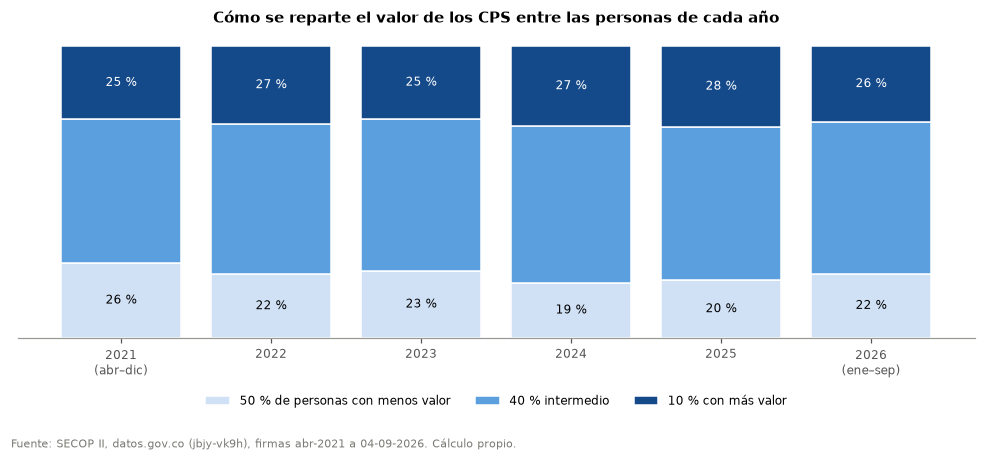

#### P11 · ¿Cómo se reparte el dinero de los CPS entre las personas?

**Sin concentración extrema.** En los años completos, el 10 % de las personas con más valor contratado reunió entre 25 % y 28 % del total, y la mitad con menos valor entre 19 % y 23 % (índice de Gini 0,38–0,43): hay desigualdad moderada, sin un grupo pequeño que concentre la mayor parte. En un año completo, una persona sumó en promedio entre 19,2 y 22,5 millones de pesos constantes en CPS (mediana 14,0–18,0); el 10 % superior pasó de 42,7 millones.

**Qué no significa:** No mide ingresos totales: una persona puede tener otros contratos, empleos o fuentes.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE` · *Límite:* Valor pactado al firmar, no pagado.

,anio,personas,valor_real_promedio_por_persona,valor_real_mediano_por_persona,valor_real_p90_por_persona,pct_valor_top10,pct_valor_40_medio,pct_valor_mitad_inferior,gini
0,2021,2265,15892772.46,13199673.94,29348243.72,25.02,49.32,25.66,0.35
1,2022,3548,22536750.59,16303062.21,47761379.95,26.58,51.61,21.81,0.40
2,2023,3038,22293963.10,17986993.57,44307479.54,24.84,52.24,22.92,0.38
3,2024,2666,20395409.31,14730630.90,44829371.15,27.27,53.89,18.85,0.43
4,2025,3241,19248992.86,14028519.21,42660264.26,27.59,52.67,19.74,0.42
5,2026,3123,18928552.65,12494580.39,41052243.57,25.83,52.16,22.01,0.39


In [15]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return float((2 * np.arange(1, n + 1) - n - 1).dot(x) / (n * x.sum()))


filas = []
for a, d in cps.loc[cps["valor_real"].notna()].groupby("anio"):
    v = d.groupby(PERSONA)["valor_real"].sum().sort_values(ascending=False).to_numpy()
    k10, k50 = int(np.ceil(len(v) * 0.1)), len(v) // 2
    filas.append({"anio": a, "personas": len(v), "valor_real_promedio_por_persona": float(v.mean()),
                  "valor_real_mediano_por_persona": float(np.median(v)), "valor_real_p90_por_persona": float(np.quantile(v, 0.9)),
                  "pct_valor_top10": v[:k10].sum() / v.sum() * 100, "pct_valor_40_medio": v[k10:len(v) - k50].sum() / v.sum() * 100,
                  "pct_valor_mitad_inferior": v[len(v) - k50:].sum() / v.sum() * 100, "gini": gini(v)})
t_p11 = pd.DataFrame(filas)
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(t_p11))
ax.bar(x, t_p11["pct_valor_mitad_inferior"], color="#d0e1f5", label="50 % de personas con menos valor", edgecolor="white")
ax.bar(x, t_p11["pct_valor_40_medio"], bottom=t_p11["pct_valor_mitad_inferior"], color="#5c9fdf", label="40 % intermedio", edgecolor="white")
ax.bar(x, t_p11["pct_valor_top10"], bottom=t_p11["pct_valor_mitad_inferior"] + t_p11["pct_valor_40_medio"], color="#154a8a",
       label="10 % con más valor", edgecolor="white")
for i, r in t_p11.iterrows():
    ax.text(i, 100 - r["pct_valor_top10"] / 2, f"{r['pct_valor_top10']:.0f} %", ha="center", va="center", color="white", fontsize=8)
    ax.text(i, r["pct_valor_mitad_inferior"] / 2, f"{r['pct_valor_mitad_inferior']:.0f} %", ha="center", va="center", fontsize=8)
ax.set_xticks(x, [rotulo_anio(a) for a in t_p11["anio"]], fontsize=8)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
ax.set_title("Cómo se reparte el valor de los CPS entre las personas de cada año", fontsize=10, fontweight="bold")
g_p11 = guardar_fig(fig, "a3_reparto.png")
rb = t_p11.set_index("anio")
insight("P11", "Acto 3 · El dinero en el bolsillo", "¿Cómo se reparte el dinero de los CPS entre las personas?",
        "Sin concentración extrema",
        f"En los años completos, el 10 % de las personas con más valor contratado reunió entre {rb.loc[ANIOS_COMPLETOS, 'pct_valor_top10'].min():.0f} % y "
        f"{rb.loc[ANIOS_COMPLETOS, 'pct_valor_top10'].max():.0f} % del total, y la mitad con menos valor entre "
        f"{rb.loc[ANIOS_COMPLETOS, 'pct_valor_mitad_inferior'].min():.0f} % y {rb.loc[ANIOS_COMPLETOS, 'pct_valor_mitad_inferior'].max():.0f} % "
        f"(índice de Gini {rb.loc[ANIOS_COMPLETOS, 'gini'].min():.2f}–{rb.loc[ANIOS_COMPLETOS, 'gini'].max():.2f}): hay desigualdad moderada, "
        f"sin un grupo pequeño que concentre la mayor parte. En un año completo, una persona sumó "
        f"en promedio entre {millones(rb.loc[ANIOS_COMPLETOS, 'valor_real_promedio_por_persona'].min()):.1f} y "
        f"{millones(rb.loc[ANIOS_COMPLETOS, 'valor_real_promedio_por_persona'].max()):.1f} millones de pesos constantes en CPS (mediana "
        f"{millones(rb.loc[ANIOS_COMPLETOS, 'valor_real_mediano_por_persona'].min()):.1f}–{millones(rb.loc[ANIOS_COMPLETOS, 'valor_real_mediano_por_persona'].max()):.1f}); "
        f"el 10 % superior pasó de {millones(rb.loc[ANIOS_COMPLETOS, 'valor_real_p90_por_persona'].min()):.1f} millones.",
        "No mide ingresos totales: una persona puede tener otros contratos, empleos o fuentes.",
        "Dato descriptivo", "PUBLICABLE", "CPS de personas, Alcaldía central, valor con IPC publicado",
        "Valor pactado al firmar, no pagado.", t_p11, g_p11,
        cifra=f"10 % superior: {rb.loc[ANIOS_COMPLETOS, 'pct_valor_top10'].min():.0f}–{rb.loc[ANIOS_COMPLETOS, 'pct_valor_top10'].max():.0f} % del valor")
t_p11.round(2)

# 4  Varias puertas: personas que contratan con varias entidades
## P12  ¿Cuántas personas han tenido contratos con la Alcaldía y también con EDUBA, INDERBA, el Concejo u otras?
Se cuentan CPS de personas naturales en las nueve entidades y, en la ESE, los servicios personales 
(se registran como Decreto 092). Las entidades **no atribuibles al alcalde** (Concejo, Personería, Contraloría, Hospital Regional)
se muestran aparte: son autónomas.

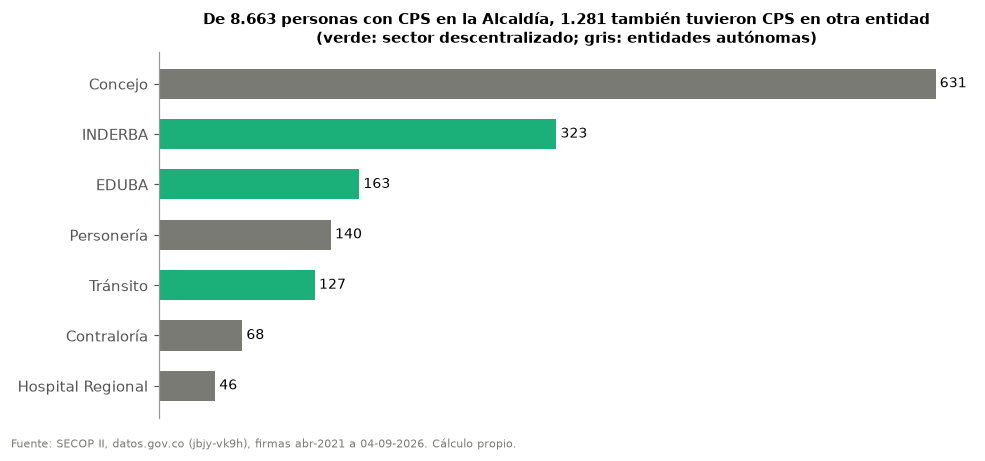

#### P12 · ¿Cuántas personas han contratado con la Alcaldía y también con otras entidades?

**15 % de los contratistas de la Alcaldía también tuvo CPS en otra entidad.** De las 8.663 personas con CPS en la Alcaldía central desde abril de 2021, 1.281 (15 %) también tuvieron CPS con otra entidad en algún momento: 631 con el Concejo, 323 con INDERBA, 163 con EDUBA, 140 con la Personería y 127 con Tránsito. 188 de ellas pasaron por tres o más entidades. Aparte, 397 contratistas de la Alcaldía aparecen en registros de servicios personales de la ESE que aún no se confirman como CPS. Cada entidad empezó a publicar con regularidad en SECOP II en un mes distinto (entre 2021-04 y 2025-07), por eso no se comparan gobiernos con este dato.

**Qué no significa:** Contratar con dos entidades no es irregular: casi siempre son contratos en momentos distintos. Si hubo contratos al mismo tiempo se revisa en el 05 y requiere expedientes. El Concejo, la Personería y la Contraloría no dependen del alcalde.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Cobertura de SECOP II distinta por entidad; combinaciones con menos de 10 personas no se muestran.

,combinacion,personas
0,Alcaldía + Concejo,486
1,Alcaldía + INDERBA,247
2,Alcaldía + EDUBA,110
3,Alcaldía + Tránsito,93
4,Alcaldía + Personería,74
5,Alcaldía + Contraloría,42
6,Alcaldía + Hospital Regional,41
7,Alcaldía + Concejo + INDERBA,39
8,Alcaldía + Concejo + Personería,35
9,Alcaldía + Concejo + EDUBA,21


,periodo,personas,con_2_o_mas_entidades,con_3_o_mas_entidades,con_4_o_mas_entidades,personas_alcaldia,alcaldia_y_otra,pct_2_o_mas,pct_alcaldia_y_otra,alcaldia_y_INDERBA,alcaldia_y_ESE,alcaldia_y_Concejo,alcaldia_y_EDUBA,alcaldia_y_Tránsito,alcaldia_y_Personería,alcaldia_y_Hospital Regional,alcaldia_y_Contraloría
0,abr-2021 al corte (solo CPS),9856,1334,190,26,8663,1281,13.5,14.8,323,0,631,163,127,140,46,68
1,abr-2021 al corte (con ESE por revisar),10467,1701,232,33,8663,1628,16.3,18.8,323,397,631,163,127,140,46,68
2,Alfonso Eljach,5623,618,60,4,4986,586,11.0,11.8,174,0,286,81,22,62,0,25
3,Jonathan Vásquez,6274,590,70,4,5256,549,9.4,10.4,97,0,297,31,67,70,39,23


In [16]:
CORTO = {"Alcaldía Distrital de Barrancabermeja": "Alcaldía", "INDERBA (deporte y recreación)": "INDERBA",
         "ESE Barrancabermeja": "ESE", "Concejo de Barrancabermeja": "Concejo",
         "EDUBA (desarrollo urbano y vivienda)": "EDUBA", "Inspección de Tránsito y Transporte": "Tránsito",
         "Personería de Barrancabermeja": "Personería", "Hospital Regional del Magdalena Medio": "Hospital Regional",
         "Contraloría de Barrancabermeja": "Contraloría"}
todas = b.loc[b["es_valido_general"] & b["fecha_firma"].ge(INICIO)].copy()
todas["anio"] = todas["fecha_firma"].dt.year
todas["gobierno"] = gobierno_de(todas["fecha_firma"])
per = todas.loc[todas["apto_identidad"] & todas["es_natural"] & (todas["es_cps_estricto"] | todas["es_servicio_persona_por_revisar"])].copy()
per["ent"] = per["entidad"].map(CORTO)
GRUPO_ENT = per.groupby("ent")["grupo_atribucion"].first()


def resumen_multi(d, etiqueta):
    s = d.groupby(PERSONA)["ent"].agg(lambda x: frozenset(x))
    con_alc = s[s.map(lambda x: "Alcaldía" in x)]
    fila = {"periodo": etiqueta, "personas": len(s), "con_2_o_mas_entidades": int(s.map(len).ge(2).sum()),
            "con_3_o_mas_entidades": int(s.map(len).ge(3).sum()), "con_4_o_mas_entidades": int(s.map(len).ge(4).sum()),
            "personas_alcaldia": len(con_alc), "alcaldia_y_otra": int(con_alc.map(len).ge(2).sum())}
    fila["pct_2_o_mas"] = fila["con_2_o_mas_entidades"] / fila["personas"] * 100
    fila["pct_alcaldia_y_otra"] = fila["alcaldia_y_otra"] / fila["personas_alcaldia"] * 100
    for ent in [e for e in CORTO.values() if e != "Alcaldía"]:
        fila[f"alcaldia_y_{ent}"] = int(con_alc.map(lambda x: ent in x).sum())
    return fila, s


# Titular: solo CPS confirmados (sin los registros "por revisar" de la ESE); la ESE se informa aparte
per_cps = per.loc[per["es_cps_estricto"]]
fila_tot, sets_tot = resumen_multi(per_cps, "abr-2021 al corte (solo CPS)")
fila_ese, _ = resumen_multi(per, "abr-2021 al corte (con ESE por revisar)")
t_p12 = pd.DataFrame([fila_tot, fila_ese] + [resumen_multi(per_cps.loc[per_cps["gobierno"].eq(g)], g)[0] for g in (A, J)])
combos = sets_tot[sets_tot.map(len).ge(2)].map(lambda x: " + ".join(sorted(x))).value_counts().rename("personas").reset_index()
combos.columns = ["combinacion", "personas"]
combos = combos.loc[combos["personas"].ge(10)]  # combinaciones con menos de 10 personas se omiten (privacidad)
# Mes desde el que cada entidad publica de forma regular en SECOP II (10 o más contratos en el mes)
_m = todas.assign(mes=todas["fecha_firma"].dt.to_period("M")).groupby(["entidad", "mes"]).size()
inicio_publicacion = _m[_m.ge(10)].reset_index().groupby("entidad")["mes"].min().astype(str).rename("primer_mes_con_10_o_mas")

otras = pd.Series({ent: fila_tot[f"alcaldia_y_{ent}"] for ent in CORTO.values() if ent not in ("Alcaldía", "ESE")}).sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
cols = [GRIS if GRUPO_ENT.get(e) == "No atribuible al alcalde" else VERDE for e in otras.index]
ax.barh(otras.index, otras.values, color=cols, height=0.6)
for i, v in enumerate(otras.values):
    ax.text(v, i, es(f" {v:,}"), va="center", fontsize=9)
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
ax.set_title(es(f"De {fila_tot['personas_alcaldia']:,} personas con CPS en la Alcaldía, {fila_tot['alcaldia_y_otra']:,} también tuvieron CPS en otra "
                "entidad\n(verde: sector descentralizado; gris: entidades autónomas)"), fontsize=10, fontweight="bold")
g_p12 = guardar_fig(fig, "a4_varias_entidades.png")

tp = t_p12.set_index("periodo")
insight("P12", "Acto 4 · Varias puertas", "¿Cuántas personas han contratado con la Alcaldía y también con otras entidades?",
        f"{fila_tot['pct_alcaldia_y_otra']:.0f} % de los contratistas de la Alcaldía también tuvo CPS en otra entidad",
        f"De las {fila_tot['personas_alcaldia']:,} personas con CPS en la Alcaldía central desde abril de 2021, {fila_tot['alcaldia_y_otra']:,} "
        f"({fila_tot['pct_alcaldia_y_otra']:.0f} %) también tuvieron CPS con otra entidad en algún momento: {fila_tot['alcaldia_y_Concejo']:,} con el "
        f"Concejo, {fila_tot['alcaldia_y_INDERBA']:,} con INDERBA, {fila_tot['alcaldia_y_EDUBA']:,} con EDUBA, {fila_tot['alcaldia_y_Personería']:,} "
        f"con la Personería y {fila_tot['alcaldia_y_Tránsito']:,} con Tránsito. {int(sets_tot[sets_tot.map(lambda x: 'Alcaldía' in x and len(x) >= 3)].size):,} de ellas pasaron por tres o más "
        f"entidades. Aparte, {fila_ese['alcaldia_y_ESE']:,} contratistas de la Alcaldía aparecen en registros de servicios personales de la ESE "
        f"que aún no se confirman como CPS. Cada entidad empezó a publicar con regularidad en SECOP II en un mes distinto (entre "
        f"{inicio_publicacion.min()} y {inicio_publicacion.max()}), por eso no se comparan gobiernos con este dato.",
        "Contratar con dos entidades no es irregular: casi siempre son contratos en momentos distintos. Si hubo contratos al mismo tiempo se "
        "revisa en el 05 y requiere expedientes. El Concejo, la Personería y la Contraloría no dependen del alcalde.",
        "Dato descriptivo", "PUBLICABLE_CON_CAUTELA", "CPS de personas naturales con identidad apta en las nueve entidades",
        "Cobertura de SECOP II distinta por entidad; combinaciones con menos de 10 personas no se muestran.",
        pd.concat([t_p12, combos, inicio_publicacion.reset_index()], ignore_index=True), g_p12,
        cifra=f"{fila_tot['alcaldia_y_otra']:,} de {fila_tot['personas_alcaldia']:,} contratistas de la Alcaldía tuvieron CPS en otra entidad")
display(combos)
t_p12.round(1)

## P13  ¿Cómo contratan las otras entidades?

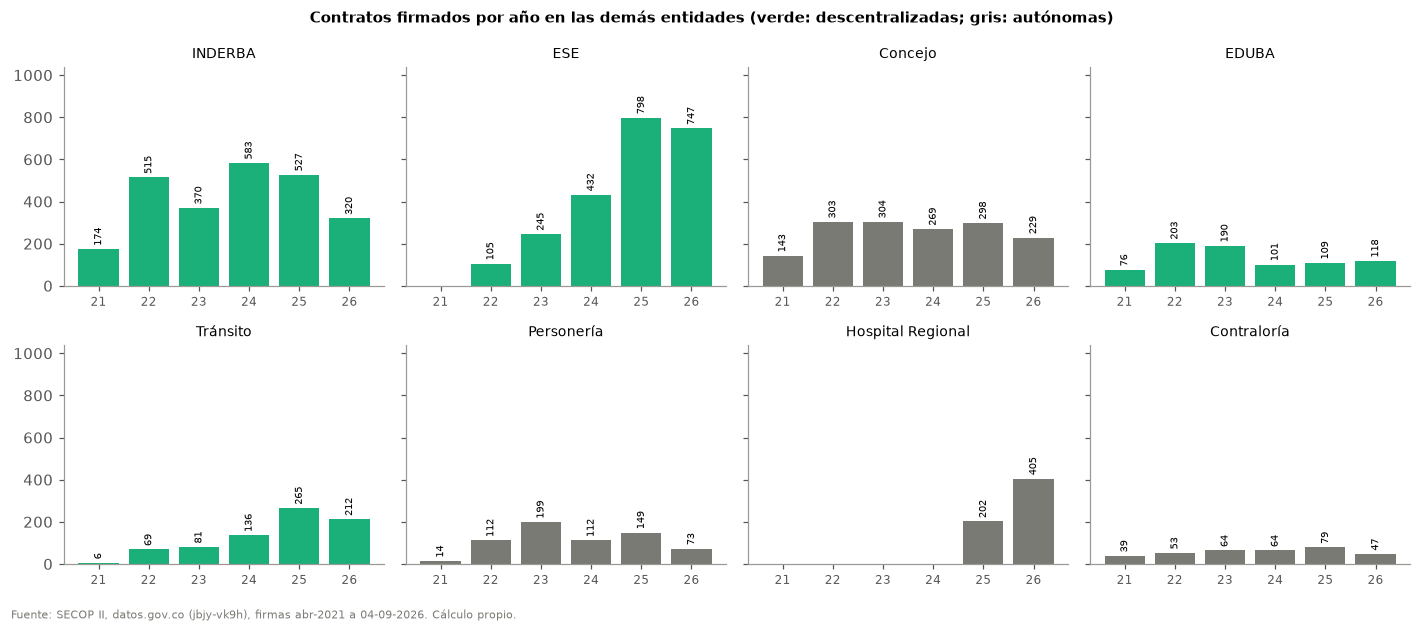

#### P13 · ¿Cómo contratan las otras entidades?

**Las otras entidades crecen en SECOP II.** INDERBA firmó entre 370 y 583 contratos por año completo; el Concejo, entre 269 y 304. La ESE pasó de 105 contratos en 2022 a 798 en 2025, y el Hospital Regional aparece solo desde 2025. Esos saltos pueden reflejar, al menos en parte, que las entidades empezaron a publicar en SECOP II; no se puede leer como más contratación sin revisar SECOP I.

**Qué no significa:** No se suman al alcalde las entidades autónomas. Los cambios de publicación impiden comparar gobiernos en estas entidades.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Cobertura de SECOP II distinta por entidad y año.

In [39]:
t_p13 = pd.crosstab([todas["grupo_atribucion"], todas["entidad"]], todas["anio"]).reset_index()
ents = t_p13.set_index("entidad")
grupo_ent = ents.pop("grupo_atribucion")
ents.columns = [int(c) for c in ents.columns]
ents = ents.astype(float).drop(index=[e for e in ents.index if "Alcaldía" in e])
ents = ents.loc[ents.sum(axis=1).sort_values(ascending=False).index]
fig, axs = plt.subplots(2, 4, figsize=(13, 5.5), sharey=True)
for axk, (ent, row) in zip(axs.flat, ents.iterrows()):
    axk.bar(range(len(row)), row.values, color=GRIS if grupo_ent[ent] == "No atribuible al alcalde" else VERDE)
    for x, v in enumerate(row.values):
        if v > 0:
            axk.text(x, v + ents.values.max() * 0.02, f"{int(v):,}", ha="center", va="bottom", fontsize=6.5, rotation=90)
    axk.set_xticks(range(len(row)), [str(a)[2:] for a in row.index], fontsize=8)
    axk.set_title(CORTO[ent], fontsize=9)
axs.flat[0].set_ylim(0, ents.values.max() * 1.3)
fig.suptitle("Contratos firmados por año en las demás entidades (verde: descentralizadas; gris: autónomas)", fontsize=10, fontweight="bold")
g_p13 = guardar_fig(fig, "a4_otras_entidades.png")
insight("P13", "Acto 4 · Varias puertas", "¿Cómo contratan las otras entidades?",
        "Las otras entidades crecen en SECOP II",
        f"INDERBA firmó entre {int(ents.loc['INDERBA (deporte y recreación)', ANIOS_COMPLETOS].min())} y "
        f"{int(ents.loc['INDERBA (deporte y recreación)', ANIOS_COMPLETOS].max())} contratos por año completo; el Concejo, entre "
        f"{int(ents.loc['Concejo de Barrancabermeja', ANIOS_COMPLETOS].min())} y {int(ents.loc['Concejo de Barrancabermeja', ANIOS_COMPLETOS].max())}. "
        f"La ESE pasó de {int(ents.loc['ESE Barrancabermeja', 2022])} contratos en 2022 a {int(ents.loc['ESE Barrancabermeja', 2025])} en 2025, y el "
        f"Hospital Regional aparece solo desde 2025. Esos saltos pueden reflejar, al menos en parte, que las entidades empezaron a publicar en "
        f"SECOP II; no se puede leer como más contratación sin revisar SECOP I.",
        "No se suman al alcalde las entidades autónomas. Los cambios de publicación impiden comparar gobiernos en estas entidades.",
        "Dato descriptivo", "PUBLICABLE_CON_CAUTELA", "Contratos válidos de las nueve entidades",
        "Cobertura de SECOP II distinta por entidad y año.", t_p13, g_p13,
        cifra=f"ESE: {int(ents.loc['ESE Barrancabermeja', 2022])} (2022) → {int(ents.loc['ESE Barrancabermeja', 2025])} (2025) contratos")

# 5 El reloj político
## P14  El calendario de firmas: pocos días concentran la contratación
Mapa de calor de CPS firmados por año y mes, días de mayor firma y firmas en fin de semana.

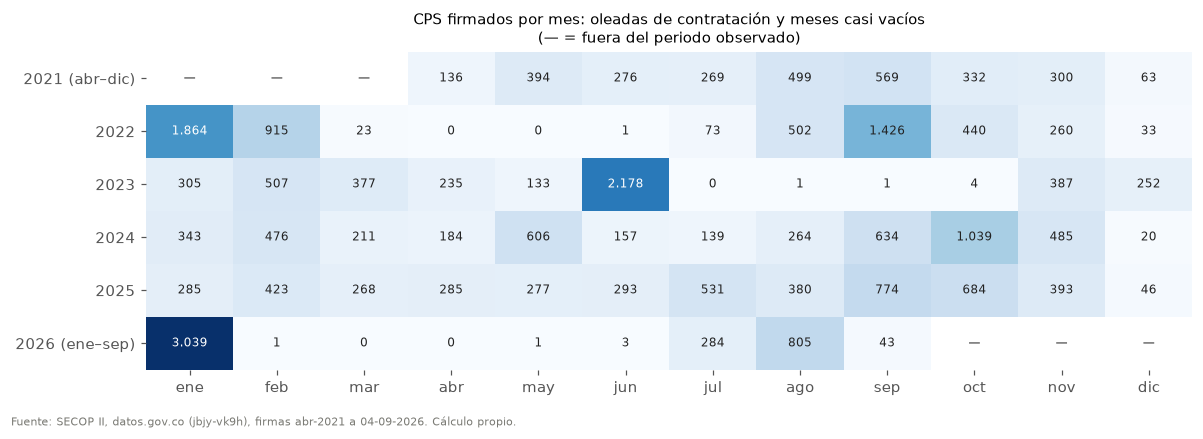

#### P14 · ¿Cuándo se firman los contratos?

**La contratación llega en oleadas y en pocos días.** Los CPS se firman en tandas. Según el año, los 10 días con más firmas concentraron entre 16 % y 42 % de todos los CPS del año. El día de más firmas fue el 2 de febrero de 2022 (miércoles), con 541 CPS. Hay tandas en fin de semana: 206 CPS en sábados y domingos de enero de 2022; 336 CPS en sábados y domingos de junio de 2023; 625 CPS en sábados y domingos de enero de 2026. Y hay meses casi vacíos: en los meses calendario de julio a octubre de 2023 se firmaron 6 CPS en total.

**Qué no significa:** Firmar en tanda no es ilegal ni prueba de nada: puede reflejar la planeación del año o la llegada de recursos. La fecha registrada en SECOP II puede no coincidir con la de suscripción del documento.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Fecha de firma registrada en SECOP II; no se verificó contra el documento físico.

,fecha_firma,cps,anio,dia_semana
0,2022-02-02,541,2022,miércoles
1,2023-06-26,319,2023,lunes
2,2023-06-27,316,2023,martes
3,2023-06-28,285,2023,miércoles
4,2022-01-26,273,2022,miércoles
5,2022-02-03,258,2022,jueves
6,2023-06-24,232,2023,sábado
7,2026-01-23,214,2026,viernes
8,2026-01-17,209,2026,sábado
9,2022-01-27,207,2022,jueves


,fecha_firma,cps,anio,dia_semana
152,2021-11-27,1,2021,sábado
165,2022-01-15,5,2022,sábado
171,2022-01-22,191,2022,sábado
172,2022-01-23,10,2022,domingo
248,2022-10-01,1,2022,sábado
289,2022-12-03,1,2022,sábado
337,2023-03-11,10,2023,sábado
391,2023-06-10,31,2023,sábado
397,2023-06-17,72,2023,sábado
403,2023-06-24,232,2023,sábado


In [18]:
cps["dia_semana"] = cps["fecha_firma"].dt.dayofweek
cps["finde"] = cps["dia_semana"].ge(5)
calor = pd.crosstab(cps["anio"], cps["fecha_firma"].dt.month).reindex(columns=range(1, 13), fill_value=0)
fuera = pd.DataFrame(False, index=calor.index, columns=calor.columns)  # meses fuera del periodo observado
fuera.loc[INICIO.year, [m for m in calor.columns if m < INICIO.month]] = True
fuera.loc[CORTE.year, [m for m in calor.columns if m > CORTE.month]] = True
por_dia = cps.groupby("fecha_firma").size().rename("cps").reset_index()
por_dia["anio"] = por_dia["fecha_firma"].dt.year
por_dia["dia_semana"] = por_dia["fecha_firma"].dt.dayofweek.map(dict(enumerate(DIAS_ES)))
top10 = (por_dia.sort_values(["anio", "cps", "fecha_firma"], ascending=[True, False, True]).groupby("anio").head(10)
         .groupby("anio")["cps"].sum())
t03 = cps.groupby("anio").agg(cps=("id_contrato", "size"), dias_con_firma=("fecha_firma", "nunique"),
                              firmas_fin_de_semana=("finde", "sum")).reset_index()
t03["pct_en_10_dias_mayores"] = t03["anio"].map(top10) / t03["cps"] * 100
t03["pct_fin_de_semana"] = t03["firmas_fin_de_semana"] / t03["cps"] * 100
dias_top = por_dia.sort_values(["cps", "fecha_firma"], ascending=[False, True]).head(15).reset_index(drop=True)
finde_top = por_dia.loc[por_dia["fecha_firma"].dt.dayofweek.ge(5)].sort_values("fecha_firma")  # todas las firmas en fin de semana

fig, ax = plt.subplots(figsize=(11, 3.8))
im = ax.imshow(calor.mask(fuera).values.astype(float), cmap="Blues", aspect="auto")
ax.set_xticks(range(12), MESES_ES)
ax.set_yticks(range(len(calor)), [rotulo_anio(a).replace("\n", " ") for a in calor.index])
for i in range(calor.shape[0]):
    for j in range(12):
        v = calor.values[i, j]
        ax.text(j, i, "—" if fuera.values[i, j] else f"{v:,}".replace(",", "."), ha="center", va="center", fontsize=8,
                color="white" if v > calor.values.max() * 0.55 else "#222222")
ax.set_title("CPS firmados por mes: oleadas de contratación y meses casi vacíos\n(— = fuera del periodo observado)", fontsize=10)
for s in ax.spines.values():
    s.set_visible(False)
g73 = guardar_fig(fig, "a5_calendario_firmas.png")

a_max = t03.loc[t03["pct_en_10_dias_mayores"].idxmax()]
fdc = finde_top.groupby(finde_top["fecha_firma"].dt.to_period("M"))["cps"].sum()
fdc_grandes = fdc[fdc.ge(100)]
vacios = [(p, int(calor.loc[p.year, p.month])) for p in pd.period_range("2023-07", "2023-10", freq="M")]
insight("P14", "Acto 5 · El reloj político", "¿Cuándo se firman los contratos?", "La contratación llega en oleadas y en pocos días",
        f"Los CPS se firman en tandas. Según el año, los 10 días con más firmas concentraron entre "
        f"{t03['pct_en_10_dias_mayores'].min():.0f} % y {t03['pct_en_10_dias_mayores'].max():.0f} % de todos los CPS del año. "
        f"El día de más firmas fue el {fecha_es(dias_top.loc[0, 'fecha_firma'])} ({dias_top.loc[0, 'dia_semana']}), con "
        f"{dias_top.loc[0, 'cps']:,} CPS. Hay tandas en fin de semana: "
        + "; ".join(f"{v:,} CPS en sábados y domingos de {MESES_LARGOS[p.month - 1]} de {p.year}" for p, v in fdc_grandes.items())
        + f". Y hay meses casi vacíos: en los meses calendario de julio a octubre de 2023 se firmaron {sum(v for _, v in vacios)} CPS en total.",
        "Firmar en tanda no es ilegal ni prueba de nada: puede reflejar la planeación del año o la llegada de recursos. "
        "La fecha registrada en SECOP II puede no coincidir con la de suscripción del documento.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "CPS de personas naturales, Alcaldía central",
        "Fecha de firma registrada en SECOP II; no se verificó contra el documento físico.",
        t03.merge(calor.add_prefix("mes_").reset_index(), on="anio"), g73,
        cifra=f"{t03['pct_en_10_dias_mayores'].min():.0f}–{t03['pct_en_10_dias_mayores'].max():.0f} % de los CPS del año en 10 días")
display(dias_top)
finde_top

## P15, P18  El calendario electoral y la contratación
La Ley de Garantías (Ley 996 de 2005) prohíbe la contratación directa en los cuatro meses previos a la elección
presidencial (art. 33) y restringe a alcaldes antes de cualquier elección (art. 38: convenios interadministrativos y nómina).
Según Colombia Compra Eficiente (Circular 006), la prohibición no cobija prórrogas ni adiciones de contratos vigentes.

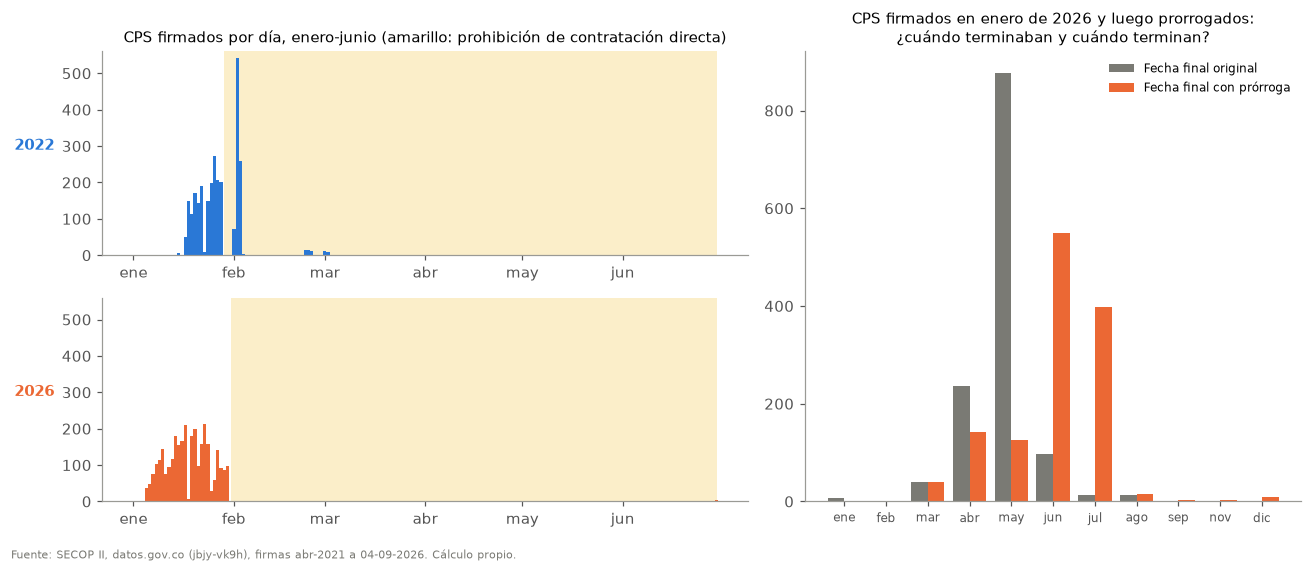

#### P15 · ¿Qué pasó con la contratación antes de la Ley de Garantías de 2026?

**2026: contratar antes de la veda y luego prorrogar.** Entre el 1 de enero y el 30 de enero de 2026 la Alcaldía firmó 3.039 CPS; 1.135 de ellos en los 10 días previos a la prohibición, 189 en sábado o domingo. Durante la prohibición (31 de enero de 2026 a 21 de junio de 2026) SECOP registra 2 CPS. El 42 % de los CPS de enero se prorrogó: el 98 % de esos contratos terminaba antes del fin de la veda y, con la prórroga, el 75 % quedó terminando en la última quincena de la veda o después. Según Colombia Compra Eficiente (Circular 006), la prohibición no cobija las prórrogas y adiciones de contratos vigentes.

**Qué no significa:** No prueba una irregularidad. Si alguna prórroga se usó para eludir la restricción, solo lo muestran los expedientes. El dato muestra que el ritmo de firmas coincide con el calendario electoral, no por qué.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* La fecha final original se estima restando los días adicionados; los contratos de 2026 siguen en ejecución.

#### P16 · ¿Se firmaron CPS durante los periodos de prohibición de la Ley de Garantías?

**CPS con fecha de firma dentro de los periodos de prohibición.** El artículo 33 de la Ley 996 de 2005 prohíbe la contratación directa en los cuatro meses previos a la elección presidencial. Con fecha de firma entre el 29 de enero de 2022 y el 19 de junio de 2022, SECOP II registra 938 CPS de la Alcaldía central: 874 en la primera semana y 24 después del primer mes. En el periodo equivalente de 2026 (31 de enero de 2026 a 21 de junio de 2026) registra 2. El cuaderno 05 cuenta 939 y 2 (incluye CPS sin identidad apta).

**Qué no significa:** No es una conclusión legal. La ley exceptúa, entre otros, lo relacionado con defensa y seguridad del Estado, crédito público, emergencias educativas, sanitarias y desastres, y la contratación de entidades sanitarias y hospitalarias; además, la fecha de firma de SECOP II puede no ser la de suscripción. Si hubo infracción solo lo dicen los expedientes.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Conteo por fecha de firma registrada; la legalidad de cada contrato requiere su expediente.

#### P17 · ¿Qué pasó antes de las elecciones locales de 2023?

**Junio de 2023: la tanda antes de las elecciones locales.** En los 30 días previos al 29 de junio de 2023 (inicio de las restricciones territoriales por las elecciones del 29 de octubre de 2023) la Alcaldía firmó 2.187 CPS (en las mismas fechas de 2024 y 2025, 324 en promedio), 336 de ellos en sábado o domingo. Su duración mediana fue de 5,0 meses y el 48 % termina en diciembre de 2023, el último mes del gobierno. Las personas con CPS vigente pasaron de 1.178 un mes antes a 2.737 el 28 de julio de 2023 (P07). Durante las restricciones territoriales (29 de junio de 2023 a 29 de octubre de 2023) se firmaron apenas 5 CPS, aunque esas restricciones no prohíben contratar CPS.

**Qué no significa:** Las restricciones territoriales no prohíben contratar CPS; no hay base para afirmar uso electoral. Es una coincidencia de calendario que merece explicación de la administración.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Sin expedientes no se conoce el motivo de la tanda (presupuesto, proyectos, vigencias).

#### P18 · ¿Se firmaron contratos interadministrativos durante la restricción de 2025–2026?

**Contratos interadministrativos con fecha de firma dentro de la restricción del artículo 38.** El parágrafo del artículo 38 de la Ley 996 prohíbe a los alcaldes celebrar convenios interadministrativos para ejecutar recursos en los cuatro meses previos a las elecciones; en este ciclo, del 8 de noviembre de 2025 al 21 de junio de 2026. Con fecha de firma en ese periodo, SECOP II registra 6 contratos o convenios interadministrativos de la Alcaldía central (del 26 de diciembre de 2025 al 30 de enero de 2026), por 15,5 miles de millones de pesos corrientes. Después de la restricción y hasta el corte se firmaron 5 más.

**Qué no significa:** No es una conclusión legal: la prohibición recae sobre convenios que ejecutan recursos, hay discusión jurídica sobre los contratos interadministrativos y la categoría de SECOP II no basta para clasificarlos. Solo el expediente lo aclara.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Conteo por fecha de firma registrada; requiere expediente y concepto jurídico de cada contrato.

,periodo,inicio_restriccion,fin_restriccion,cps_1ene_a_inicio,cps_10_dias_previos,cps_10_dias_previos_fin_de_semana,cps_dentro_restriccion,pct_previos_con_prorroga
0,presidencial_2022,2022-01-29,2022-06-19,1864,1660,201,938,0.214592
1,presidencial_2026,2026-01-31,2026-06-21,3039,1135,189,2,42.283646


In [19]:
def ventana_anual(anio, inicio_restr):
    # CPS firmados entre el 1-ene y el 30-jun, antes y dentro de la restricción
    d = cps.loc[cps["fecha_firma"].between(f"{anio}-01-01", f"{anio}-06-30")].copy()
    d["antes"] = d["fecha_firma"].lt(inicio_restr)
    return d


pres = restr.loc[restr["norma"].eq("Art. 33")].set_index("periodo")
filas = []
for periodo, r in pres.iterrows():
    a = r["fecha_inicio"].year
    d = ventana_anual(a, r["fecha_inicio"])
    antes = d.loc[d["antes"]]
    dentro = cps.loc[cps["fecha_firma"].between(r["fecha_inicio"], r["fecha_fin"])]
    ult10 = antes.loc[antes["fecha_firma"].ge(r["fecha_inicio"] - pd.Timedelta(days=10))]
    filas.append({"periodo": periodo, "inicio_restriccion": r["fecha_inicio"], "fin_restriccion": r["fecha_fin"],
                  "cps_1ene_a_inicio": len(antes), "cps_10_dias_previos": len(ult10),
                  "cps_10_dias_previos_fin_de_semana": int(ult10["finde"].sum()),
                  "cps_dentro_restriccion": len(dentro),
                  "pct_previos_con_prorroga": antes["flag_dias_adicionados"].mean() * 100 if len(antes) else np.nan})
t04 = pd.DataFrame(filas)

# Contratos de enero del año de restricción de 2026: fecha final original (sin días adicionados) vs final
p26 = pres.loc["presidencial_2026"]
ene26 = cps.loc[cps["fecha_firma"].between(f"{p26['fecha_inicio'].year}-01-01", p26["fecha_inicio"] - pd.Timedelta(days=1))].copy()
ene26["fin_original"] = ene26["fecha_fin"] - pd.to_timedelta(ene26["dias_adicionados"].fillna(0), unit="D")
ext = ene26.loc[ene26["flag_dias_adicionados"]]
t04b = pd.DataFrame({"fin_original": ext["fin_original"].dt.to_period("M").value_counts(),
                     "fin_con_prorroga": ext["fecha_fin"].dt.to_period("M").value_counts()}).fillna(0).astype(int).sort_index()
t04b.index = t04b.index.astype(str)
pct_ext_despues = float(ext["fecha_fin"].gt(p26["fecha_fin"] - pd.Timedelta(days=15)).mean() * 100)
pct_orig_antes = float(ext["fin_original"].lt(p26["fecha_fin"]).mean() * 100)

t04b = t04b.loc[t04b.index >= f"{p26['fecha_inicio'].year}-01"]  # meses del año de la veda
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(2, 2, width_ratios=[1.3, 1])
for k, (periodo, color) in enumerate([("presidencial_2022", AZUL), ("presidencial_2026", NARANJA)]):
    r = pres.loc[periodo]
    a = r["fecha_inicio"].year
    cal = pd.date_range(f"{a}-01-01", f"{a}-06-30")
    d = por_dia.set_index("fecha_firma")["cps"].reindex(cal, fill_value=0)
    axk = fig.add_subplot(gs[k, 0])
    axk.bar(d.index, d.values, width=1, color=color)
    axk.axvspan(r["fecha_inicio"], cal[-1], color="#f2c94c", alpha=0.3, lw=0, zorder=0)
    axk.set_ylabel(f"{a}", rotation=0, labelpad=18, fontweight="bold", color=color)
    axk.set_ylim(0, 560)
    axk.set_xticks(pd.date_range(f"{a}-01-01", periods=6, freq="MS"), MESES_ES[:6])
    if k == 0:
        axk.set_title("CPS firmados por día, enero-junio (amarillo: prohibición de contratación directa)", fontsize=10)
ax1 = fig.add_subplot(gs[:, 1])
xx = np.arange(len(t04b))
ax1.bar(xx - 0.2, t04b["fin_original"], width=0.4, color=GRIS, label="Fecha final original")
ax1.bar(xx + 0.2, t04b["fin_con_prorroga"], width=0.4, color=NARANJA, label="Fecha final con prórroga")
ax1.set_xticks(xx, [f"{MESES_ES[int(m[5:]) - 1]}" for m in t04b.index], fontsize=8)
ax1.set_title(f"CPS firmados en enero de {p26['fecha_inicio'].year} y luego prorrogados:\n¿cuándo terminaban y cuándo terminan?", fontsize=10)
ax1.legend(frameon=False, fontsize=8)
g74 = guardar_fig(fig, "a5_ley_garantias_2022_2026.png")

f22, f26 = t04.set_index("periodo").loc["presidencial_2022"], t04.set_index("periodo").loc["presidencial_2026"]
insight("P15", "Acto 5 · El reloj político", "¿Qué pasó con la contratación antes de la Ley de Garantías de 2026?", f"{p26['fecha_inicio'].year}: contratar antes de la veda y luego prorrogar",
        f"Entre el 1 de enero y el {fecha_es(p26['fecha_inicio'] - pd.Timedelta(days=1))} la Alcaldía firmó {int(f26['cps_1ene_a_inicio']):,} CPS; "
        f"{int(f26['cps_10_dias_previos']):,} de ellos en los 10 días previos a la prohibición, {int(f26['cps_10_dias_previos_fin_de_semana']):,} "
        f"en sábado o domingo. Durante la prohibición ({fecha_es(p26['fecha_inicio'])} a {fecha_es(p26['fecha_fin'])}) SECOP registra "
        f"{int(f26['cps_dentro_restriccion'])} CPS. El {f26['pct_previos_con_prorroga']:.0f} % de los CPS de enero se prorrogó: el "
        f"{pct_orig_antes:.0f} % de esos contratos terminaba antes del fin de la veda y, con la prórroga, el {pct_ext_despues:.0f} % "
        f"quedó terminando en la última quincena de la veda o después. Según Colombia Compra Eficiente (Circular 006), la prohibición no "
        f"cobija las prórrogas y adiciones de contratos vigentes.",
        "No prueba una irregularidad. Si alguna prórroga se usó para eludir la restricción, solo lo muestran los expedientes. El dato "
        "muestra que el ritmo de firmas coincide con el calendario electoral, no por qué.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "CPS de personas naturales, Alcaldía central",
        "La fecha final original se estima restando los días adicionados; los contratos de 2026 siguen en ejecución.",
        t04.merge(t04b.reset_index().rename(columns={"index": "mes"}).assign(periodo="presidencial_2026"), on="periodo", how="outer"), g74,
        cifra=f"{int(f26['cps_1ene_a_inicio']):,} CPS antes de la veda; {f26['pct_previos_con_prorroga']:.0f} % prorrogados")

p22 = pres.loc["presidencial_2022"]
dentro22 = cps.loc[cps["fecha_firma"].between(p22["fecha_inicio"], p22["fecha_fin"])]
sem1 = int(dentro22["fecha_firma"].lt(p22["fecha_inicio"] + pd.Timedelta(days=7)).sum())
tras_mes = int(dentro22["fecha_firma"].ge(p22["fecha_inicio"] + pd.DateOffset(months=1)).sum())
lg05 = su.leer_csv(r05["ley_garantias"])
cps05 = lg05.loc[lg05["grupo_atribucion"].eq("Administración central")].set_index("periodo")["de_ellos_cps"]
insight("P16", "Acto 5 · El reloj político", "¿Se firmaron CPS durante los periodos de prohibición de la Ley de Garantías?",
        "CPS con fecha de firma dentro de los periodos de prohibición",
        f"El artículo 33 de la Ley 996 de 2005 prohíbe la contratación directa en los cuatro meses previos a la elección presidencial. "
        f"Con fecha de firma entre el {fecha_es(f22['inicio_restriccion'])} y el {fecha_es(f22['fin_restriccion'])}, SECOP II registra "
        f"{int(f22['cps_dentro_restriccion']):,} CPS de la Alcaldía central: {sem1:,} en la primera semana y {tras_mes:,} después del primer mes. "
        f"En el periodo equivalente de {p26['fecha_inicio'].year} ({fecha_es(f26['inicio_restriccion'])} a {fecha_es(f26['fin_restriccion'])}) registra "
        f"{int(f26['cps_dentro_restriccion'])}. El cuaderno 05 cuenta {int(cps05.get('presidencial_2022', 0)):,} y {int(cps05.get('presidencial_2026', 0)):,} "
        f"(incluye CPS sin identidad apta).",
        "No es una conclusión legal. La ley exceptúa, entre otros, lo relacionado con defensa y seguridad del Estado, crédito público, "
        "emergencias educativas, sanitarias y desastres, y la contratación de entidades sanitarias y hospitalarias; además, la fecha de firma "
        "de SECOP II puede no ser la de suscripción. Si hubo infracción solo lo dicen los expedientes.",
        "Dato descriptivo", "PUBLICABLE_CON_CAUTELA", "CPS de personas naturales, Alcaldía central",
        "Conteo por fecha de firma registrada; la legalidad de cada contrato requiere su expediente.", t04,
        cifra=f"{int(f22['cps_dentro_restriccion']):,} CPS en 2022 y {int(f26['cps_dentro_restriccion'])} en {p26['fecha_inicio'].year} con firma en la prohibición")

# Junio de 2023: tanda antes de las restricciones territoriales
t23 = restr.set_index("periodo").loc["territorial_2023"]
jun23 = cps.loc[cps["fecha_firma"].between(t23["fecha_inicio"] - pd.Timedelta(days=30), t23["fecha_inicio"] - pd.Timedelta(days=1))]
t04c = pd.DataFrame([{"ventana": f"30 días antes de {t23['fecha_inicio'].date()}", "cps": len(jun23),
                      "firmados_fin_de_semana": int(jun23["finde"].sum()),
                      "mediana_duracion_meses": jun23["duracion_dias_incl"].median() / 30.4375,
                      "pct_terminan_en_dic_2023": jun23["fecha_fin"].dt.to_period("M").eq(pd.Period("2023-12")).mean() * 100,
                      "pct_terminan_despues_elecciones": jun23["fecha_fin"].gt(t23["fecha_fin"]).mean() * 100,
                      "cps_mismas_fechas_promedio_2024_2025": np.mean([int(cps["fecha_firma"].between(
                          t23["fecha_inicio"] - pd.Timedelta(days=30) + pd.DateOffset(years=k),
                          t23["fecha_inicio"] - pd.Timedelta(days=1) + pd.DateOffset(years=k)).sum()) for k in (1, 2)]),
                      "cps_durante_restriccion_territorial": int(cps["fecha_firma"].between(t23["fecha_inicio"], t23["fecha_fin"]).sum())}])
r = t04c.iloc[0]
_d = diario.set_index("fecha")["personas_con_cps"]
antes_tanda = int(_d.loc[t23["fecha_inicio"] - pd.Timedelta(days=31)])
_ventana_pico = _d.loc[t23["fecha_inicio"] - pd.Timedelta(days=30):t23["fecha_inicio"] + pd.Timedelta(days=60)]
pico_tanda, fecha_pico = int(_ventana_pico.max()), _ventana_pico.idxmax()
insight("P17", "Acto 5 · El reloj político", "¿Qué pasó antes de las elecciones locales de 2023?", "Junio de 2023: la tanda antes de las elecciones locales",
        f"En los 30 días previos al {fecha_es(t23['fecha_inicio'])} (inicio de las restricciones territoriales por las elecciones del "
        f"{fecha_es(t23['fecha_fin'])}) la Alcaldía firmó {int(r['cps']):,} CPS (en las mismas fechas de 2024 y 2025, "
        f"{r['cps_mismas_fechas_promedio_2024_2025']:,.0f} en promedio), "
        f"{int(r['firmados_fin_de_semana'])} de ellos en sábado o domingo. Su duración mediana fue de {r['mediana_duracion_meses']:.1f} meses y el "
        f"{r['pct_terminan_en_dic_2023']:.0f} % termina en diciembre de 2023, el último mes del gobierno. Las personas con CPS vigente pasaron "
        f"de {antes_tanda:,} un mes antes a {pico_tanda:,} el {fecha_es(fecha_pico)} (P07). Durante las restricciones territoriales "
        f"({fecha_es(t23['fecha_inicio'])} a {fecha_es(t23['fecha_fin'])}) se firmaron apenas {int(r['cps_durante_restriccion_territorial'])} CPS, "
        f"aunque esas restricciones no prohíben contratar CPS.",
        "Las restricciones territoriales no prohíben contratar CPS; no hay base para afirmar uso electoral. Es una coincidencia "
        "de calendario que merece explicación de la administración.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "CPS de personas naturales, Alcaldía central",
        "Sin expedientes no se conoce el motivo de la tanda (presupuesto, proyectos, vigencias).", t04c, g73,
        cifra=f"{int(r['cps']):,} CPS en 30 días; {r['pct_terminan_en_dic_2023']:.0f} % hasta dic-2023")

# Convenios y contratos interadministrativos durante la restricción del art. 38 (2025-2026)
jm = su.normalizar_texto(central["justificacion_modalidad"]).fillna("")
inter = central.loc[jm.str.contains("interadministrativ")].copy()
a38 = restr.set_index("periodo").loc["territorial_art38_2026"]
en38 = inter.loc[inter["fecha_firma"].between(a38["fecha_inicio"], a38["fecha_fin"])]
t04d = (inter.groupby("anio").agg(contratos=("id_contrato", "size"), valor_real=("valor_real", "sum")).reset_index()
        .assign(en_restriccion_art38=lambda d: d["anio"].map(en38.groupby("anio").size()).fillna(0).astype(int)))
su.guardar_csv(en38[["id_contrato", "fecha_firma", "nombre_proveedor", "valor_contrato", "descripcion_del_proceso", "url_secop"]]
               .sort_values("fecha_firma"), INTERNO / "interadministrativos_en_restriccion_art38.csv")
despues38 = inter.loc[inter["fecha_firma"].gt(a38["fecha_fin"]) & inter["fecha_firma"].le(CORTE)]
insight("P18", "Acto 5 · El reloj político", "¿Se firmaron contratos interadministrativos durante la restricción de 2025–2026?",
        "Contratos interadministrativos con fecha de firma dentro de la restricción del artículo 38",
        f"El parágrafo del artículo 38 de la Ley 996 prohíbe a los alcaldes celebrar convenios interadministrativos para ejecutar recursos en "
        f"los cuatro meses previos a las elecciones; en este ciclo, del {fecha_es(a38['fecha_inicio'])} al {fecha_es(a38['fecha_fin'])}. "
        f"Con fecha de firma en ese periodo, SECOP II registra {len(en38)} contratos o convenios interadministrativos de la Alcaldía central "
        f"(del {fecha_es(en38['fecha_firma'].min()) if len(en38) else '-'} al {fecha_es(en38['fecha_firma'].max()) if len(en38) else '-'}), "
        f"por {mm(en38['valor_contrato'].sum()):,.1f} miles de millones de pesos corrientes. Después de la restricción y hasta el corte se "
        f"firmaron {len(despues38)} más.",
        "No es una conclusión legal: la prohibición recae sobre convenios que ejecutan recursos, hay discusión jurídica sobre los contratos "
        "interadministrativos y la categoría de SECOP II no basta para clasificarlos. Solo el expediente lo aclara.",
        "Dato descriptivo", "PUBLICABLE_CON_CAUTELA", "Contratos válidos de la Alcaldía central con justificación interadministrativa",
        "Conteo por fecha de firma registrada; requiere expediente y concepto jurídico de cada contrato.", t04d,
        cifra=f"{len(en38)} contratos interadministrativos con firma dentro de la restricción del art. 38")
t04

## P19  El cambio de gobierno: ¿quién siguió?
Personas con CPS vigente en el último trimestre del gobierno anterior (oct–dic 2023) y su recontratación desde enero de 2024.

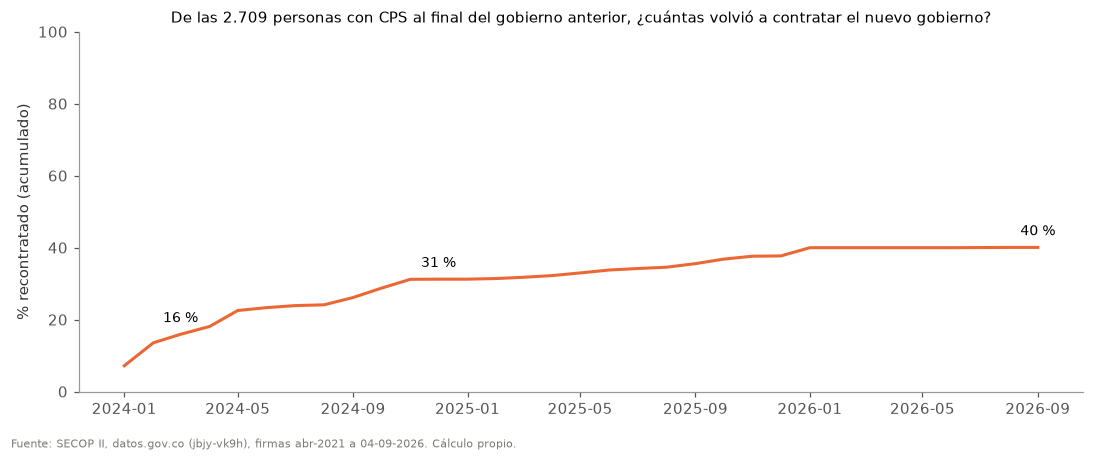

#### P19 · Con el cambio de gobierno, ¿quién siguió?

**El nuevo gobierno volvió a contratar a 4 de cada 10 contratistas del anterior.** Al final del gobierno anterior (oct–dic 2023) 2.709 personas tenían CPS vigente. El nuevo gobierno volvió a contratar al 40 % hasta el corte, pero solo al 16 % en el primer trimestre de 2024. Quienes regresaron pasaron una mediana de 160 días sin contrato. En 2024, el 44 % de las personas contratadas venía del gobierno anterior. En total, 1.579 personas tuvieron CPS con ambos gobiernos.

**Qué no significa:** No mide despidos (un CPS termina en su fecha) ni persecución o favoritismo: el nuevo gobierno puede tener otros programas y necesidades.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Solo ve la Alcaldía central: una persona pudo pasar a otra entidad.

,indicador,valor
0,Personas con CPS vigente en oct–dic 2023,2709.000000
1,"De ellas, recontratadas en el nuevo gobierno (...",1085.000000
2,% recontratadas hasta el corte,40.051680
3,% recontratadas en el primer trimestre de 2024,15.909930
4,Días sin contrato entre ambos gobiernos (media...,160.000000
5,Personas con CPS en 2024,2666.000000
6,% de las personas de 2024 que venían del gobie...,43.735934
7,Personas con CPS en el gobierno anterior (desd...,4986.000000
8,Personas con CPS en el gobierno actual (hasta ...,5256.000000
9,Personas con CPS en ambos gobiernos,1579.000000


In [20]:
antes = cpsi.loc[cpsi["fecha_firma"].lt(CAMBIO)]
despues = cpsi.loc[cpsi["fecha_firma"].ge(CAMBIO)]
t4 = antes.loc[antes["fecha_inicio"].lt(CAMBIO) & antes["fin_excl"].gt(CAMBIO - pd.DateOffset(months=3)), PERSONA].unique()
primera_firma_J = despues.groupby(PERSONA)["fecha_firma"].min()
primer_inicio_J = despues.groupby(PERSONA)["fecha_inicio"].min()
ultimo_fin_A = antes.groupby(PERSONA)["fin_excl"].max()
recon = primera_firma_J.reindex(t4).dropna()
espera = (primer_inicio_J.reindex(recon.index) - ultimo_fin_A.reindex(recon.index)).dt.days.clip(lower=0)
meses_obs = pd.period_range(CAMBIO, CORTE, freq="M")
curva = pd.DataFrame({"mes": meses_obs.astype(str),
                      "recontratados_acumulados": [int(recon.le(m.end_time).sum()) for m in meses_obs]})
curva["pct_de_activos_t4_2023"] = curva["recontratados_acumulados"] / len(t4) * 100

S = {a: set(cps.loc[cps["anio"].eq(a), PERSONA]) for a in sorted(cps["anio"].unique())}
personas_A, personas_J = set(cps.loc[cps["fecha_firma"].lt(CAMBIO), PERSONA]), set(cps.loc[cps["fecha_firma"].ge(CAMBIO), PERSONA])
t05 = pd.DataFrame([
    {"indicador": "Personas con CPS vigente en oct–dic 2023", "valor": len(t4)},
    {"indicador": "De ellas, recontratadas en el nuevo gobierno (hasta el corte)", "valor": len(recon)},
    {"indicador": "% recontratadas hasta el corte", "valor": len(recon) / len(t4) * 100},
    {"indicador": "% recontratadas en el primer trimestre de 2024", "valor": float(curva.loc[2, "pct_de_activos_t4_2023"])},
    {"indicador": "Días sin contrato entre ambos gobiernos (mediana, recontratadas)", "valor": float(espera.median())},
    {"indicador": f"Personas con CPS en {CAMBIO.year}", "valor": len(S[CAMBIO.year])},
    {"indicador": f"% de las personas de {CAMBIO.year} que venían del gobierno anterior", "valor": len(S[CAMBIO.year] & personas_A) / len(S[CAMBIO.year]) * 100},
    {"indicador": "Personas con CPS en el gobierno anterior (desde abr-2021)", "valor": len(personas_A)},
    {"indicador": "Personas con CPS en el gobierno actual (hasta el corte)", "valor": len(personas_J)},
    {"indicador": "Personas con CPS en ambos gobiernos", "valor": len(personas_A & personas_J)},
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pd.PeriodIndex(curva["mes"], freq="M").to_timestamp(), curva["pct_de_activos_t4_2023"], color=NARANJA, lw=2)
ax.set_ylim(0, 100)
ax.set_ylabel("% recontratado (acumulado)")
ax.set_title(es(f"De las {len(t4):,} personas con CPS al final del gobierno anterior, ¿cuántas volvió a contratar el nuevo gobierno?"), fontsize=10)
for m in [2, 11, len(curva) - 1]:
    ax.annotate(f"{curva.loc[m, 'pct_de_activos_t4_2023']:.0f} %", (pd.Period(curva.loc[m, 'mes']).to_timestamp(), curva.loc[m, "pct_de_activos_t4_2023"]),
                xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
g75 = guardar_fig(fig, "a5_cambio_de_gobierno.png")

v = t05.set_index("indicador")["valor"]
pct_recon = len(recon) / len(t4) * 100
insight("P19", "Acto 5 · El reloj político", "Con el cambio de gobierno, ¿quién siguió?",
        f"El nuevo gobierno volvió a contratar a {pct_recon / 10:.0f} de cada 10 contratistas del anterior",
        f"Al final del gobierno anterior (oct–dic 2023) {len(t4):,} personas tenían CPS vigente. El nuevo gobierno volvió a contratar "
        f"al {len(recon) / len(t4) * 100:.0f} % hasta el corte, pero solo al {curva.loc[2, 'pct_de_activos_t4_2023']:.0f} % en el primer trimestre "
        f"de 2024. Quienes regresaron pasaron una mediana de {espera.median():.0f} días sin contrato. En {CAMBIO.year}, el "
        f"{len(S[CAMBIO.year] & personas_A) / len(S[CAMBIO.year]) * 100:.0f} % de las personas contratadas venía del gobierno anterior. "
        f"En total, {len(personas_A & personas_J):,} personas tuvieron CPS con ambos gobiernos.",
        "No mide despidos (un CPS termina en su fecha) ni persecución o favoritismo: el nuevo gobierno puede tener otros "
        "programas y necesidades.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "CPS de personas naturales, Alcaldía central, vigencia 1–366 días",
        "Solo ve la Alcaldía central: una persona pudo pasar a otra entidad.", pd.concat([t05, curva.rename(columns={"mes": "indicador", "pct_de_activos_t4_2023": "valor"})[["indicador", "valor"]]]),
        g75, cifra=f"{len(recon) / len(t4) * 100:.0f} % recontratado; espera mediana {espera.median():.0f} días")
t05

## P20 Rotación: ¿cuántos son nuevos cada año y cuántos siguen?
"Nueva" se mide de dos formas: sin CPS el año anterior (misma ventana de comparación para todos los años) y primera vez desde
abril de 2021 (depende de cuántos años hay hacia atrás, por eso crece con el tiempo y no se compara entre años).

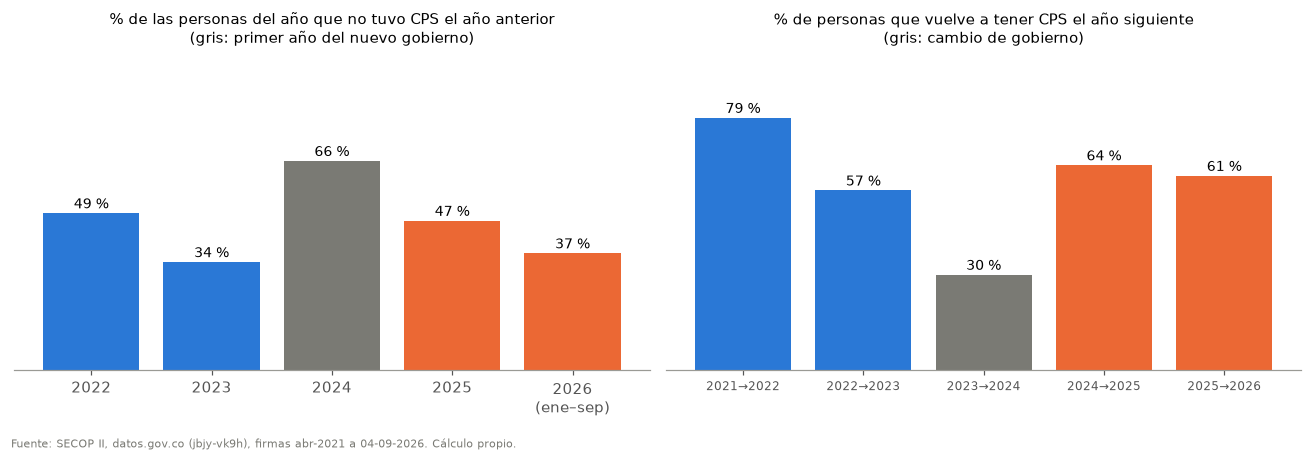

#### P20 · ¿Cuántos son nuevos cada año y cuántos siguen?

**Dentro de un gobierno la mayoría repite; en el cambio, la mayoría no.** Dentro de un mismo gobierno, entre el 57 % y el 79 % de las personas con CPS en un año vuelve a tener CPS al año siguiente. En el paso 2023→2024 repitió el 30 %. Visto desde el otro lado: en 2024 el 66 % de las personas contratadas no había tenido CPS el año anterior, frente a entre 34 % y 49 % en los demás años completos.

**Qué no significa:** Repetir no es favoritismo ni salir es despido. Quien no aparece pudo contratar con otra entidad o en SECOP I.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* 2021 empieza en abril y 2026 es parcial: el paso 2025→2026 es un mínimo.

,anio,personas,sin_cps_el_anio_anterior,pct_sin_cps_el_anio_anterior,primera_vez_desde_abr2021,pct_primera_vez_desde_abr2021,siguen_al_anio_siguiente_pct,tipo_paso
0,2021,2265,NaN,NaN,2265,100.0,79.3,mismo gobierno
1,2022,3548,1751.0,49.4,1751,49.4,56.5,mismo gobierno
2,2023,3038,1033.0,34.0,970,31.9,30.0,cambio de gobierno
3,2024,2666,1754.0,65.8,1500,56.3,64.4,mismo gobierno
4,2025,3241,1523.0,47.0,1228,37.9,61.1,mismo gobierno
5,2026,3133,1152.0,36.8,949,30.3,NaN,


In [21]:
visto, filas = set(), []
anios = sorted(S)
for a in anios:
    sig, ant = S.get(a + 1), S.get(a - 1)
    filas.append({"anio": a, "personas": len(S[a]),
                  "sin_cps_el_anio_anterior": len(S[a] - ant) if ant is not None else np.nan,
                  "pct_sin_cps_el_anio_anterior": len(S[a] - ant) / len(S[a]) * 100 if ant is not None else np.nan,
                  "primera_vez_desde_abr2021": len(S[a] - visto), "pct_primera_vez_desde_abr2021": len(S[a] - visto) / len(S[a]) * 100,
                  "siguen_al_anio_siguiente_pct": len(S[a] & sig) / len(S[a]) * 100 if sig is not None else np.nan,
                  "tipo_paso": ("cambio de gobierno" if a + 1 == CAMBIO.year else "mismo gobierno") if sig is not None else ""})
    visto |= S[a]
t06 = pd.DataFrame(filas)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
q = t06.dropna(subset=["pct_sin_cps_el_anio_anterior"])
ax[0].bar([rotulo_anio(a) for a in q["anio"]], q["pct_sin_cps_el_anio_anterior"],
          color=[GRIS if a == CAMBIO.year else color_anio(a) for a in q["anio"]])
for i, vv in enumerate(q["pct_sin_cps_el_anio_anterior"]):
    ax[0].text(i, vv + 1.5, f"{vv:.0f} %", ha="center", fontsize=9)
ax[0].set_ylim(0, 100)
ax[0].set_title("% de las personas del año que no tuvo CPS el año anterior\n(gris: primer año del nuevo gobierno)", fontsize=10)
p = t06.dropna(subset=["siguen_al_anio_siguiente_pct"])
ax[1].bar(np.arange(len(p)), p["siguen_al_anio_siguiente_pct"],
          color=[GRIS if t == "cambio de gobierno" else color_anio(a) for a, t in zip(p["anio"], p["tipo_paso"])])
ax[1].set_xticks(np.arange(len(p)), [f"{a}→{a + 1}" for a in p["anio"]], fontsize=8)
for i, vv in enumerate(p["siguen_al_anio_siguiente_pct"]):
    ax[1].text(i, vv + 1.5, f"{vv:.0f} %", ha="center", fontsize=9)
ax[1].set_ylim(0, 100)
ax[1].set_title("% de personas que vuelve a tener CPS el año siguiente\n(gris: cambio de gobierno)", fontsize=10)
for a_ in ax:
    a_.set_yticks([])
    a_.spines["left"].set_visible(False)
g76 = guardar_fig(fig, "a5_rotacion.png")

mismo = p.loc[p["tipo_paso"].eq("mismo gobierno"), "siguen_al_anio_siguiente_pct"]
cambio = float(p.loc[p["tipo_paso"].eq("cambio de gobierno"), "siguen_al_anio_siguiente_pct"].iloc[0])
t6 = t06.set_index("anio")
otros_nuevos = t6.loc[[a for a in ANIOS_COMPLETOS if a != CAMBIO.year], "pct_sin_cps_el_anio_anterior"]
insight("P20", "Acto 5 · El reloj político", "¿Cuántos son nuevos cada año y cuántos siguen?",
        "Dentro de un gobierno la mayoría repite; en el cambio, la mayoría no",
        f"Dentro de un mismo gobierno, entre el {mismo.min():.0f} % y el {mismo.max():.0f} % de las personas con CPS en un año vuelve a "
        f"tener CPS al año siguiente. En el paso {CAMBIO.year - 1}→{CAMBIO.year} repitió el {cambio:.0f} %. Visto desde el otro lado: en "
        f"{CAMBIO.year} el {t6.loc[CAMBIO.year, 'pct_sin_cps_el_anio_anterior']:.0f} % de las personas contratadas no había tenido CPS el año "
        f"anterior, frente a entre {otros_nuevos.min():.0f} % y {otros_nuevos.max():.0f} % en los demás años completos.",
        "Repetir no es favoritismo ni salir es despido. Quien no aparece pudo contratar con otra entidad o en SECOP I.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "CPS de personas naturales, Alcaldía central",
        f"2021 empieza en abril y {CORTE.year} es parcial: el paso {CORTE.year - 1}→{CORTE.year} es un mínimo.", t06, g76,
        cifra=f"{mismo.min():.0f}–{mismo.max():.0f} % repite dentro de un gobierno; {cambio:.0f} % en el cambio")
t06.round(1)

# 6 Más allá de las personas
## P21  ¿Qué dependencias contratan más CPS?
SECOP II no trae la dependencia en un campo propio: se extrae del objeto del contrato cuando lo menciona. La cobertura se reporta por año.

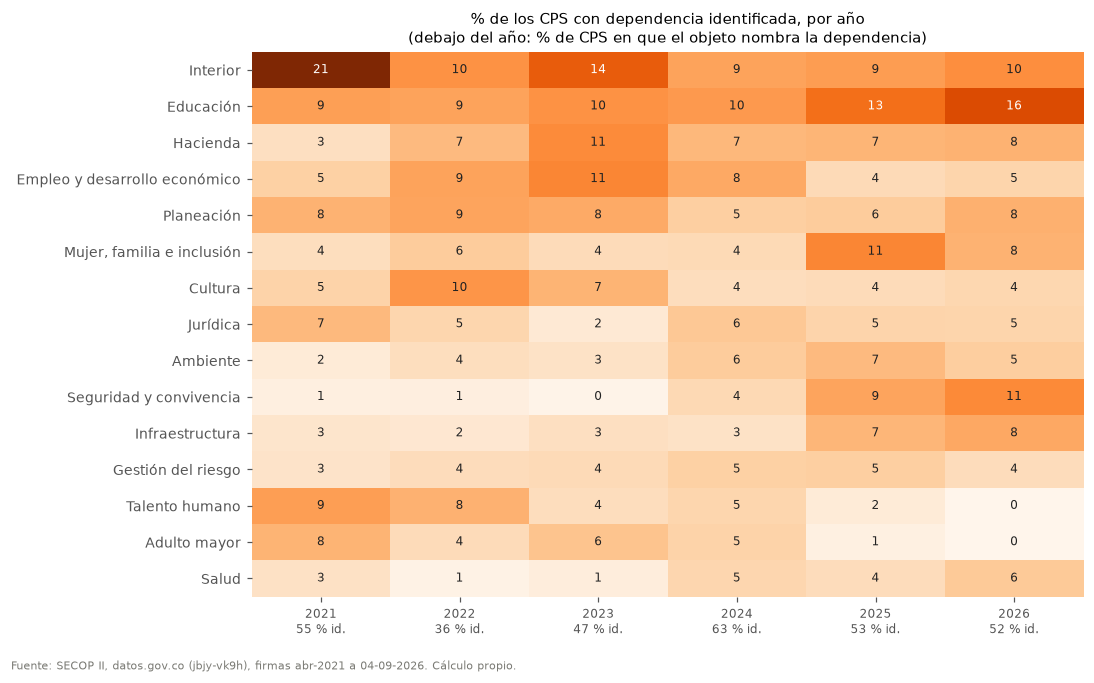

#### P21 · ¿Qué dependencias contratan más CPS?

**Qué dependencias contratan y cómo cambió.** Donde el objeto del contrato nombra la dependencia (36–63 % de los CPS según el año), las que más CPS concentran en el gobierno actual son Educación, Interior, Seguridad y convivencia. Frente al gobierno anterior, las que más ganaron participación son Seguridad y convivencia (+6,8 puntos) y Infraestructura (+3,2); las que más perdieron, Interior (-5,2) y Talento humano (-4,3). Algunas dependencias dejan de aparecer en 2026, lo que sugiere cambios de nombre o de estructura administrativa.

**Qué no significa:** Solo describe los contratos cuyo objeto nombra la dependencia; el resto no se asigna. No muestra el presupuesto de cada secretaría.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Extracción por texto; la cobertura cambia por año y puede sesgar las participaciones.

gobierno,Alfonso Eljach,Jonathan Vásquez,cambio_puntos
dependencia,,,
Educación,9.4,12.4,3.0
Interior,14.7,9.4,-5.2
Seguridad y convivencia,0.8,7.6,6.8
Hacienda,7.4,7.4,0.0
"Mujer, familia e inclusión",4.4,7.4,2.9
Planeación,8.2,6.1,-2.1
Infraestructura,2.9,6.0,3.2
Ambiente,2.9,6.0,3.1
Empleo y desarrollo económico,8.7,5.8,-2.8


In [22]:
t10 = pd.crosstab(cps["dependencia"], cps["anio"])
cobertura_dep = cps.groupby("anio")["dependencia"].apply(lambda s: s.notna().mean() * 100)
part = t10.div(t10.sum()).mul(100)
por_gob = pd.crosstab(cps["dependencia"], cps["gobierno"], normalize="columns").mul(100)
por_gob["cambio_puntos"] = por_gob[su.ADMINS[1]] - por_gob[su.ADMINS[0]]
por_gob = por_gob.sort_values(su.ADMINS[1], ascending=False)

top = t10.sum(axis=1).sort_values(ascending=False).index[:15]
fig, ax = plt.subplots(figsize=(10, 6))
mat = part.loc[top]
ax.imshow(mat.values, cmap="Oranges", aspect="auto")
ax.set_yticks(range(len(top)), top, fontsize=9)
ax.set_xticks(range(mat.shape[1]), [f"{a}\n{cobertura_dep[a]:.0f} % id." for a in mat.columns], fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat.values[i, j]:.0f}", ha="center", va="center", fontsize=8,
                color="white" if mat.values[i, j] > mat.values.max() * 0.6 else "#222222")
ax.set_title("% de los CPS con dependencia identificada, por año\n(debajo del año: % de CPS en que el objeto nombra la dependencia)", fontsize=10)
for s_ in ax.spines.values():
    s_.set_visible(False)
g80 = guardar_fig(fig, "a6_dependencias.png")

sube = por_gob.sort_values("cambio_puntos", ascending=False)
insight("P21", "Acto 6 · Más allá de las personas", "¿Qué dependencias contratan más CPS?", "Qué dependencias contratan y cómo cambió",
        f"Donde el objeto del contrato nombra la dependencia ({cobertura_dep.min():.0f}–{cobertura_dep.max():.0f} % de los CPS según el año), "
        f"las que más CPS concentran en el gobierno actual son {', '.join(por_gob.index[:3])}. Frente al gobierno anterior, las que más "
        f"ganaron participación son {sube.index[0]} (+{sube['cambio_puntos'].iloc[0]:.1f} puntos) y {sube.index[1]} "
        f"(+{sube['cambio_puntos'].iloc[1]:.1f}); las que más perdieron, {sube.index[-1]} ({sube['cambio_puntos'].iloc[-1]:.1f}) y "
        f"{sube.index[-2]} ({sube['cambio_puntos'].iloc[-2]:.1f}). Algunas dependencias dejan de aparecer en {CORTE.year}, lo que sugiere "
        f"cambios de nombre o de estructura administrativa.",
        "Solo describe los contratos cuyo objeto nombra la dependencia; el resto no se asigna. No muestra el presupuesto de cada secretaría.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "CPS de personas naturales, Alcaldía central, con dependencia en el objeto",
        "Extracción por texto; la cobertura cambia por año y puede sesgar las participaciones.",
        t10.reset_index().merge(por_gob.reset_index(), on="dependencia", how="left"), g80,
        cifra=f"cobertura {cobertura_dep.min():.0f}–{cobertura_dep.max():.0f} %")
por_gob.round(1)

## P22–P23 Obras, convenios y empresas

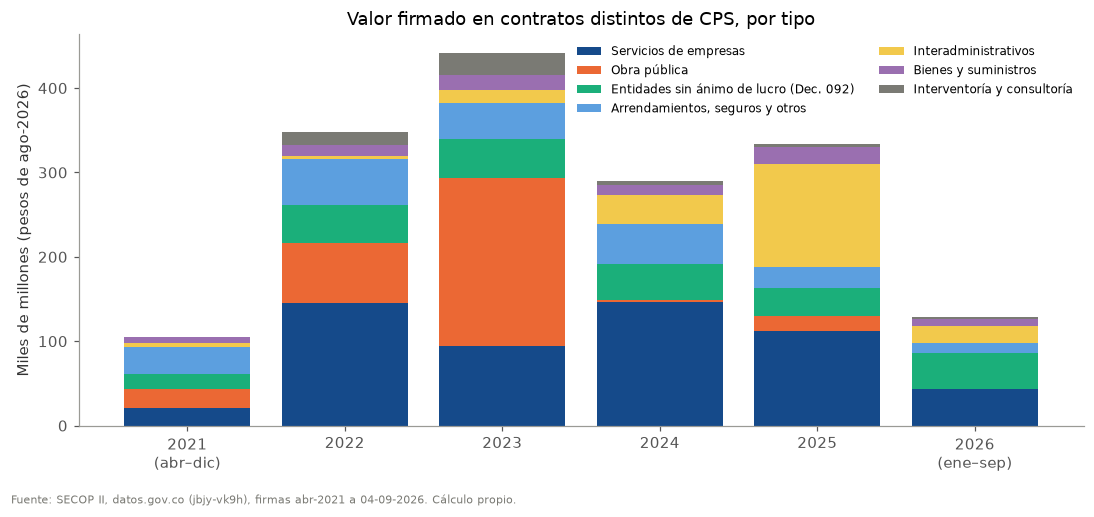

#### P22 · ¿En qué años se firma la obra pública?

**La obra pública se firmó sobre todo al final del gobierno anterior.** El valor firmado en contratos de obra fue de 71,5 miles de millones en 2022 y 198,4 en 2023, el último año del gobierno anterior; en 2024, primer año del nuevo gobierno, 3,2, y en 2025 18,2 (pesos constantes). La interventoría sigue el mismo ciclo. Coincide con lo que se espera del ciclo de un gobierno local (planear al comienzo, contratar obra al final), pero con un solo periodo por lado no se puede generalizar.

**Qué no significa:** No mide obra terminada ni pagada, y una sola licitación grande mueve el año. No indica uso electoral.

*Nivel:* Patrón estadístico · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* Valor firmado; un periodo de gobierno por lado (no permite generalizar). 2026 es parcial.

#### P23 · ¿Cómo contrata la Alcaldía lo que no son personas?

**Más contratación directa con entidades públicas.** En los contratos distintos de CPS, la contratación directa pesó 6 % del valor en 2022 y 11 % en 2023, y subió a 41 % en 2025. El aumento viene sobre todo de contratos y convenios interadministrativos (36 % del valor en 2025), firmados con entidades y empresas públicas. Entre las empresas y consorcios, los 10 proveedores con más valor reúnen el 39 % del total desde abril de 2021 y los consorcios o uniones temporales, el 34 %.

**Qué no significa:** Contratar directamente con otra entidad pública es legal. No se evalúa si cada contrato cumplió los requisitos.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE_CON_CAUTELA` · *Límite:* SECOP llama 'valor cero' a una categoría de interadministrativos que sí tiene valor; se usa la justificación registrada.

,anio,contratos,valor_real,pct_valor_directa,pct_valor_interadministrativos
0,2021,189.0,1.054901e+11,9.7,4.3
1,2022,310.0,3.480891e+11,6.3,1.0
2,2023,399.0,4.418170e+11,10.6,3.6
3,2024,286.0,2.899735e+11,21.8,12.0
4,2025,341.0,3.341958e+11,41.1,36.5
5,2026,216.0,1.290401e+11,23.2,15.5


In [23]:
nc = central.loc[~central["es_cps_estricto"]].copy()
tipo = su.normalizar_texto(nc["tipo_de_contrato"]).fillna("")
just = su.normalizar_texto(nc["justificacion_modalidad"]).fillna("")
nc["familia"] = np.select(
    [just.str.contains("interadministrativ"), tipo.eq("obra"), tipo.str.contains("interventoria|consultoria"),
     tipo.str.contains("decreto 092"), tipo.str.contains("prestacion de servicios"), tipo.str.contains("compraventa|suministro")],
    ["Interadministrativos", "Obra pública", "Interventoría y consultoría", "Entidades sin ánimo de lucro (Dec. 092)",
     "Servicios de empresas", "Bienes y suministros"], default="Arrendamientos, seguros y otros")
nc["directa"] = su.normalizar_texto(nc["modalidad_de_contratacion"]).fillna("").str.startswith("contratacion directa")
t11 = nc.pivot_table(index="anio", columns="familia", values="valor_real", aggfunc="sum", fill_value=0)
t11b = nc.groupby("anio").apply(lambda d: pd.Series({
    "contratos": len(d), "valor_real": d["valor_real"].sum(),
    "pct_valor_directa": d.loc[d["directa"], "valor_real"].sum() / d["valor_real"].sum() * 100,
    "pct_valor_interadministrativos": d.loc[d["familia"].eq("Interadministrativos"), "valor_real"].sum() / d["valor_real"].sum() * 100}),
    include_groups=False).reset_index()
emp = nc.loc[nc["naturaleza_proveedor"].isin(["Persona jurídica", "Grupo/consorcio"]) & nc["valor_real"].notna()]
vprov = emp.groupby(PERSONA)["valor_real"].sum().sort_values(ascending=False)
t11c = pd.DataFrame([{"proveedores": len(vprov), "pct_valor_top5": vprov.head(5).sum() / vprov.sum() * 100,
                      "pct_valor_top10": vprov.head(10).sum() / vprov.sum() * 100,
                      "pct_valor_top20": vprov.head(20).sum() / vprov.sum() * 100,
                      "pct_valor_consorcios": emp.loc[emp["naturaleza_proveedor"].eq("Grupo/consorcio"), "valor_real"].sum() / emp["valor_real"].sum() * 100}])

orden = t11.sum().sort_values(ascending=False).index
colores = ["#154a8a", "#eb6834", "#1baf7a", "#5c9fdf", "#f2c94c", "#9a6fb0", GRIS]
fig, ax = plt.subplots(figsize=(10, 4.5))
base_ = np.zeros(len(t11))
for fam, col in zip(orden, colores):
    ax.bar([rotulo_anio(a) for a in t11.index], mm(t11[fam]), bottom=base_, color=col, label=fam)
    base_ += mm(t11[fam]).to_numpy()
ax.set_ylabel("Miles de millones (pesos de ago-2026)")
ax.set_title("Valor firmado en contratos distintos de CPS, por tipo")
ax.legend(frameon=False, fontsize=8, ncol=2)
g81 = guardar_fig(fig, "a6_otros_contratos.png")

ob = t11["Obra pública"]
ob_full = ob.loc[2022:CORTE.year - 1]
insight("P22", "Acto 6 · Más allá de las personas", "¿En qué años se firma la obra pública?", "La obra pública se firmó sobre todo al final del gobierno anterior",
        f"El valor firmado en contratos de obra fue de {mm(ob.loc[2022]):,.1f} miles de millones en 2022 y "
        f"{mm(ob.loc[2023]):,.1f} en 2023, el último año del gobierno anterior; en 2024, primer año del nuevo gobierno, "
        f"{mm(ob.loc[2024]):,.1f}, y en 2025 {mm(ob.loc[2025]):,.1f} (pesos constantes). La interventoría sigue el mismo "
        f"ciclo. Coincide con lo que se espera del ciclo de un gobierno local (planear al comienzo, contratar obra al final), pero con un solo periodo por lado no se puede generalizar.",
        "No mide obra terminada ni pagada, y una sola licitación grande mueve el año. No indica uso electoral.",
        "Patrón estadístico", "PUBLICABLE_CON_CAUTELA", "Contratos válidos de la Alcaldía central distintos de CPS",
        f"Valor firmado; un periodo de gobierno por lado (no permite generalizar). {CORTE.year} es parcial.",
        t11.reset_index(), g81, cifra=f"obra 2023: {mm(ob.loc[2023]):,.1f} mil millones; 2024: {mm(ob.loc[2024]):,.1f}")
d11 = t11b.set_index("anio")
insight("P23", "Acto 6 · Más allá de las personas", "¿Cómo contrata la Alcaldía lo que no son personas?", "Más contratación directa con entidades públicas",
        f"En los contratos distintos de CPS, la contratación directa pesó {d11.loc[2022, 'pct_valor_directa']:.0f} % del valor en 2022 y "
        f"{d11.loc[2023, 'pct_valor_directa']:.0f} % en 2023, y subió a {d11.loc[2025, 'pct_valor_directa']:.0f} % en 2025. El aumento viene "
        f"sobre todo de contratos y convenios interadministrativos ({d11.loc[2025, 'pct_valor_interadministrativos']:.0f} % del valor en 2025), "
        f"firmados con entidades y empresas públicas. Entre las empresas y consorcios, los 10 "
        f"proveedores con más valor reúnen el {t11c.loc[0, 'pct_valor_top10']:.0f} % del total desde abril de 2021 y los consorcios o uniones "
        f"temporales, el {t11c.loc[0, 'pct_valor_consorcios']:.0f} %.",
        "Contratar directamente con otra entidad pública es legal. No se evalúa si cada contrato cumplió los requisitos.",
        "Dato descriptivo", "PUBLICABLE_CON_CAUTELA", "Contratos válidos de la Alcaldía central distintos de CPS",
        "SECOP llama 'valor cero' a una categoría de interadministrativos que sí tiene valor; se usa la justificación registrada.",
        t11b.assign(**{c: t11c.loc[0, c] for c in t11c.columns}), g81,
        cifra=f"directa: {d11.loc[2022, 'pct_valor_directa']:.0f} % (2022) → {d11.loc[2025, 'pct_valor_directa']:.0f} % (2025)")
t11b.round(1)

# 7 Lo que no salta a la vista
## P24  ¿Cuántos contratos firma una persona en un año?

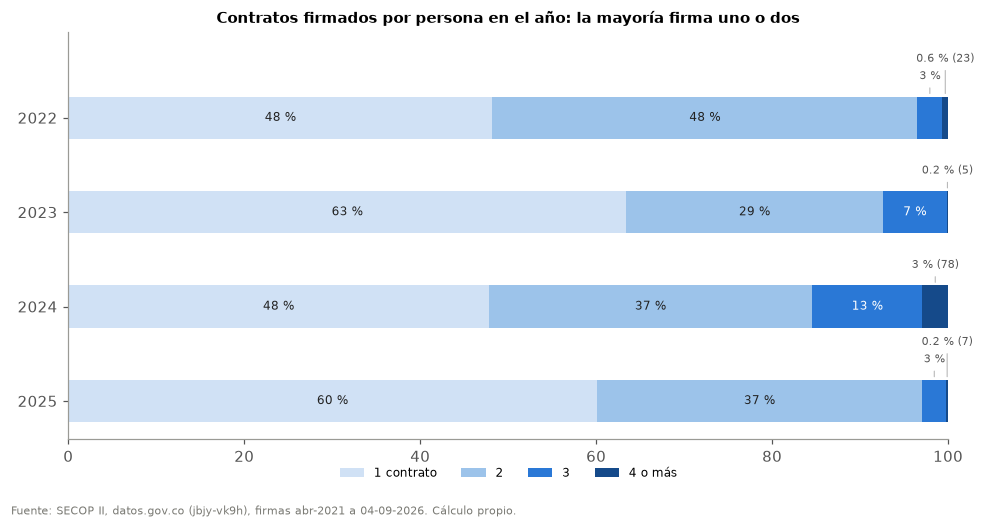

#### P24 · ¿Cuántos contratos firma una persona en un año?

**Un año, uno o dos contratos.** En los años completos, entre 48 % y 63 % de las personas firmó un solo CPS en el año, y entre 3 % y 15 % firmó tres o más. Un CPS empieza típicamente 2 a 3 días después de firmado. Hubo entre 54 y 315 contratos de menos de un mes por año, y SECOP registra 1 CPS con inicio anterior a la firma (posible error de registro).

**Qué no significa:** Firmar varios contratos en un año no es irregular; tampoco lo es un contrato de menos de un mes.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE` · *Límite:* Fechas registradas en SECOP II.

,anio,personas,promedio_contratos,pct_1_contrato,pct_2_contratos,pct_3_contratos,pct_4_o_mas,n_4_o_mas,cps_menos_de_1_mes,mediana_dias_firma_a_inicio,cps_inicio_antes_de_firma
0,2022,3548,1.6,48.2,48.3,2.8,0.6,23,54,3.0,0
1,2023,3038,1.4,63.4,29.2,7.2,0.2,5,315,3.0,0
2,2024,2666,1.7,47.8,36.8,12.5,2.9,78,76,2.0,0
3,2025,3241,1.4,60.0,37.0,2.7,0.2,7,126,2.0,1


In [40]:
filas = []
for y in ANIOS_COMPLETOS:
    d = cps.loc[cps["anio"].eq(y)]
    n = d.groupby(PERSONA).size()
    filas.append({"anio": y, "personas": len(n), "promedio_contratos": n.mean(),
                  "pct_1_contrato": n.eq(1).mean() * 100, "pct_2_contratos": n.eq(2).mean() * 100,
                  "pct_3_contratos": n.eq(3).mean() * 100, "pct_4_o_mas": n.ge(4).mean() * 100,
                  "n_4_o_mas": int(n.ge(4).sum()),
                  "cps_menos_de_1_mes": int(d["duracion_dias_incl"].lt(30).sum()),
                  "mediana_dias_firma_a_inicio": (d["fecha_inicio"] - d["fecha_firma"]).dt.days.median(),
                  "cps_inicio_antes_de_firma": int(d["flag_inicio_antes_firma"].sum())})
t_p24 = pd.DataFrame(filas)
fig, ax = plt.subplots(figsize=(9, 4.6))
n_rows = len(t_p24)
paso, alto = 1.9, 0.85
y_pos = np.arange(n_rows) * paso
izq = np.zeros(n_rows)
n_etq_fuera = np.zeros(n_rows, dtype=int)  # cuenta etiquetas fuera de la barra por año, para alternar su altura y que no se encimen
for col, ton, lab, col_n in [("pct_1_contrato", "#d0e1f5", "1 contrato", None), ("pct_2_contratos", "#9cc3ea", "2", None),
                             ("pct_3_contratos", "#2a78d6", "3", None), ("pct_4_o_mas", "#154a8a", "4 o más", "n_4_o_mas")]:
    vals = t_p24[col].to_numpy()
    ax.barh(y_pos, vals, left=izq, height=alto, color=ton, label=lab)
    for i, (l, w) in enumerate(zip(izq, vals)):
        if w <= 0:
            continue
        centro = l + w / 2
        texto = f"{w:.0f} %" if w >= 1 else f"{w:.1f} %"
        if col_n is not None:
            texto += f" ({int(t_p24.loc[i, col_n]):,})"
        if w >= 6:
            ax.text(centro, y_pos[i], texto, ha="center", va="center", fontsize=8, color="white" if ton in ("#2a78d6", "#154a8a") else "#222222")
        else:
            nivel = n_etq_fuera[i] % 2
            y_txt = y_pos[i] - alto / 2 - (0.3 if nivel == 0 else 0.65)
            ax.annotate(texto, xy=(centro, y_pos[i] - alto / 2), xytext=(centro, y_txt), ha="center", va="bottom",
                        fontsize=7, color="#555555", arrowprops=dict(arrowstyle="-", color="#aaaaaa", lw=0.6))
            n_etq_fuera[i] += 1
    izq += vals
ax.set_yticks(y_pos)
ax.set_yticklabels([str(a) for a in t_p24["anio"]])
ax.set_ylim(y_pos[-1] + alto / 2 + 0.35, y_pos[0] - alto / 2 - 1.3)
ax.set_xlim(0, 100)
ax.margins(x=0)
ax.legend(ncol=4, frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.04))
ax.set_title("Contratos firmados por persona en el año: la mayoría firma uno o dos", fontsize=10, fontweight="bold")
g_p24 = guardar_fig(fig, "a7_contratos_por_persona.png")
p24 = t_p24.set_index("anio")
insight("P24", "Acto 7 · Lo que no salta a la vista", "¿Cuántos contratos firma una persona en un año?",
        "Un año, uno o dos contratos",
        f"En los años completos, entre {p24['pct_1_contrato'].min():.0f} % y {p24['pct_1_contrato'].max():.0f} % de las personas firmó un solo CPS "
        f"en el año, y entre {(p24['pct_3_contratos'] + p24['pct_4_o_mas']).min():.0f} % y {(p24['pct_3_contratos'] + p24['pct_4_o_mas']).max():.0f} % "
        f"firmó tres o más. Un CPS empieza típicamente {p24['mediana_dias_firma_a_inicio'].min():.0f} a {p24['mediana_dias_firma_a_inicio'].max():.0f} "
        f"días después de firmado. Hubo entre {p24['cps_menos_de_1_mes'].min()} y {p24['cps_menos_de_1_mes'].max()} contratos de menos de un mes por año, "
        f"y SECOP registra {int(p24['cps_inicio_antes_de_firma'].sum())} CPS con inicio anterior a la firma (posible error de registro).",
        "Firmar varios contratos en un año no es irregular; tampoco lo es un contrato de menos de un mes.",
        "Dato descriptivo", "PUBLICABLE", "CPS de personas, Alcaldía central, años completos",
        "Fechas registradas en SECOP II.", t_p24, g_p24,
        cifra=f"{p24['pct_1_contrato'].min():.0f}–{p24['pct_1_contrato'].max():.0f} % firma un solo CPS al año")
t_p24.round(1)

## P25 ¿Hay un núcleo de personas que siempre está?

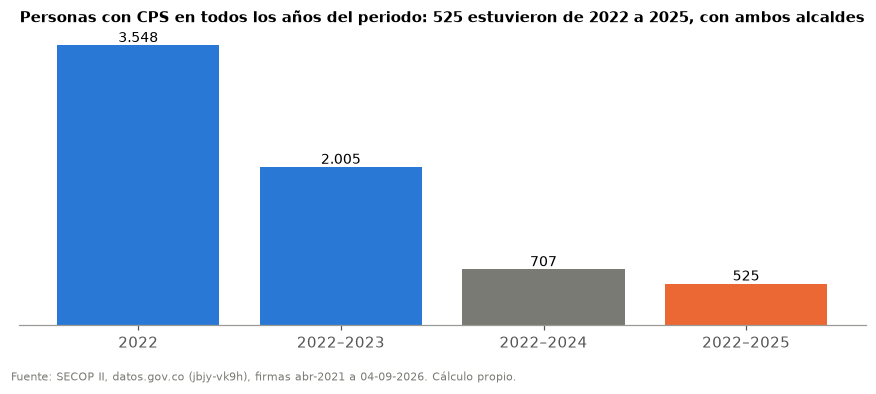

#### P25 · ¿Hay un núcleo de personas que siempre está?

**Un núcleo pequeño atraviesa los dos gobiernos.** De las 3.548 personas con CPS en 2022, 525 (15 %) firmaron al menos un CPS en cada año hasta 2025, cruzando el cambio de gobierno. 285 personas tuvieron CPS en todos los años observados, de 2021 a 2026.

**Qué no significa:** Estar en todos los años no es favoritismo: puede reflejar experiencia o servicios permanentes. Tampoco es un empleo de planta.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE` · *Límite:* Solo ve la Alcaldía central.

,desde,hasta,personas_en_todos_los_anios,pct_de_las_personas_iniciales
0,2022,2022,3548,100.000000
1,2022,2023,2005,56.510710
2,2022,2024,707,19.926719
3,2022,2025,525,14.797069


In [25]:
anios_nucleo = ANIOS_COMPLETOS
embudo, acumulado = [], None
for y in anios_nucleo:
    acumulado = S[y] if acumulado is None else acumulado & S[y]
    embudo.append({"desde": anios_nucleo[0], "hasta": y, "personas_en_todos_los_anios": len(acumulado)})
t_p25 = pd.DataFrame(embudo)
todos_6 = set.intersection(*[S[a] for a in sorted(S)])
t_p25["pct_de_las_personas_iniciales"] = t_p25["personas_en_todos_los_anios"] / t_p25.loc[0, "personas_en_todos_los_anios"] * 100
nucleo = len(acumulado)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar([f"{r.desde}" if r.desde == r.hasta else f"{r.desde}–{r.hasta}" for r in t_p25.itertuples()], t_p25["personas_en_todos_los_anios"],
       color=[AZUL, AZUL, GRIS, NARANJA][:len(t_p25)])
for i, v in enumerate(t_p25["personas_en_todos_los_anios"]):
    ax.text(i, v, es(f"{v:,}"), ha="center", va="bottom", fontsize=9)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_title(es(f"Personas con CPS en todos los años del periodo: {nucleo:,} estuvieron de 2022 a 2025, con ambos alcaldes"),
             fontsize=10, fontweight="bold")
g_p25 = guardar_fig(fig, "a7_nucleo_permanente.png")
insight("P25", "Acto 7 · Lo que no salta a la vista", "¿Hay un núcleo de personas que siempre está?",
        "Un núcleo pequeño atraviesa los dos gobiernos",
        f"De las {t_p25.loc[0, 'personas_en_todos_los_anios']:,} personas con CPS en {anios_nucleo[0]}, {nucleo:,} "
        f"({t_p25['pct_de_las_personas_iniciales'].iloc[-1]:.0f} %) firmaron al menos un CPS en cada año hasta {anios_nucleo[-1]}, cruzando el cambio "
        f"de gobierno. {len(todos_6):,} personas tuvieron CPS en todos los años observados, de 2021 a {CORTE.year}.",
        "Estar en todos los años no es favoritismo: puede reflejar experiencia o servicios permanentes. Tampoco es un empleo de planta.",
        "Dato descriptivo", "PUBLICABLE", "CPS de personas, Alcaldía central", "Solo ve la Alcaldía central.", t_p25, g_p25,
        cifra=f"{nucleo:,} personas con CPS cada año de {anios_nucleo[0]} a {anios_nucleo[-1]}")
t_p25

## P26 ¿De dónde salen estos datos y qué tan completos son?

In [26]:
t_p26 = cps.groupby("anio").agg(cps=("id_contrato", "size"),
                                pct_con_valor_pagado=("valor_pagado", lambda s: s.gt(0).mean() * 100),
                                pct_en_ejecucion=("estado_contrato", lambda s: s.eq("En ejecución").mean() * 100),
                                pct_estado_terminado_secop=("flag_estado_terminado", lambda s: s.mean() * 100),
                                pct_subtipo_ambiguo=("subtipo_cps", lambda s: s.eq("Ambiguo").mean() * 100)).reset_index()
if COB2021["verificado"]:
    txt_s1 = es(f"SECOP I tiene {COB2021['ene_mar'] + COB2021['abr_dic']:,} registros de la Alcaldía firmados en 2021: {COB2021['ene_mar']:,} entre "
                f"enero y marzo y solo {COB2021['abr_dic']} de abril en adelante. Eso confirma que la Alcaldía pasó a SECOP II en abril de 2021 y que el "
                f"análisis debe empezar ahí.")
else:
    txt_s1 = ("La consulta a SECOP I no se pudo hacer en esta ejecución (sin conexión), así que el paso de SECOP I a SECOP II en abril de 2021 "
              "no quedó verificado aquí; el análisis empieza en abril de 2021, primer mes con registro pleno en SECOP II.")
txt_ent = ""
if ent_v is not None:
    fuera_cat = ent_v.loc[~ent_v["en_catalogo"].astype(str).str.lower().eq("true")]
    txt_ent = (f" Otros {len(fuera_cat)} NIT con sede en Barrancabermeja publican en SECOP II y no se incluyeron (SENA regional, colegios, el "
               f"establecimiento penitenciario, entre otros); ninguno depende del alcalde salvo, en parte, los fondos de los colegios oficiales.")
else:
    txt_ent = " La lista de otras entidades de la ciudad en SECOP II no se pudo consultar en esta ejecución."
d26 = t_p26.set_index("anio")
conc03 = su.leer_csv(r03["concordancia_subtipo"])
insight("P26", "Acto 7 · Lo que no salta a la vista", "¿De dónde salen estos datos y qué tan completos son?",
        "Datos públicos con huecos conocidos",
        txt_s1 + txt_ent + f" El valor pagado aparece en {d26.loc[2022, 'pct_con_valor_pagado']:.0f} % de los CPS de 2022 pero en "
        f"{d26.loc[CORTE.year, 'pct_con_valor_pagado']:.0f} % de los de {CORTE.year}, que siguen en ejecución: por eso se usa el valor pactado. "
        f"La clasificación profesional / apoyo a la gestión sale del objeto del contrato; cuando el objeto dice ambas cosas se usa la profesión u "
        f"oficio nombrado (ingeniero, arquitecto, técnico, auxiliar…). Donde la etiqueta literal y la profesión existen a la vez, coinciden en el "
        f"{conc03['concordancia_pct'].min():.0f} % o más de los casos. Quedó ambiguo entre el {t_p26['pct_subtipo_ambiguo'].min():.1f} % y el "
        f"{t_p26['pct_subtipo_ambiguo'].max():.1f} % de los CPS según el año.",
        "La base no es un registro de nómina ni de pagos. El estado 'terminado' de SECOP depende de la antigüedad del contrato, no de cómo terminó.",
        "Dato descriptivo", "PUBLICABLE",
        "Corrida congelada de SECOP II y verificaciones del 01", "Las verificaciones externas dependen de la conexión al ejecutar el 01.", t_p26,
        cifra="SECOP II desde abril de 2021")
t_p26.round(1)

#### P26 · ¿De dónde salen estos datos y qué tan completos son?

**Datos públicos con huecos conocidos.** SECOP I tiene 765 registros de la Alcaldía firmados en 2021: 734 entre enero y marzo y solo 31 de abril en adelante. Eso confirma que la Alcaldía pasó a SECOP II en abril de 2021 y que el análisis debe empezar ahí. La lista de otras entidades de la ciudad en SECOP II no se pudo consultar en esta ejecución. El valor pagado aparece en 94 % de los CPS de 2022 pero en 60 % de los de 2026, que siguen en ejecución: por eso se usa el valor pactado. La clasificación profesional / apoyo a la gestión sale del objeto del contrato; cuando el objeto dice ambas cosas se usa la profesión u oficio nombrado (ingeniero, arquitecto, técnico, auxiliar…). Donde la etiqueta literal y la profesión existen a la vez, coinciden en el 98 % o más de los casos. Quedó ambiguo entre el 0,2 % y el 1,0 % de los CPS según el año.

**Qué no significa:** La base no es un registro de nómina ni de pagos. El estado 'terminado' de SECOP depende de la antigüedad del contrato, no de cómo terminó.

*Nivel:* Dato descriptivo · *Estado:* `PUBLICABLE` · *Límite:* Las verificaciones externas dependen de la conexión al ejecutar el 01.

,anio,cps,pct_con_valor_pagado,pct_en_ejecucion,pct_estado_terminado_secop,pct_subtipo_ambiguo
0,2021,2838,97.7,4.1,6.5,1.0
1,2022,5537,94.4,2.1,6.8,0.9
2,2023,4380,91.1,8.9,15.6,0.6
3,2024,4558,79.9,22.0,12.3,0.3
4,2025,4639,94.8,41.8,4.0,0.2
5,2026,4176,60.1,63.0,1.3,0.3


# Prueba de estrés: ¿se caen las conclusiones si cambian los supuestos?

In [27]:
def pct_7_meses(df, y):
    cp = su.cobertura_por_persona(df, f"{y}-01-01", f"{y + 1}-01-01")
    return float(cp["meses_cubiertos"].ge(7).mean() * 100)


def espera_mediana(ep, seg):
    o = ep.loc[ep["fin_excl"].le(CORTE - pd.Timedelta(days=seg)) & ~ep["fin_excl"].between(*TRANSICION)]
    return float(o.loc[o["dias_sin_contrato"].le(seg), "dias_sin_contrato"].median())


def veredicto(ok, si, no):
    return si if ok else no


# P04 sin prórrogas: fecha final original (fin registrado menos días adicionados)
cpsi_sp = cpsi.copy()
_fin = cpsi_sp["fin_excl"] - pd.to_timedelta(cpsi_sp["dias_adicionados"].fillna(0), unit="D")
cpsi_sp["fin_excl"] = _fin.where(_fin > cpsi_sp["fecha_inicio"], cpsi_sp["fecha_inicio"] + pd.Timedelta(days=1))
p7b, p7a = (pct_7_meses(cpsi, 2023), pct_7_meses(cpsi, 2025)), (pct_7_meses(cpsi_sp, 2023), pct_7_meses(cpsi_sp, 2025))
e365, e180 = espera_mediana(episodios, 365), espera_mediana(episodios, 180)
dif_gob = abs(p6.loc[A, "pct_renueva_90_dias"] - p6.loc[J, "pct_renueva_90_dias"])
vm90 = vm.loc[vm["duracion_dias_incl"].ge(90)]
med_real = lambda d, sub, a: float(d.loc[d["subtipo_cps"].eq(sub) & d["anio"].eq(a), "valor_mensual_real"].median())
S9 = {a: set(per_cps.loc[per_cps["anio"].eq(a), PERSONA]) for a in sorted(per_cps["anio"].unique())}
ret_base, ret_9 = len(S[2023] & S[2024]) / len(S[2023]) * 100, len(S[2023] & S9[2024]) / len(S[2023]) * 100
obra = nc.loc[nc["familia"].eq("Obra pública")]
obra_sin_max = obra.drop(obra.groupby("anio")["valor_real"].idxmax())
ob = {k: (d.loc[d["anio"].eq(2023), "valor_real"].sum(), d.loc[d["anio"].eq(2024), "valor_real"].sum()) for k, d in [("base", obra), ("alt", obra_sin_max)]}
filas = [
    ["P04", "% personas con 7+ meses de contrato (2023 / 2025)", "Fechas finales registradas", f"{p7b[0]:.0f} % / {p7b[1]:.0f} %",
     "Sin los días de prórroga", f"{p7a[0]:.0f} % / {p7a[1]:.0f} %", veredicto(p7a[0] > p7a[1], "Se mantiene: 2023 por encima de 2025", "Cambia el orden")],
    ["P06", "Espera mediana entre contratos (días)", "Seguimiento de 365 días", f"{e365:.0f}", "Seguimiento de 180 días", f"{e180:.0f}",
     veredicto(abs(e365 - e180) <= 10, "Se mantiene: cerca de mes y medio", "Cambia con el seguimiento: se publica el de 365 días, igual para todos")],
    ["P06", "Diferencia entre gobiernos en % renovado antes de 90 días", "Diferencia Alfonso–Jonathan", "no se publica",
     "Rango entre años de terminación", f"{r90.min():.0f} % a {r90.max():.0f} %",
     veredicto(r90.max() - r90.min() > dif_gob, "No se compara a los gobiernos: el año pesa más que el gobierno", "La diferencia entre gobiernos domina")],
    ["P09", f"Mediana real profesional {a0} → {a1} (millones)", "Contratos de 30 días o más",
     es(f"{millones(med_real(vm, P, a0)):.2f} → {millones(med_real(vm, P, a1)):.2f}"), "Solo contratos de 90 días o más",
     es(f"{millones(med_real(vm90, P, a0)):.2f} → {millones(med_real(vm90, P, a1)):.2f}"),
     veredicto(med_real(vm90, P, a1) < med_real(vm90, P, a0), "Se mantiene: erosión real con el tiempo", "Cambia")],
    ["P09", f"Cambio de la mediana real de apoyo {a0} → {a1}", "Solo contratos clasificados como apoyo", es(f"{apo:+.1f} %"),
     "Contando los ambiguos como apoyo", es(f"{apo_amb:+.1f} %"),
     veredicto(np.sign(apo) == np.sign(apo_amb), "Se mantiene la dirección", "Cambia: la tendencia de apoyo depende del clasificador y no se afirma")],
    ["P10", "Cambio real mediano, misma persona profesional", "Último CPS con Alfonso vs primero con Jonathan",
     es(f"{tp10.loc[P, 'mediana_cambio_real_pct']:+.1f} %"), "Misma persona, ene–ago 2022 vs 2026 (cuaderno 04)",
     es(f"{tp10.loc[P, 'cuaderno04_2022_vs_2026_mediana_cambio_pct']:+.1f} %"),
     veredicto(np.sign(tp10.loc[P, "mediana_cambio_real_pct"]) == np.sign(tp10.loc[P, "cuaderno04_2022_vs_2026_mediana_cambio_pct"]),
               "Se mantiene", "Cambia según el diseño: no se atribuye a un gobierno")],
    ["P12", "% de contratistas de la Alcaldía con CPS en otra entidad", "Solo CPS confirmados", f"{fila_tot['pct_alcaldia_y_otra']:.0f} %",
     "Sumando registros por revisar de la ESE", f"{fila_ese['pct_alcaldia_y_otra']:.0f} %",
     veredicto(abs(fila_tot["pct_alcaldia_y_otra"] - fila_ese["pct_alcaldia_y_otra"]) <= 5, "Se mantiene el orden de magnitud",
               "Cambia la magnitud: se publica solo la cifra de CPS confirmados")],
    ["P20", "% de personas de 2023 que siguen en 2024", "Solo Alcaldía central", f"{ret_base:.0f} %",
     "CPS en cualquiera de las nueve entidades", f"{ret_9:.0f} %",
     veredicto(ret_9 < mismo.min(), f"Se mantiene: muy por debajo de la continuidad dentro de un gobierno (≥{mismo.min():.0f} %)", "Cambia")],
    ["P22", "Obra 2023 vs 2024 (miles de millones reales)", "Todos los contratos de obra",
     es(f"{mm(ob['base'][0]):,.1f} vs {mm(ob['base'][1]):,.1f}"), "Sin el contrato de obra más grande de cada año",
     es(f"{mm(ob['alt'][0]):,.1f} vs {mm(ob['alt'][1]):,.1f}"), veredicto(ob["alt"][0] > 5 * ob["alt"][1], "Se mantiene: 2023 muy por encima de 2024", "Cambia")],
]
for met, nombre in [("personas", "Cambio en personas con CPS, año 3"), ("contratos", "Cambio en CPS firmados, año 3")]:
    vals = rng.loc[met, ["anio3_ene_ago", "meses_16_32", "meses_17_32"]].astype(float)
    filas.append(["P01", nombre, "Ventana principal ene–ago del año 3", es(f"{vals['anio3_ene_ago']:+.1f} %"),
                  "Rango en las tres ventanas del cuaderno 04", es(f"{vals.min():+.1f} % a {vals.max():+.1f} %"),
                  veredicto(bool((vals > 0).all() or (vals < 0).all()), "Se mantiene la dirección; se publica el rango, no una cifra",
                            "Cambia la dirección")])
t_estres = pd.DataFrame(filas, columns=["hallazgo", "indicador", "supuesto_base", "valor_base", "supuesto_alternativo",
                                        "valor_alternativo", "conclusion"])
SALIDAS["prueba_estres"] = guardar_tabla(t_estres, "prueba_de_estres.csv")
display(t_estres)

,hallazgo,indicador,supuesto_base,valor_base,supuesto_alternativo,valor_alternativo,conclusion
0,P04,% personas con 7+ meses de contrato (2023 / 2025),Fechas finales registradas,39 % / 28 %,Sin los días de prórroga,37 % / 26 %,Se mantiene: 2023 por encima de 2025
1,P06,Espera mediana entre contratos (días),Seguimiento de 365 días,47,Seguimiento de 180 días,36,Cambia con el seguimiento: se publica el de 36...
2,P06,Diferencia entre gobiernos en % renovado antes...,Diferencia Alfonso–Jonathan,no se publica,Rango entre años de terminación,40 % a 75 %,No se compara a los gobiernos: el año pesa más...
3,P09,Mediana real profesional 2021 → 2026 (millones),Contratos de 30 días o más,"5,11 → 4,23",Solo contratos de 90 días o más,"5,11 → 4,23",Se mantiene: erosión real con el tiempo
4,P09,Cambio de la mediana real de apoyo 2021 → 2026,Solo contratos clasificados como apoyo,"-9,7 %",Contando los ambiguos como apoyo,"-9,7 %",Se mantiene la dirección
5,P10,"Cambio real mediano, misma persona profesional",Último CPS con Alfonso vs primero con Jonathan,"+0,7 %","Misma persona, ene–ago 2022 vs 2026 (cuaderno 04)","-12,6 %",Cambia según el diseño: no se atribuye a un go...
6,P12,% de contratistas de la Alcaldía con CPS en ot...,Solo CPS confirmados,15 %,Sumando registros por revisar de la ESE,19 %,Se mantiene el orden de magnitud
7,P20,% de personas de 2023 que siguen en 2024,Solo Alcaldía central,30 %,CPS en cualquiera de las nueve entidades,33 %,Se mantiene: muy por debajo de la continuidad ...
8,P22,Obra 2023 vs 2024 (miles de millones reales),Todos los contratos de obra,"198,4 vs 3,2",Sin el contrato de obra más grande de cada año,"167,1 vs 1,8",Se mantiene: 2023 muy por encima de 2024
9,P01,"Cambio en personas con CPS, año 3",Ventana principal ene–ago del año 3,"+10,8 %",Rango en las tres ventanas del cuaderno 04,"+10,8 % a +26,5 %","Se mantiene la dirección; se publica el rango,..."


## Retrato compuesto: una persona contratista típica
No es una persona real: se arma con las medianas de cada indicador (técnica de "persona compuesta").

In [28]:
ult_completo = ANIOS_COMPLETOS[-1]
p4u = t_p4.set_index("anio").loc[ult_completo]
ret = {
    "anio": ult_completo,
    "contratos_en_el_anio": float(p4u["contratos_por_persona"]),
    "meses_con_contrato": float(p4u["mediana_meses_con_contrato"]),
    "duracion_mediana_contrato": float(cpsi.loc[cpsi["anio"].eq(ult_completo), "meses"].median()),
    "dias_espera_mediana": float(p6.loc[str(ult_completo), "mediana_dias_espera"]) if str(ult_completo) in p6.index else float(tot6["mediana_dias_espera"]),
    "pct_renueva_90": float(p6.loc[str(ult_completo), "pct_renueva_90_dias"]) if str(ult_completo) in p6.index else float(tot6["pct_renueva_90_dias"]),
    "mensual_profesional": float(t_p9b.loc[t_p9b["anio"].eq(ult_completo) & t_p9b["subtipo_cps"].eq(P), "mediana_nominal"].iloc[0]),
    "mensual_apoyo": float(t_p9b.loc[t_p9b["anio"].eq(ult_completo) & t_p9b["subtipo_cps"].eq(AP), "mediana_nominal"].iloc[0]),
    "valor_anual_mediano_real": float(rb.loc[ult_completo, "valor_real_mediano_por_persona"]),
}
RETRATO = es(
    f"Llamémosla Ana. No existe: está armada con los valores típicos (medianas y promedios) de miles de contratistas. En {ult_completo} firmó {ret['contratos_en_el_anio']:.1f} contratos en promedio con la "
    f"Alcaldía, cada uno de unos {ret['duracion_mediana_contrato']:.1f} meses. Sumó {ret['meses_con_contrato']:.1f} meses con contrato en el año. "
    f"Cuando uno terminó, esperó alrededor de {ret['dias_espera_mediana']:.0f} días por el siguiente (y tuvo {ret['pct_renueva_90']:.0f} % de "
    f"probabilidad de tenerlo antes de tres meses). Si es profesional, pactó unos {millones(ret['mensual_profesional']):.1f} millones al mes; "
    f"si es de apoyo a la gestión, {millones(ret['mensual_apoyo']):.1f} millones. En todo el año sumó cerca de "
    f"{millones(ret['valor_anual_mediano_real']):.1f} millones de pesos en contratos. En enero, como casi todos, no tuvo contrato.")
display(Markdown(f"> {RETRATO}"))
SALIDAS["retrato"] = guardar_tabla(pd.DataFrame([ret]), "retrato_compuesto.csv")

> Llamémosla Ana. No existe: está armada con los valores típicos (medianas y promedios) de miles de contratistas. En 2025 firmó 1,4 contratos en promedio con la Alcaldía, cada uno de unos 3,3 meses. Sumó 4,0 meses con contrato en el año. Cuando uno terminó, esperó alrededor de 34 días por el siguiente (y tuvo 74 % de probabilidad de tenerlo antes de tres meses). Si es profesional, pactó unos 4,0 millones al mes; si es de apoyo a la gestión, 2,5 millones. En todo el año sumó cerca de 14,0 millones de pesos en contratos. En enero, como casi todos, no tuvo contrato.

# Epílogo: Cómo se hizo: el viaje del dato
Del archivo descargado a cada cifra de esta historia. El embudo muestra cuántos registros sobreviven a cada decisión.

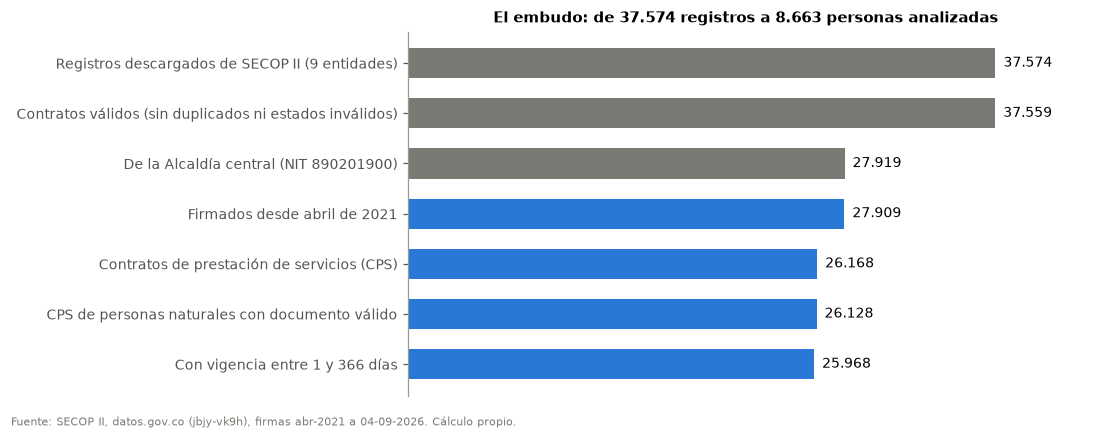

,decision,alternativa_descartada,por_que
0,La Alcaldía se identifica por su NIT (890201900),Filtrar por ciudad,"La ciudad mezcla entidades autónomas (Concejo,..."
1,Cada entidad por separado; nada se suma al alc...,Sumar todo lo de Barrancabermeja,El Concejo y los órganos de control no depende...
2,La persona es su número de documento,Usar el nombre,Los nombres cambian de escritura; el documento...
3,El análisis empieza en abril de 2021,Empezar en enero de 2021,Antes de abril la Alcaldía publicaba en SECOP ...
4,Comparar alcaldes solo en la ventana principal...,Comparar gobiernos completos o el año 2,Es la única ventana en la misma etapa del mand...
5,Duración inclusiva (fin − inicio + 1),Restar fechas sin más,Restar pierde un día por contrato y subestima ...
6,No sumar los días adicionados a la fecha final,Sumarlos,La prueba del 02 muestra que la fecha final ya...
7,Pesos constantes con el IPC del DANE,Pesos de cada año,Entre 2021 y 2026 la inflación cambia el poder...
8,Seguimiento igual de 365 días para medir renov...,Medir todas las esperas y agrupar por gobierno,El periodo más reciente tiene menos tiempo par...
9,Publicar conteos con fecha de firma en periodo...,Callarlos o presentarlos como ilegales,El conteo es un hecho verificable; la legalida...


,libreria,version,para_que
0,pandas,3.0.5,"Leer, limpiar, unir y resumir tablas."
1,numpy,2.5.3,"Cálculos vectorizados: series diarias, percent..."
2,matplotlib,3.11.1,Todas las gráficas.
3,openpyxl,(la que tenga instalada),Leer el anexo del IPC del DANE (cuaderno 04).
4,"pathlib, json, hashlib",biblioteca estándar,"Rutas relativas, manifiestos y huellas sha256 ..."
5,urllib,biblioteca estándar,Descarga desde la API de datos.gov.co y verifi...
6,"re, unicodedata",biblioteca estándar,Normalizar textos y reconocer tipos de contrat...
7,IPython.display,Jupyter,"Mostrar tablas, gráficas y texto en el cuaderno."


In [29]:
embudo_dato = pd.DataFrame([
    ("Registros descargados de SECOP II (9 entidades)", len(b)),
    ("Contratos válidos (sin duplicados ni estados inválidos)", int(b["es_valido_general"].sum())),
    ("De la Alcaldía central (NIT 890201900)", int((b["es_valido_general"] & b["es_central"]).sum())),
    ("Firmados desde abril de 2021", len(central)),
    ("Contratos de prestación de servicios (CPS)", int(central["es_cps_estricto"].sum())),
    ("CPS de personas naturales con documento válido", len(cps)),
    ("Con vigencia entre 1 y 366 días", len(cpsi)),
], columns=["paso", "registros"])
fig, ax = plt.subplots(figsize=(10, 3.8))
yy = np.arange(len(embudo_dato))[::-1]
ax.barh(yy, embudo_dato["registros"], color=[GRIS] * 3 + [AZUL] * 4, height=0.6)
for y_, (paso, n) in zip(yy, embudo_dato.itertuples(index=False)):
    ax.text(n, y_, es(f"  {n:,}"), va="center", fontsize=9)
ax.set_yticks(yy, embudo_dato["paso"], fontsize=9)
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
ax.set_xlim(0, len(b) * 1.15)
ax.set_title(es(f"El embudo: de {len(b):,} registros a {cps[PERSONA].nunique():,} personas analizadas"), fontsize=10, fontweight="bold")
g_embudo = guardar_fig(fig, "e_embudo_del_dato.png")
SALIDAS["grafico_embudo"] = g_embudo
SALIDAS["embudo"] = guardar_tabla(embudo_dato, "embudo_del_dato.csv")

DECISIONES = pd.DataFrame([
    ("La Alcaldía se identifica por su NIT (890201900)", "Filtrar por ciudad", "La ciudad mezcla entidades autónomas (Concejo, Contraloría) con la Alcaldía."),
    ("Cada entidad por separado; nada se suma al alcalde automáticamente", "Sumar todo lo de Barrancabermeja", "El Concejo y los órganos de control no dependen del alcalde."),
    ("La persona es su número de documento", "Usar el nombre", "Los nombres cambian de escritura; el documento no."),
    ("El análisis empieza en abril de 2021", "Empezar en enero de 2021",
     es(f"Antes de abril la Alcaldía publicaba en SECOP I: {COB2021['ene_mar']:,} registros de enero a marzo de 2021 y {COB2021['abr_dic']} "
        f"de abril en adelante (verificado en el 01).") if COB2021["verificado"] else
     "Es el primer mes con registro pleno en SECOP II; la verificación con SECOP I la hace el 01 cuando tiene conexión y en esta ejecución no se pudo."),
    ("Comparar alcaldes solo en la ventana principal (ene–ago del año 3)", "Comparar gobiernos completos o el año 2", "Es la única ventana en la misma etapa del mandato con cobertura completa en SECOP II."),
    ("Duración inclusiva (fin − inicio + 1)", "Restar fechas sin más", "Restar pierde un día por contrato y subestima la cobertura."),
    ("No sumar los días adicionados a la fecha final", "Sumarlos", "La prueba del 02 muestra que la fecha final ya los incluye."),
    ("Pesos constantes con el IPC del DANE", "Pesos de cada año", "Entre 2021 y 2026 la inflación cambia el poder de compra; se muestran ambas."),
    ("Seguimiento igual de 365 días para medir renovaciones, por año de terminación", "Medir todas las esperas y agrupar por gobierno", "El periodo más reciente tiene menos tiempo para mostrar esperas largas (sesgo de censura) y el año electoral pesa más que el gobierno."),
    ("Publicar conteos con fecha de firma en periodos de Ley de Garantías como dato, no como infracción", "Callarlos o presentarlos como ilegales", "El conteo es un hecho verificable; la legalidad depende de excepciones y expedientes."),
    ("Valor pactado, no pagado", "Valor pagado", "El pagado falta en contratos en ejecución."),
    ("No imputar datos faltantes", "Rellenar con promedios", "Rellenar inventa información."),
    ("Desempatar el subtipo por la profesión u oficio nombrado en el objeto", "Dejar ambiguos los objetos que dicen 'profesionales y de apoyo'",
     "El rol nombrado (arquitecto, técnico, auxiliar) es evidencia directa; la regla coincide con la etiqueta literal en más del 98 % de los casos."),
    ("Estados de publicación por reglas", "Publicar todo", "Evita convertir una coincidencia en acusación."),
], columns=["decision", "alternativa_descartada", "por_que"])
SALIDAS["decisiones"] = guardar_tabla(DECISIONES, "decisiones_metodologicas.csv")
LIBRERIAS = pd.DataFrame([
    ("pandas", pd.__version__, "Leer, limpiar, unir y resumir tablas."),
    ("numpy", np.__version__, "Cálculos vectorizados: series diarias, percentiles, Gini."),
    ("matplotlib", matplotlib.__version__, "Todas las gráficas."),
    ("openpyxl", "(la que tenga instalada)", "Leer el anexo del IPC del DANE (cuaderno 04)."),
    ("pathlib, json, hashlib", "biblioteca estándar", "Rutas relativas, manifiestos y huellas sha256 de cada archivo."),
    ("urllib", "biblioteca estándar", "Descarga desde la API de datos.gov.co y verificaciones externas (cuaderno 01)."),
    ("re, unicodedata", "biblioteca estándar", "Normalizar textos y reconocer tipos de contrato y dependencias."),
    ("IPython.display", "Jupyter", "Mostrar tablas, gráficas y texto en el cuaderno."),
], columns=["libreria", "version", "para_que"])
display(DECISIONES)
LIBRERIAS

# Historia ciudadana: ensamblaje
Solo entran al texto los hallazgos publicables. Las anomalías van como **preguntas** sin cifras; lo que SECOP no sostiene, como límite
explícito.

# ¿Cómo contrata la Alcaldía de Barrancabermeja?

*Lo que muestran los contratos publicados en SECOP II entre abril de 2021 y el 4 de septiembre de 2026, contado de lo general a lo particular.*

> **La gran idea.** La Alcaldía contrata a miles de personas con contratos cortos que se firman en oleadas que coinciden con el calendario del presupuesto y de las elecciones. Las personas encadenan contratos con pausas de semanas entre uno y otro, y con el cambio de gobierno 6 de cada 10 contratistas no volvieron a tener CPS con la Alcaldía.

- **26.128** CPS con personas firmados desde abril de 2021
- **8.663** personas distintas contratadas
- **94 % / 17 %** de los contratos / del valor son CPS (mediana anual)
- **47 días** espera típica entre un contrato y el siguiente (mediana)
- **28–39 %** de las personas suma 7 meses o más de contrato al año
- **525** personas con CPS todos los años de 2022 a 2025

## Conozca a Ana, la contratista típica

> Llamémosla Ana. No existe: está armada con los valores típicos (medianas y promedios) de miles de contratistas. En 2025 firmó 1,4 contratos en promedio con la Alcaldía, cada uno de unos 3,3 meses. Sumó 4,0 meses con contrato en el año. Cuando uno terminó, esperó alrededor de 34 días por el siguiente (y tuvo 74 % de probabilidad de tenerlo antes de tres meses). Si es profesional, pactó unos 4,0 millones al mes; si es de apoyo a la gestión, 2,5 millones. En todo el año sumó cerca de 14,0 millones de pesos en contratos. En enero, como casi todos, no tuvo contrato.

Esta historia recorre 27.909 contratos de la Alcaldía central (NIT 890201900), 26.128 de ellos contratos de prestación de servicios (CPS) con 8.663 personas, durante el final del gobierno de Alfonso Eljach (desde abril de 2021) y el de Jonathan Vásquez (desde enero de 2024). No describe empleos de planta, salarios ni pagos: describe lo que se pactó al firmar. Ninguna persona contratista se identifica.

- **Dato descriptivo:** conteo o suma de un universo validado.
- **Patrón estadístico:** regularidad que se repite en el tiempo o entre grupos.
- **Anomalía que requiere documentos:** algo que SECOP muestra pero solo un expediente explica; aquí va como pregunta.
- **Qué no significa:** cada hallazgo dice qué conclusión no se puede sacar de él.

## Acto 1 · El tamaño

Primero, la escala: cuántos contratos, cuántas personas y cuánto dinero maneja cada alcalde.

### ¿Cuántos contratos firma cada alcalde y cuántos son con personas?

**Nueve de cada diez contratos son CPS con personas.** En los 33 meses observados del gobierno de Alfonso Eljach (abr-2021 a dic-2023) la Alcaldía central firmó 13.669 contratos; 12.755 fueron CPS con 4.986 personas distintas (386 CPS al mes). En los 32 meses de Jonathan Vásquez (ene-2024 al corte) firmó 14.240 contratos; 13.373 CPS con 5.256 personas (416 al mes). Los dos periodos no son la misma etapa del mandato, así que la comparación justa es el año 3 (enero–agosto de 2022 y de 2026): 3.378 CPS con 2.819 personas con Alfonso y 4.133 con 3.123 con Jonathan. La dirección (más CPS y más personas en el periodo de Jonathan) se mantiene con todas las ventanas del cuaderno 04, pero el tamaño del aumento cambia según la ventana: de +10,8 % a +26,5 % en personas y de +22,4 % a +25,4 % en contratos.

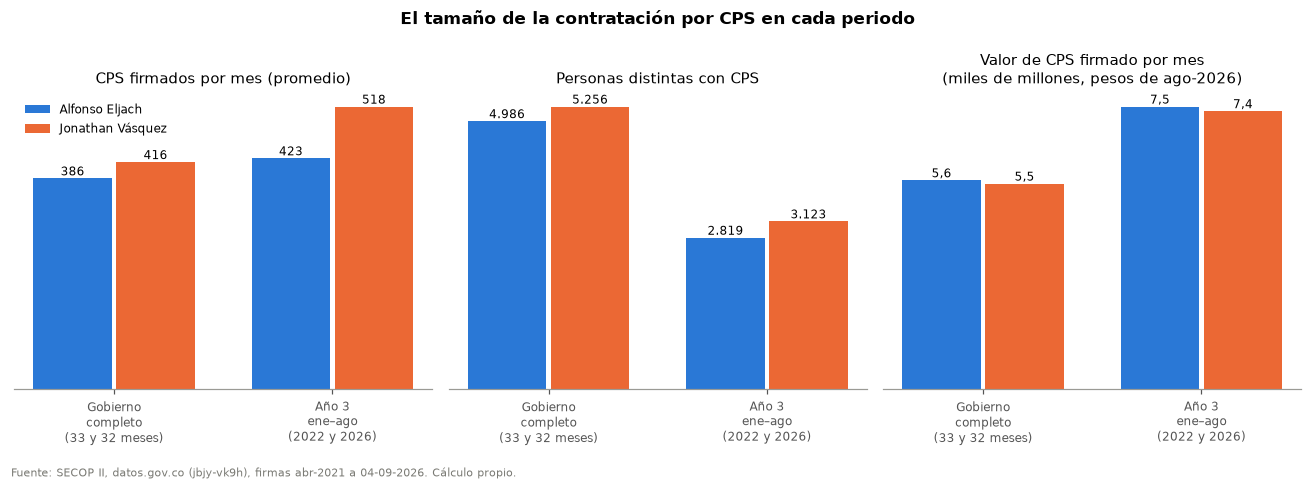

> **Qué no significa:** Más contratos no significa más empleo ni mejor gestión: un mismo trabajo puede partirse en varios contratos cortos. Los gobiernos están en etapas distintas del mandato; por eso se comparan ventanas equivalentes.

<sub>Dato descriptivo · publicable · universo: Contratos válidos de la Alcaldía central (NIT 890201900); CPS de personas con identidad apta · límite: El periodo de Alfonso empieza en abril de 2021 (verificado: SECOP I tiene 734 registros de la Alcaldía de enero a marzo de 2021 y solo 31 de abril en adelante). · tabla: p01_nueve_de_cada_diez_contratos_son_cps_con.csv</sub>

### ¿Cuánto dinero es y qué parte se va en CPS?

**Muchos contratos, poca plata.** Cada año entre 92 % y 95 % de los contratos son CPS, pero se llevan entre 13 % y 31 % del valor firmado. En todo el gobierno observado de Alfonso los CPS sumaron 183,7 miles de millones de pesos constantes (5,6 al mes) y en el de Jonathan 175,9 (5,5 al mes). El resto del dinero va a obras, convenios, bienes y servicios de empresas (Acto 6).

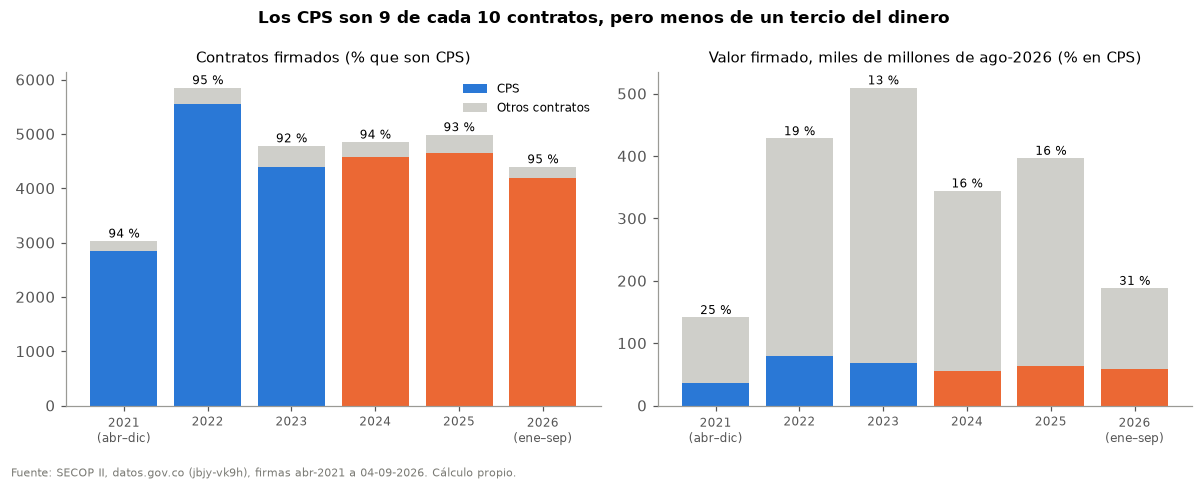

> **Qué no significa:** Es valor pactado al firmar, no pagado. Un año con mucha obra hace que los CPS pesen menos en porcentaje.

<sub>Dato descriptivo · publicable · universo: Contratos válidos de la Alcaldía central · límite: 2021 y el año del corte son parciales; el valor de los meses sin IPC publicado queda fuera de las sumas. · tabla: p02_muchos_contratos_poca_plata.csv</sub>

## Acto 2 · La vida de un contratista

Detrás de los totales hay personas que encadenan contratos cortos, con pausas entre uno y otro.

### ¿Cuánto dura un contrato? ¿Cuántos pasan de 6 o 7 meses?

**Contratos cortos.** Un CPS dura en promedio 3,7 meses con Alfonso y 3,5 con Jonathan (mediana 3,9 y 3,0). Los contratos de 6 meses o más son la excepción: 1.052 (8,3 %) con Alfonso y 499 (3,8 %) con Jonathan; de 7 meses o más, 419 y 169. De los de 7 meses o más de Alfonso, 385 se firmaron en 2023 (el 9 % de los CPS de ese año, el último del gobierno): esa tanda explica casi toda la diferencia. En la ventana comparable (enero–agosto del año 3) los de 7 meses o más fueron 0,4 % y 0,3 %, y los de 6 meses o más 1,0 % y 2,5 %: no hay una diferencia de fondo entre gobiernos. En los años completos solo entre el 0,1 % y el 0,2 % de los CPS termina después del 31 de diciembre del año en que se firmó.

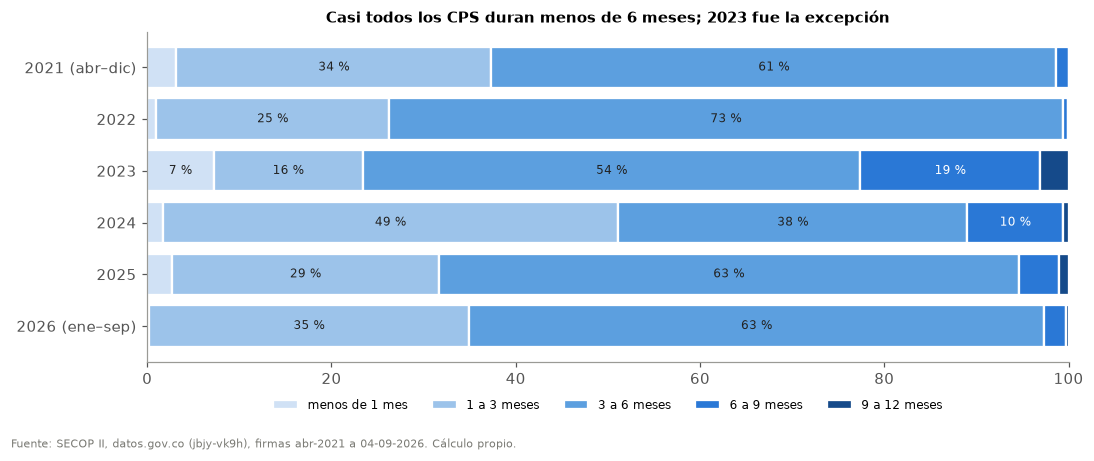

> **Qué no significa:** Un contrato corto no implica un servicio mal prestado. El dato no dice por qué se pactan así (presupuesto anual, planeación u otras razones).

<sub>Dato descriptivo · publicable · universo: CPS de personas, Alcaldía central, vigencia 1–366 días · límite: Vigencia pactada registrada (ya incluye prórrogas), no días trabajados. · tabla: p03_contratos_cortos.csv</sub>

### ¿Cuántas personas son "las más estables" (7 meses o más con contrato en el año)?

**Contratos cortos, personas que encadenan.** Aunque pocos contratos pasan de 7 meses, muchas personas suman 7 meses o más con contrato en el año encadenando varios: 2022: 1.186 personas (34 %); 2023: 1.198 personas (39 %); 2024: 801 personas (30 %); 2025: 921 personas (28 %). Con 10 meses o más, casi todo el año, solo entre 6 % y 9 %. La persona típica tuvo contrato entre 4,0 y 5,7 meses del año y firmó en promedio 1,4 a 1,7 contratos. 2022 y 2023 son los años 3 y 4 de Alfonso; 2024 y 2025, los años 1 y 2 de Jonathan.

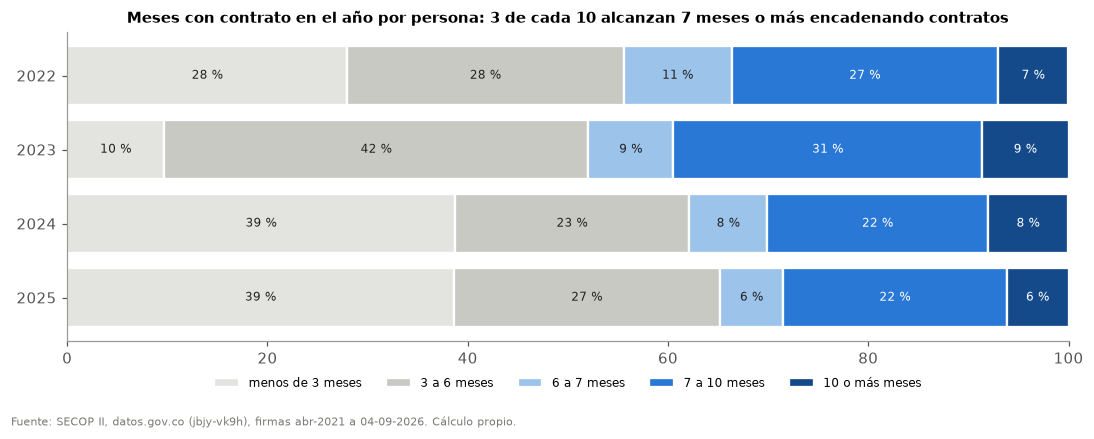

> **Qué no significa:** No mide ingresos anuales ni empleo: fuera de la Alcaldía la persona puede tener otros trabajos.

<sub>Patrón estadístico · publicable con cautela · universo: CPS de personas, Alcaldía central, años calendario completos · límite: Etapas distintas del mandato; fechas pactadas, no días trabajados. · tabla: p04_contratos_cortos_personas_que_encadenan.csv</sub>

### ¿Cuáles son los contratos más largos que dio cada alcalde?

**Ningún CPS válido llega a un año.** El CPS más largo del gobierno de Alfonso duró 11,4 meses y el de Jonathan 10,6. Con Alfonso hubo 140 CPS de 9 meses o más (74 de 10 o más); con Jonathan, 86 (28). En el año 3 (enero–agosto) fueron 4 y 12. De los CPS de 9 meses o más, tuvieron prórroga el 24 % con Alfonso y el 48 % con Jonathan. Además, 1 CPS con más de 366 días de vigencia registrada se deja fuera de estos cálculos por ser probable error de registro (sigue en la base).

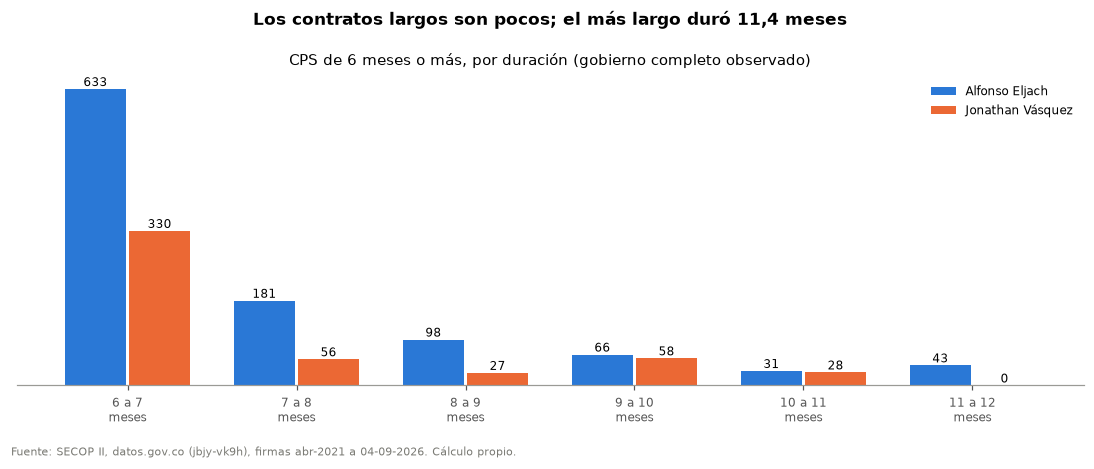

> **Qué no significa:** Un contrato largo no es un privilegio ni un empleo: sigue siendo un CPS. La lista con nombres queda para verificación interna.

<sub>Dato descriptivo · publicable · universo: CPS de personas, Alcaldía central, vigencia 1–366 días · límite: Se publican conteos por banda de duración; la lista de contratos queda para verificación interna. · tabla: p05_ningun_cps_valido_llega_a_un_ano.csv</sub>

### Cuando se acaba un contrato, ¿cuánto tarda la renovación?

**Mes y medio de espera típica.** Entre quienes vuelven a tener un CPS con la Alcaldía en menos de un año, la espera promedio es de 72 días (2,4 meses) y la mediana de 47 días: la mitad espera menos de mes y medio. Pero cuántos renuevan depende mucho del año: antes de 90 días volvió a tener contrato entre el 40 % (finales de 2022) y el 75 % (finales de 2021). Esa variación entre años es mayor que la diferencia entre gobiernos, por eso no se compara a los alcaldes con este indicador. En el cambio de gobierno solo el 39 % volvió dentro del año. Quien termina en diciembre espera una mediana de 56 días: el vacío de enero.

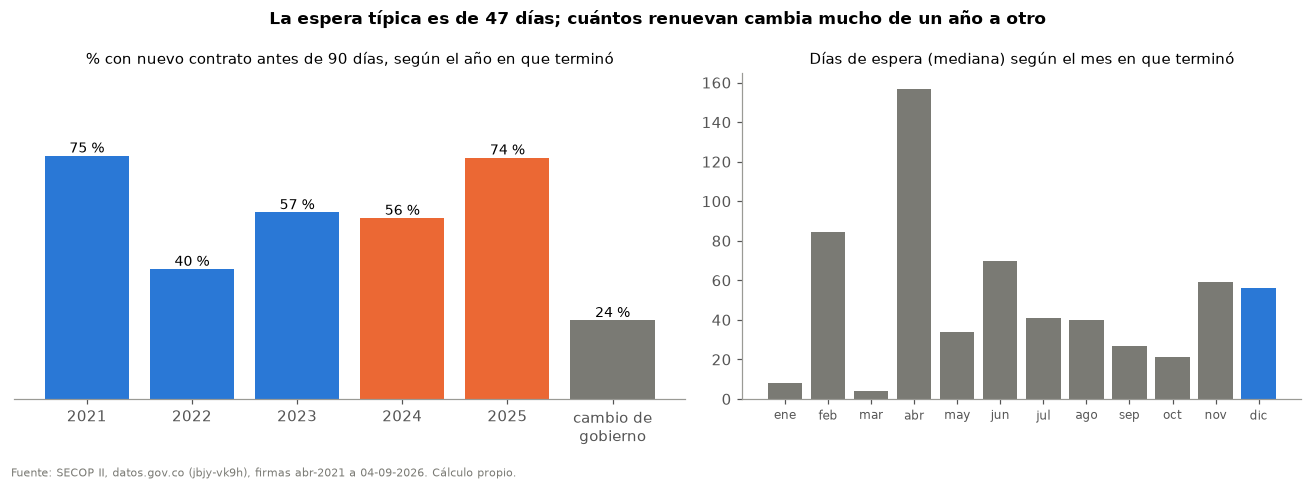

> **Qué no significa:** Esperar no significa estar desempleado: la persona puede trabajar en otra parte. No renovar no es despido.

<sub>Patrón estadístico · publicable con cautela · universo: Episodios de CPS de la Alcaldía central terminados al menos 365 días antes del corte · límite: Seguimiento igual de 365 días; solo ve la Alcaldía central. El Q04 del 06 mide pausas dentro de una ventana (otra definición) y da cifras distintas. · tabla: p06_mes_y_medio_de_espera_tipica.csv</sub>

### ¿Cuántas personas tienen contrato vigente cada día?

**Cada enero la contratación se apaga.** En un día cualquiera de los años completos había en promedio entre 1.124 y 1.661 personas con CPS vigente, con picos de hasta 2.737 (3.013 en 2026). Pero el 15 de enero de 2022 a 2025 había entre 1 y 4 personas: cada año hubo entre 19 y 24 días con menos de 100 contratistas. 2026 rompe el patrón: el 15 de enero ya había 757. Coincide con que ese año los CPS empezaron a firmarse antes: la primera tanda de enero (10 o más CPS en un día) llegó el 5 de enero, frente al 15–18 de enero de los años completos (Acto 5).

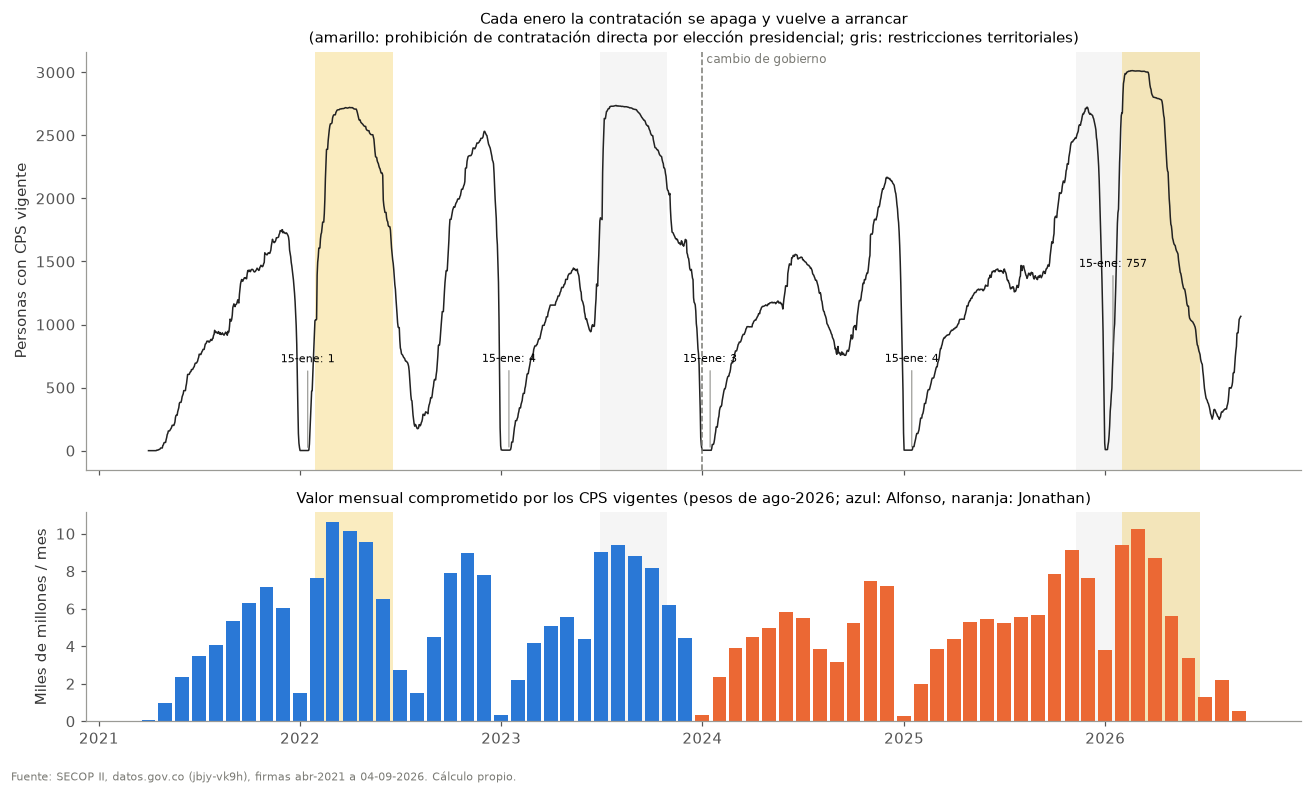

> **Qué no significa:** No significa que los servicios se suspendan ni que las personas queden sin ingresos: describe la vigencia pactada de los CPS.

<sub>Patrón estadístico · publicable con cautela · universo: CPS de personas, Alcaldía central, vigencia 1–366 días · límite: Fechas pactadas; una terminación anticipada no registrada infla la vigencia. · tabla: p07_cada_enero_la_contratacion_se_apaga.csv</sub>

### ¿Qué tan frecuentes son las prórrogas?

**Las prórrogas se volvieron frecuentes.** El porcentaje de CPS con días adicionados pasó de 2 % en 2022 a 31 % en 2026 (hasta el corte), con una prórroga mediana de 32 días. En 2026 casi todas son de contratos firmados en enero, antes de la Ley de Garantías (Acto 5).

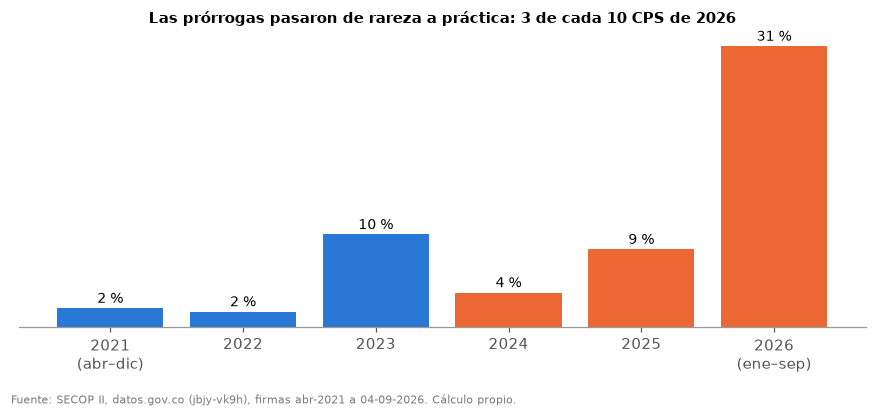

> **Qué no significa:** Prorrogar está previsto en la ley y el dato no evalúa cada prórroga. Lo que cambia es la forma de contratar: más extensiones de contratos vigentes.

<sub>Patrón estadístico · publicable con cautela · universo: CPS de personas, Alcaldía central · límite: Los contratos de 2026 siguen en ejecución y pueden sumar más prórrogas. · tabla: p08_las_prorrogas_se_volvieron_frecuentes.csv</sub>

## Acto 3 · El dinero en el bolsillo

Cuánto se pacta al mes, cómo cambia con la inflación y el salario mínimo, y cómo se reparte.

### ¿Cuánto pacta al mes un profesional y un apoyo a la gestión con cada alcalde?

**Más pesos, menos poder de compra con el paso del tiempo.** En pesos de cada año, con Alfonso (abr-2021 a dic-2023) un CPS profesional pactó en promedio 3,72 millones al mes (mediana 3,51) y uno de apoyo a la gestión 2,07 (mediana 2,00). Con Jonathan (ene-2024 al corte): profesional 4,25 (mediana 4,02) y apoyo 2,60 (mediana 2,54). En pesos de cada año las cifras incluyen el efecto de la inflación. Descontando la inflación, la mediana profesional pasó de 5,1 millones en 2021 a 4,2 en 2026 (pesos de agosto de 2026), y en salarios mínimos de 3,8 a 2,3: los honorarios crecieron menos que la inflación y mucho menos que el salario mínimo. La caída empezó en 2022 y 2023, tuvo un repunte en 2024 y siguió después, así que no se atribuye a un alcalde (el 06 marca esa comparación como no publicable). En apoyo a la gestión la mediana real cambió -9,7 % entre 2021 y 2026, o -9,7 % si los contratos de subtipo ambiguo se cuentan como apoyo: la magnitud depende del clasificador.

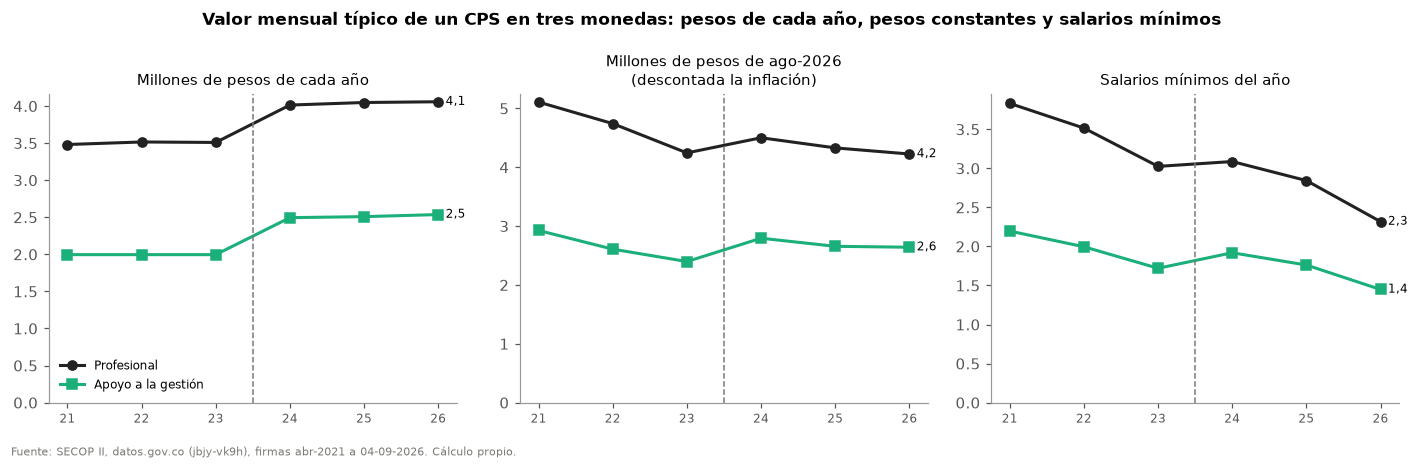

> **Qué no significa:** No es salario ni ingreso: no descuenta aportes ni cuenta los meses sin contrato. No dice si un gobierno paga más o menos que otro.

<sub>Dato descriptivo · publicable con cautela · universo: CPS de personas con 30 días o más y subtipo claro, Alcaldía central · límite: El subtipo profesional/apoyo sale del texto del contrato (SIN_VALIDACION_MANUAL). IPC nacional. · tabla: p09_mas_pesos_menos_poder_de_compra_con_el_p.csv</sub>

### A la misma persona, ¿le cambió el valor mensual?

**Para la misma persona, el resultado depende de cuándo se mida.** De las 775 personas con CPS profesional en ambos gobiernos, al comparar su último contrato con Alfonso y su primero con Jonathan (una mediana de 12 meses después), el valor mensual subió +11,9 % en pesos de cada año y +0,7 % descontando la inflación (mediana), pero el 48 % perdió poder de compra. Si la misma persona se compara con cuatro años de distancia (enero–agosto de 2022 frente a 2026, cuaderno 04), la mediana real profesional cae -12,6 % y solo el 21 % tuvo aumento. En apoyo a la gestión: +8,7 % real en el cambio de gobierno y +1,2 % entre 2022 y 2026. La lectura consistente es la de la serie (P09): los valores reales se erosionan con el tiempo, con un repunte puntual en el cambio de gobierno.

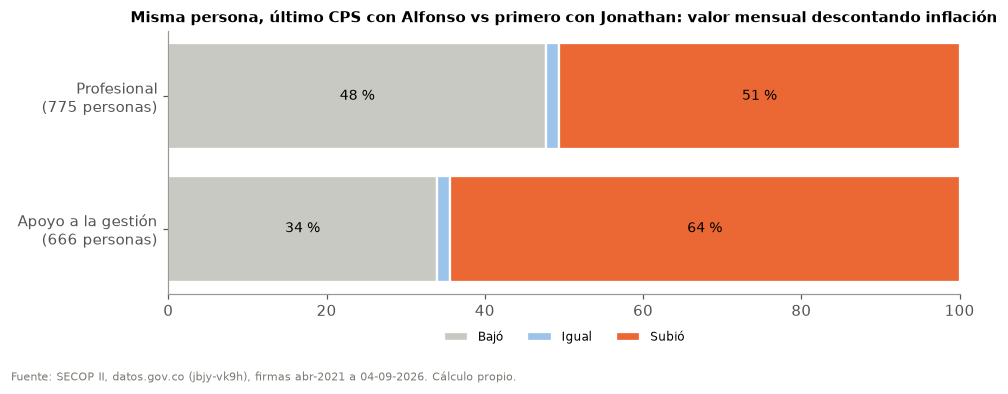

> **Qué no significa:** No es un aumento ni un recorte de sueldo: el objeto del contrato puede cambiar y entre un contrato y otro pasa tiempo. No permite decir que un alcalde pague más o menos.

<sub>Patrón estadístico · publicable con cautela · universo: Personas con CPS del mismo subtipo en ambos gobiernos, 30 días o más · límite: Subtipo por texto (SIN_VALIDACION_MANUAL); el resultado cambia con el intervalo de tiempo entre contratos. · tabla: p10_para_la_misma_persona_el_resultado_depen.csv</sub>

### ¿Cómo se reparte el dinero de los CPS entre las personas?

**Sin concentración extrema.** En los años completos, el 10 % de las personas con más valor contratado reunió entre 25 % y 28 % del total, y la mitad con menos valor entre 19 % y 23 % (índice de Gini 0,38–0,43): hay desigualdad moderada, sin un grupo pequeño que concentre la mayor parte. En un año completo, una persona sumó en promedio entre 19,2 y 22,5 millones de pesos constantes en CPS (mediana 14,0–18,0); el 10 % superior pasó de 42,7 millones.

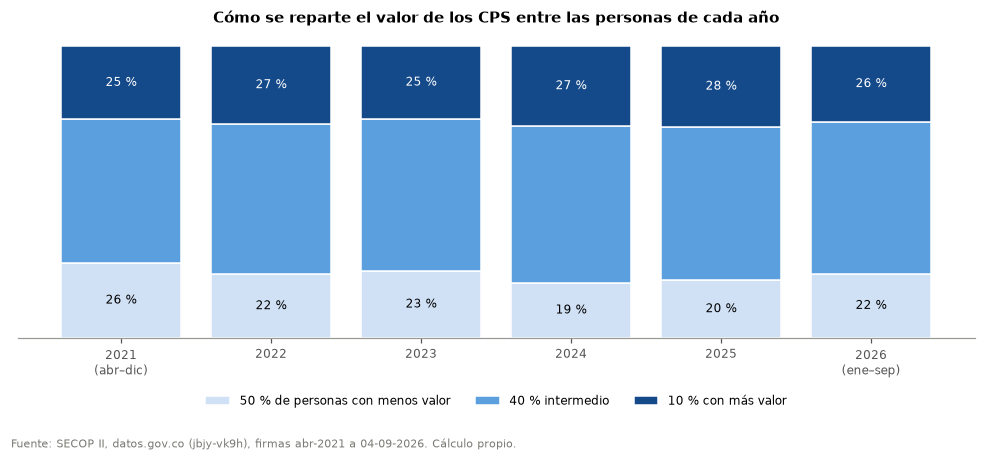

> **Qué no significa:** No mide ingresos totales: una persona puede tener otros contratos, empleos o fuentes.

<sub>Dato descriptivo · publicable · universo: CPS de personas, Alcaldía central, valor con IPC publicado · límite: Valor pactado al firmar, no pagado. · tabla: p11_sin_concentracion_extrema.csv</sub>

## Acto 4 · Varias puertas

Muchas personas no solo contratan con la Alcaldía: también con entidades del Distrito o autónomas.

### ¿Cuántas personas han contratado con la Alcaldía y también con otras entidades?

**15 % de los contratistas de la Alcaldía también tuvo CPS en otra entidad.** De las 8.663 personas con CPS en la Alcaldía central desde abril de 2021, 1.281 (15 %) también tuvieron CPS con otra entidad en algún momento: 631 con el Concejo, 323 con INDERBA, 163 con EDUBA, 140 con la Personería y 127 con Tránsito. 188 de ellas pasaron por tres o más entidades. Aparte, 397 contratistas de la Alcaldía aparecen en registros de servicios personales de la ESE que aún no se confirman como CPS. Cada entidad empezó a publicar con regularidad en SECOP II en un mes distinto (entre 2021-04 y 2025-07), por eso no se comparan gobiernos con este dato.

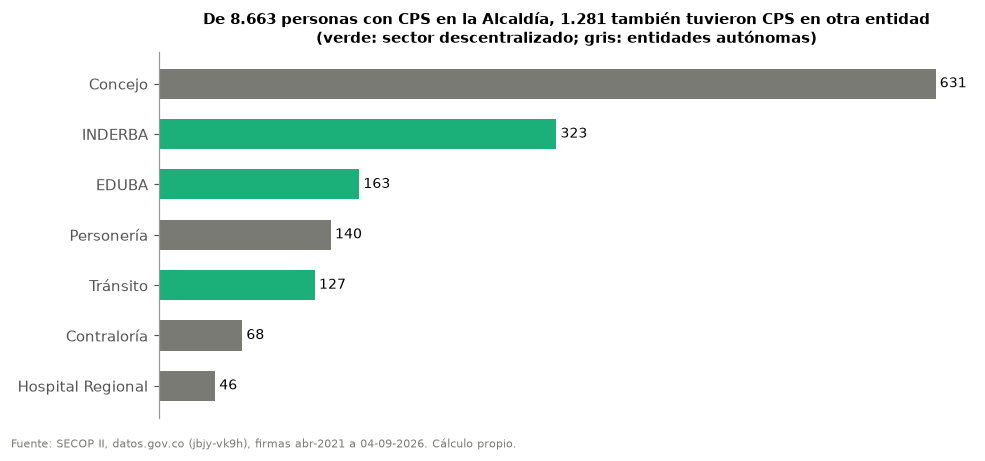

> **Qué no significa:** Contratar con dos entidades no es irregular: casi siempre son contratos en momentos distintos. Si hubo contratos al mismo tiempo se revisa en el 05 y requiere expedientes. El Concejo, la Personería y la Contraloría no dependen del alcalde.

<sub>Dato descriptivo · publicable con cautela · universo: CPS de personas naturales con identidad apta en las nueve entidades · límite: Cobertura de SECOP II distinta por entidad; combinaciones con menos de 10 personas no se muestran. · tabla: p12_15_de_los_contratistas_de_la_alcaldia_ta.csv</sub>

### ¿Cómo contratan las otras entidades?

**Las otras entidades crecen en SECOP II.** INDERBA firmó entre 370 y 583 contratos por año completo; el Concejo, entre 269 y 304. La ESE pasó de 105 contratos en 2022 a 798 en 2025, y el Hospital Regional aparece solo desde 2025. Esos saltos pueden reflejar, al menos en parte, que las entidades empezaron a publicar en SECOP II; no se puede leer como más contratación sin revisar SECOP I.

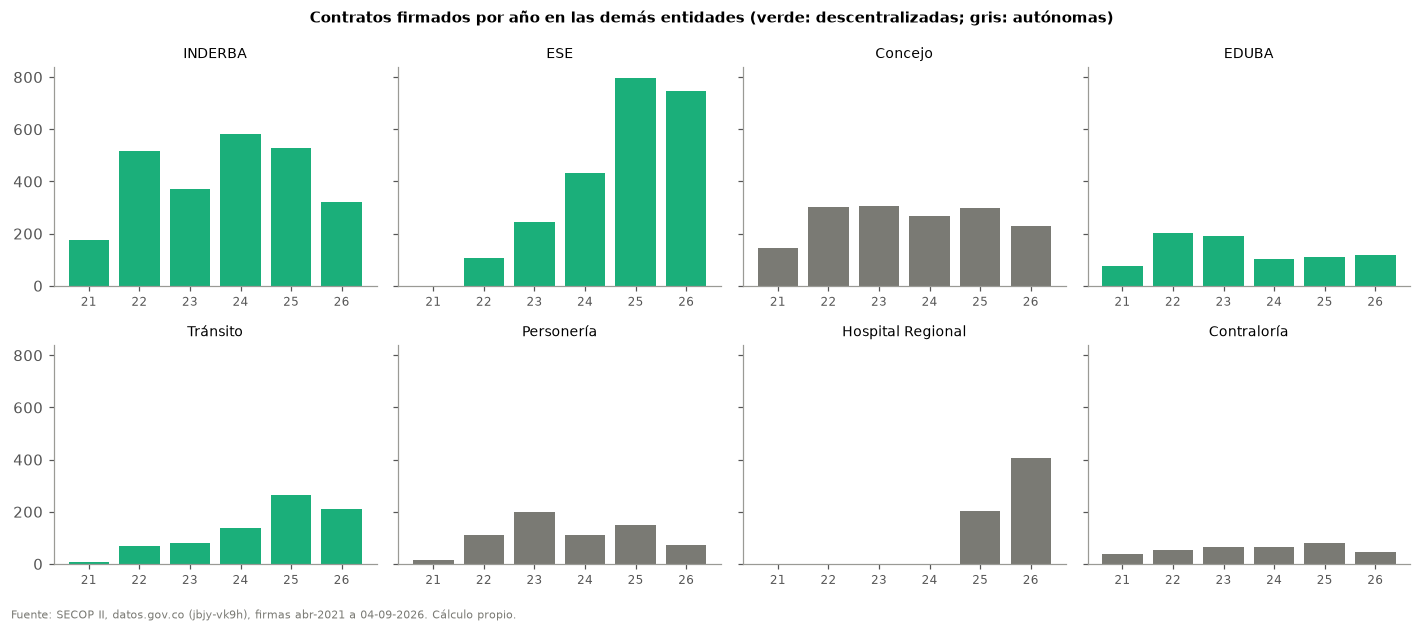

> **Qué no significa:** No se suman al alcalde las entidades autónomas. Los cambios de publicación impiden comparar gobiernos en estas entidades.

<sub>Dato descriptivo · publicable con cautela · universo: Contratos válidos de las nueve entidades · límite: Cobertura de SECOP II distinta por entidad y año. · tabla: p13_las_otras_entidades_crecen_en_secop_ii.csv</sub>

## Acto 5 · El reloj político

El ritmo de firmas coincide con el calendario del presupuesto y de las elecciones, y en el cambio de gobierno la mayoría de contratistas no siguió.

### ¿Cuándo se firman los contratos?

**La contratación llega en oleadas y en pocos días.** Los CPS se firman en tandas. Según el año, los 10 días con más firmas concentraron entre 16 % y 42 % de todos los CPS del año. El día de más firmas fue el 2 de febrero de 2022 (miércoles), con 541 CPS. Hay tandas en fin de semana: 206 CPS en sábados y domingos de enero de 2022; 336 CPS en sábados y domingos de junio de 2023; 625 CPS en sábados y domingos de enero de 2026. Y hay meses casi vacíos: en los meses calendario de julio a octubre de 2023 se firmaron 6 CPS en total.

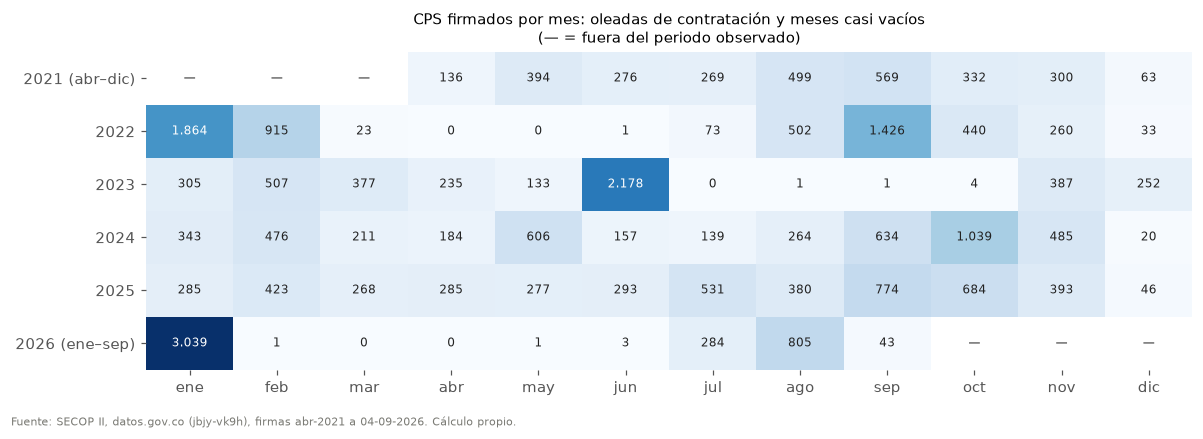

> **Qué no significa:** Firmar en tanda no es ilegal ni prueba de nada: puede reflejar la planeación del año o la llegada de recursos. La fecha registrada en SECOP II puede no coincidir con la de suscripción del documento.

<sub>Patrón estadístico · publicable con cautela · universo: CPS de personas naturales, Alcaldía central · límite: Fecha de firma registrada en SECOP II; no se verificó contra el documento físico. · tabla: p14_la_contratacion_llega_en_oleadas_y_en_po.csv</sub>

### ¿Qué pasó con la contratación antes de la Ley de Garantías de 2026?

**2026: contratar antes de la veda y luego prorrogar.** Entre el 1 de enero y el 30 de enero de 2026 la Alcaldía firmó 3.039 CPS; 1.135 de ellos en los 10 días previos a la prohibición, 189 en sábado o domingo. Durante la prohibición (31 de enero de 2026 a 21 de junio de 2026) SECOP registra 2 CPS. El 42 % de los CPS de enero se prorrogó: el 98 % de esos contratos terminaba antes del fin de la veda y, con la prórroga, el 75 % quedó terminando en la última quincena de la veda o después. Según Colombia Compra Eficiente (Circular 006), la prohibición no cobija las prórrogas y adiciones de contratos vigentes.

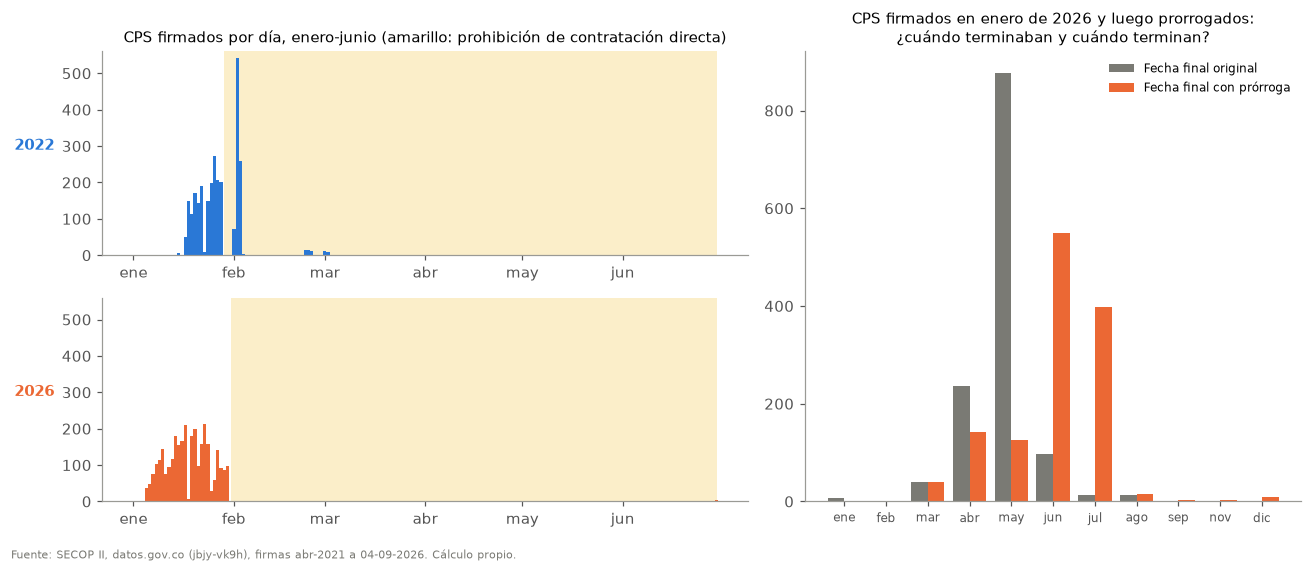

> **Qué no significa:** No prueba una irregularidad. Si alguna prórroga se usó para eludir la restricción, solo lo muestran los expedientes. El dato muestra que el ritmo de firmas coincide con el calendario electoral, no por qué.

<sub>Patrón estadístico · publicable con cautela · universo: CPS de personas naturales, Alcaldía central · límite: La fecha final original se estima restando los días adicionados; los contratos de 2026 siguen en ejecución. · tabla: p15_2026_contratar_antes_de_la_veda_y_luego.csv</sub>

### ¿Se firmaron CPS durante los periodos de prohibición de la Ley de Garantías?

**CPS con fecha de firma dentro de los periodos de prohibición.** El artículo 33 de la Ley 996 de 2005 prohíbe la contratación directa en los cuatro meses previos a la elección presidencial. Con fecha de firma entre el 29 de enero de 2022 y el 19 de junio de 2022, SECOP II registra 938 CPS de la Alcaldía central: 874 en la primera semana y 24 después del primer mes. En el periodo equivalente de 2026 (31 de enero de 2026 a 21 de junio de 2026) registra 2. El cuaderno 05 cuenta 939 y 2 (incluye CPS sin identidad apta).

> **Qué no significa:** No es una conclusión legal. La ley exceptúa, entre otros, lo relacionado con defensa y seguridad del Estado, crédito público, emergencias educativas, sanitarias y desastres, y la contratación de entidades sanitarias y hospitalarias; además, la fecha de firma de SECOP II puede no ser la de suscripción. Si hubo infracción solo lo dicen los expedientes.

<sub>Dato descriptivo · publicable con cautela · universo: CPS de personas naturales, Alcaldía central · límite: Conteo por fecha de firma registrada; la legalidad de cada contrato requiere su expediente. · tabla: p16_cps_con_fecha_de_firma_dentro_de_los_per.csv</sub>

### ¿Qué pasó antes de las elecciones locales de 2023?

**Junio de 2023: la tanda antes de las elecciones locales.** En los 30 días previos al 29 de junio de 2023 (inicio de las restricciones territoriales por las elecciones del 29 de octubre de 2023) la Alcaldía firmó 2.187 CPS (en las mismas fechas de 2024 y 2025, 324 en promedio), 336 de ellos en sábado o domingo. Su duración mediana fue de 5,0 meses y el 48 % termina en diciembre de 2023, el último mes del gobierno. Las personas con CPS vigente pasaron de 1.178 un mes antes a 2.737 el 28 de julio de 2023 (P07). Durante las restricciones territoriales (29 de junio de 2023 a 29 de octubre de 2023) se firmaron apenas 5 CPS, aunque esas restricciones no prohíben contratar CPS.

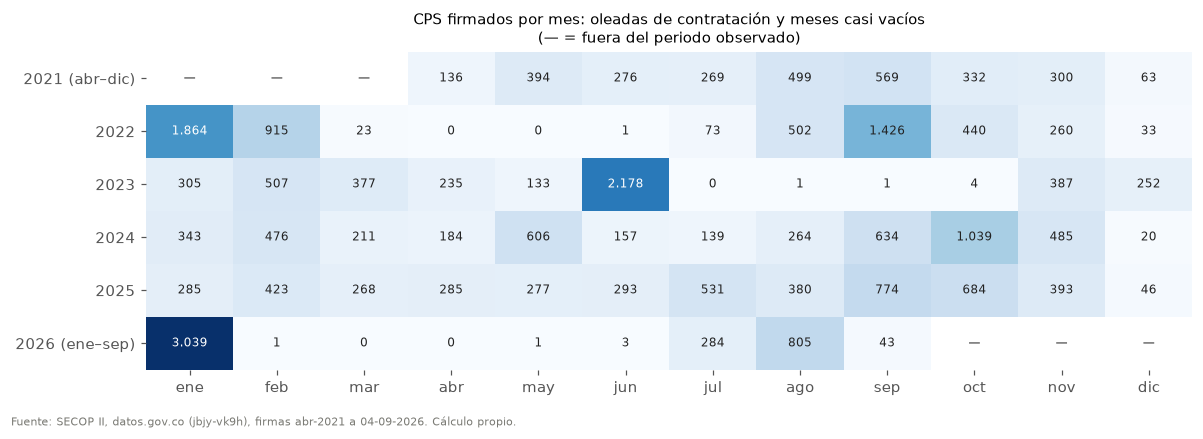

> **Qué no significa:** Las restricciones territoriales no prohíben contratar CPS; no hay base para afirmar uso electoral. Es una coincidencia de calendario que merece explicación de la administración.

<sub>Patrón estadístico · publicable con cautela · universo: CPS de personas naturales, Alcaldía central · límite: Sin expedientes no se conoce el motivo de la tanda (presupuesto, proyectos, vigencias). · tabla: p17_junio_de_2023_la_tanda_antes_de_las_elec.csv</sub>

### ¿Se firmaron contratos interadministrativos durante la restricción de 2025–2026?

**Contratos interadministrativos con fecha de firma dentro de la restricción del artículo 38.** El parágrafo del artículo 38 de la Ley 996 prohíbe a los alcaldes celebrar convenios interadministrativos para ejecutar recursos en los cuatro meses previos a las elecciones; en este ciclo, del 8 de noviembre de 2025 al 21 de junio de 2026. Con fecha de firma en ese periodo, SECOP II registra 6 contratos o convenios interadministrativos de la Alcaldía central (del 26 de diciembre de 2025 al 30 de enero de 2026), por 15,5 miles de millones de pesos corrientes. Después de la restricción y hasta el corte se firmaron 5 más.

> **Qué no significa:** No es una conclusión legal: la prohibición recae sobre convenios que ejecutan recursos, hay discusión jurídica sobre los contratos interadministrativos y la categoría de SECOP II no basta para clasificarlos. Solo el expediente lo aclara.

<sub>Dato descriptivo · publicable con cautela · universo: Contratos válidos de la Alcaldía central con justificación interadministrativa · límite: Conteo por fecha de firma registrada; requiere expediente y concepto jurídico de cada contrato. · tabla: p18_contratos_interadministrativos_con_fecha.csv</sub>

### Con el cambio de gobierno, ¿quién siguió?

**El nuevo gobierno volvió a contratar a 4 de cada 10 contratistas del anterior.** Al final del gobierno anterior (oct–dic 2023) 2.709 personas tenían CPS vigente. El nuevo gobierno volvió a contratar al 40 % hasta el corte, pero solo al 16 % en el primer trimestre de 2024. Quienes regresaron pasaron una mediana de 160 días sin contrato. En 2024, el 44 % de las personas contratadas venía del gobierno anterior. En total, 1.579 personas tuvieron CPS con ambos gobiernos.

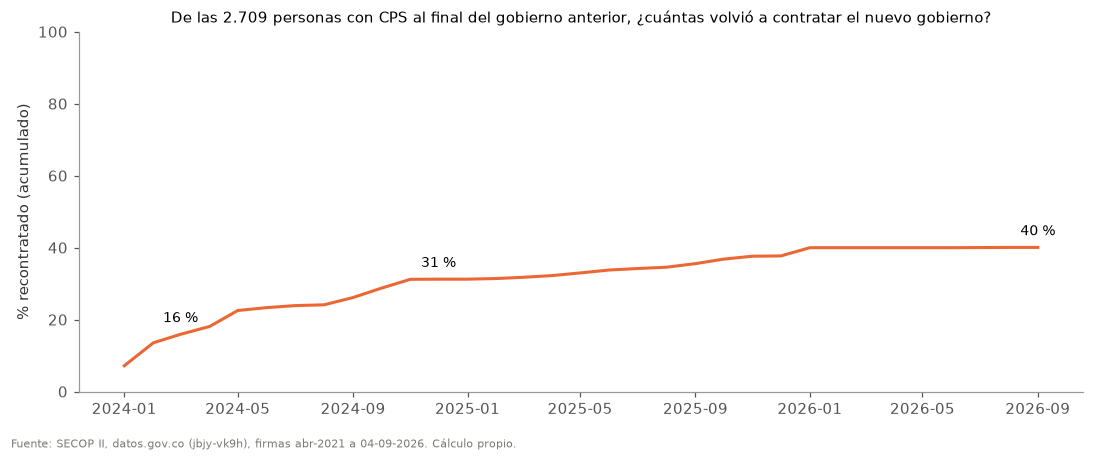

> **Qué no significa:** No mide despidos (un CPS termina en su fecha) ni persecución o favoritismo: el nuevo gobierno puede tener otros programas y necesidades.

<sub>Patrón estadístico · publicable con cautela · universo: CPS de personas naturales, Alcaldía central, vigencia 1–366 días · límite: Solo ve la Alcaldía central: una persona pudo pasar a otra entidad. · tabla: p19_el_nuevo_gobierno_volvio_a_contratar_a_4.csv</sub>

### ¿Cuántos son nuevos cada año y cuántos siguen?

**Dentro de un gobierno la mayoría repite; en el cambio, la mayoría no.** Dentro de un mismo gobierno, entre el 57 % y el 79 % de las personas con CPS en un año vuelve a tener CPS al año siguiente. En el paso 2023→2024 repitió el 30 %. Visto desde el otro lado: en 2024 el 66 % de las personas contratadas no había tenido CPS el año anterior, frente a entre 34 % y 49 % en los demás años completos.

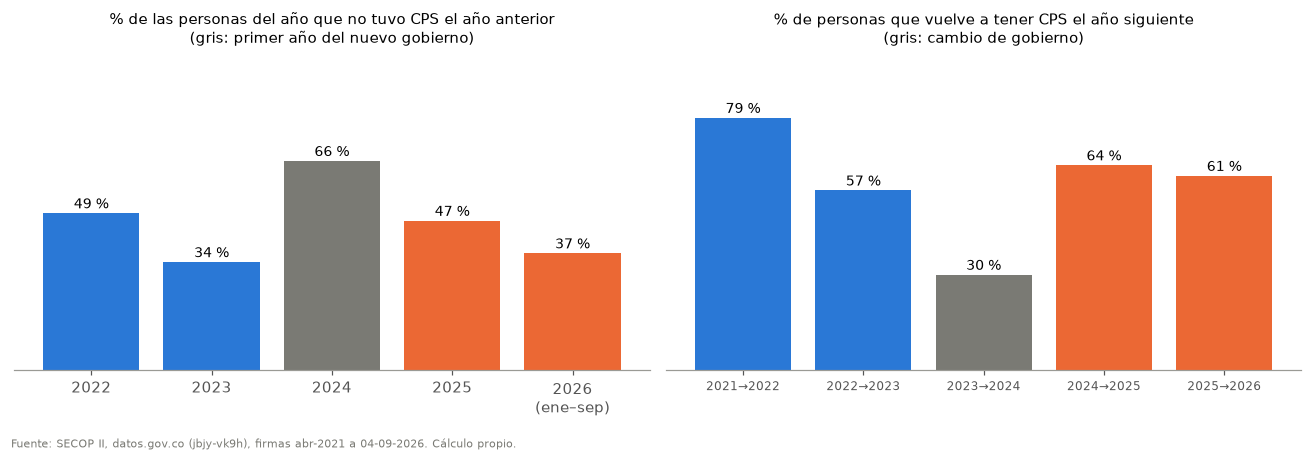

> **Qué no significa:** Repetir no es favoritismo ni salir es despido. Quien no aparece pudo contratar con otra entidad o en SECOP I.

<sub>Patrón estadístico · publicable con cautela · universo: CPS de personas naturales, Alcaldía central · límite: 2021 empieza en abril y 2026 es parcial: el paso 2025→2026 es un mínimo. · tabla: p20_dentro_de_un_gobierno_la_mayoria_repite.csv</sub>

## Acto 6 · Más allá de las personas

Dónde se contrata y en qué se va el resto del dinero: dependencias, obras y convenios.

### ¿Qué dependencias contratan más CPS?

**Qué dependencias contratan y cómo cambió.** Donde el objeto del contrato nombra la dependencia (36–63 % de los CPS según el año), las que más CPS concentran en el gobierno actual son Educación, Interior, Seguridad y convivencia. Frente al gobierno anterior, las que más ganaron participación son Seguridad y convivencia (+6,8 puntos) y Infraestructura (+3,2); las que más perdieron, Interior (-5,2) y Talento humano (-4,3). Algunas dependencias dejan de aparecer en 2026, lo que sugiere cambios de nombre o de estructura administrativa.

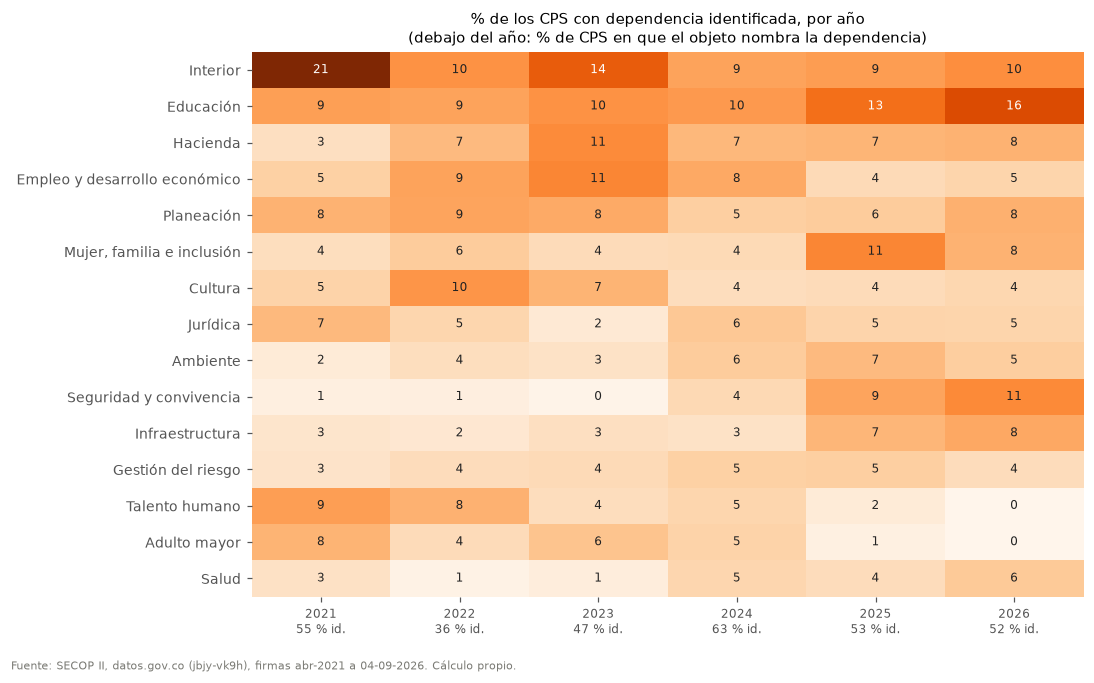

> **Qué no significa:** Solo describe los contratos cuyo objeto nombra la dependencia; el resto no se asigna. No muestra el presupuesto de cada secretaría.

<sub>Patrón estadístico · publicable con cautela · universo: CPS de personas naturales, Alcaldía central, con dependencia en el objeto · límite: Extracción por texto; la cobertura cambia por año y puede sesgar las participaciones. · tabla: p21_que_dependencias_contratan_y_como_cambio.csv</sub>

### ¿En qué años se firma la obra pública?

**La obra pública se firmó sobre todo al final del gobierno anterior.** El valor firmado en contratos de obra fue de 71,5 miles de millones en 2022 y 198,4 en 2023, el último año del gobierno anterior; en 2024, primer año del nuevo gobierno, 3,2, y en 2025 18,2 (pesos constantes). La interventoría sigue el mismo ciclo. Coincide con lo que se espera del ciclo de un gobierno local (planear al comienzo, contratar obra al final), pero con un solo periodo por lado no se puede generalizar.

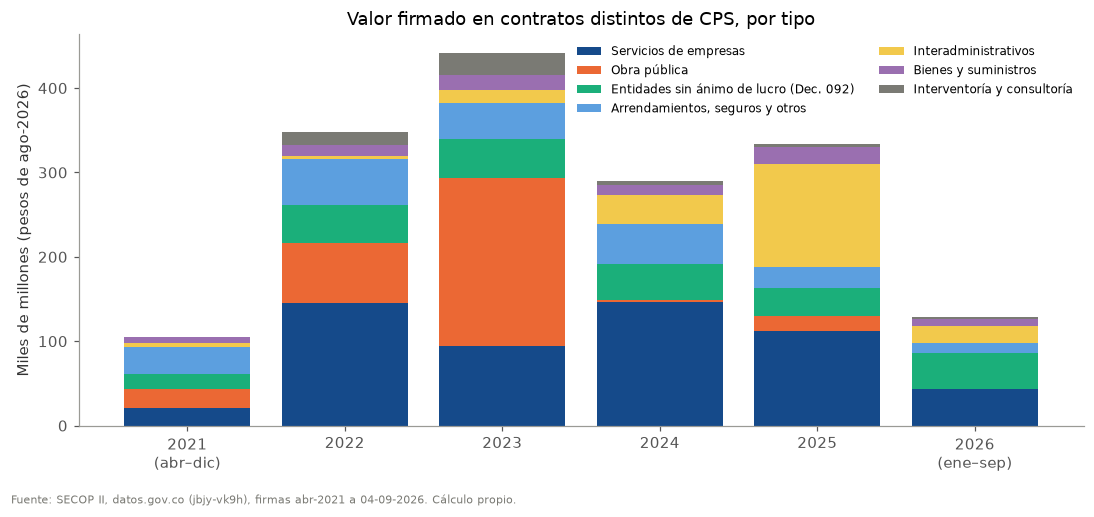

> **Qué no significa:** No mide obra terminada ni pagada, y una sola licitación grande mueve el año. No indica uso electoral.

<sub>Patrón estadístico · publicable con cautela · universo: Contratos válidos de la Alcaldía central distintos de CPS · límite: Valor firmado; un periodo de gobierno por lado (no permite generalizar). 2026 es parcial. · tabla: p22_la_obra_publica_se_firmo_sobre_todo_al_f.csv</sub>

### ¿Cómo contrata la Alcaldía lo que no son personas?

**Más contratación directa con entidades públicas.** En los contratos distintos de CPS, la contratación directa pesó 6 % del valor en 2022 y 11 % en 2023, y subió a 41 % en 2025. El aumento viene sobre todo de contratos y convenios interadministrativos (36 % del valor en 2025), firmados con entidades y empresas públicas. Entre las empresas y consorcios, los 10 proveedores con más valor reúnen el 39 % del total desde abril de 2021 y los consorcios o uniones temporales, el 34 %.

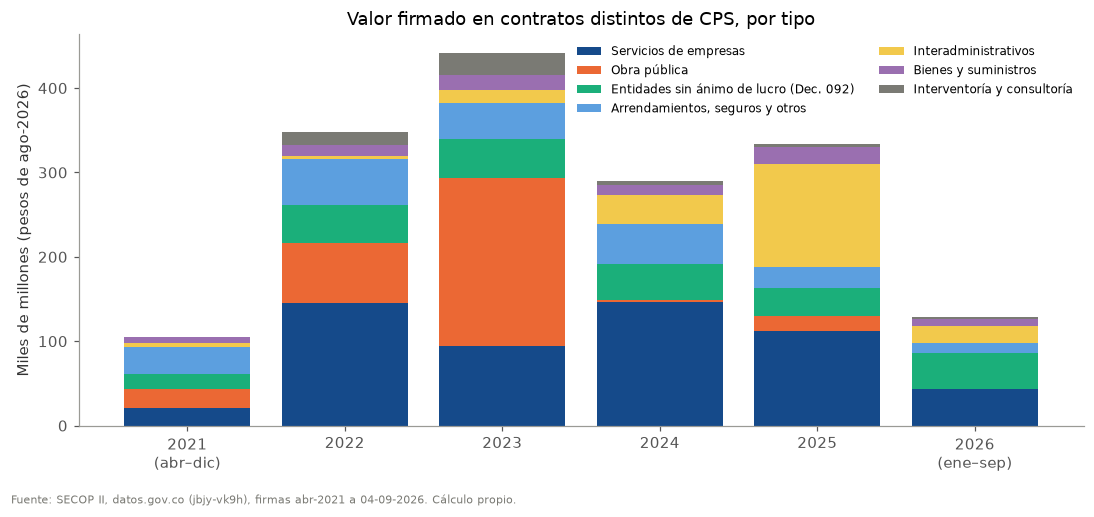

> **Qué no significa:** Contratar directamente con otra entidad pública es legal. No se evalúa si cada contrato cumplió los requisitos.

<sub>Dato descriptivo · publicable con cautela · universo: Contratos válidos de la Alcaldía central distintos de CPS · límite: SECOP llama 'valor cero' a una categoría de interadministrativos que sí tiene valor; se usa la justificación registrada. · tabla: p23_mas_contratacion_directa_con_entidades_p.csv</sub>

## Acto 7 · Lo que no salta a la vista

Hallazgos que solo aparecen al seguir a las personas año tras año, y los límites de los datos.

### ¿Cuántos contratos firma una persona en un año?

**Un año, uno o dos contratos.** En los años completos, entre 48 % y 63 % de las personas firmó un solo CPS en el año, y entre 3 % y 15 % firmó tres o más. Un CPS empieza típicamente 2 a 3 días después de firmado. Hubo entre 54 y 315 contratos de menos de un mes por año, y SECOP registra 1 CPS con inicio anterior a la firma (posible error de registro).

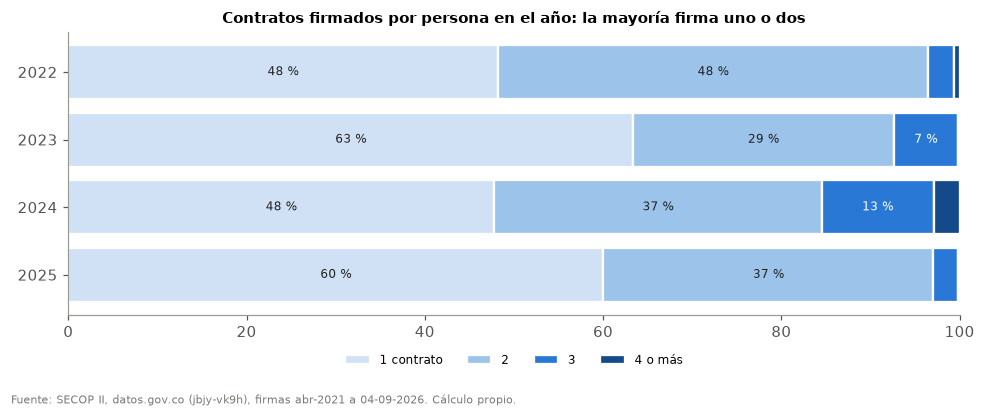

> **Qué no significa:** Firmar varios contratos en un año no es irregular; tampoco lo es un contrato de menos de un mes.

<sub>Dato descriptivo · publicable · universo: CPS de personas, Alcaldía central, años completos · límite: Fechas registradas en SECOP II. · tabla: p24_un_ano_uno_o_dos_contratos.csv</sub>

### ¿Hay un núcleo de personas que siempre está?

**Un núcleo pequeño atraviesa los dos gobiernos.** De las 3.548 personas con CPS en 2022, 525 (15 %) firmaron al menos un CPS en cada año hasta 2025, cruzando el cambio de gobierno. 285 personas tuvieron CPS en todos los años observados, de 2021 a 2026.

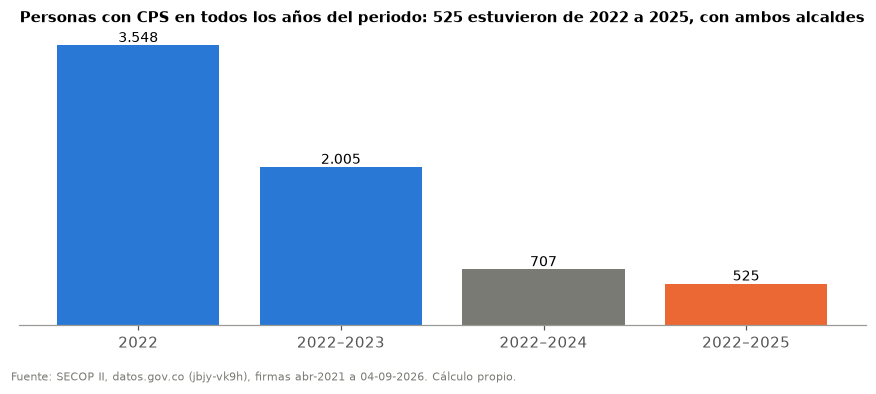

> **Qué no significa:** Estar en todos los años no es favoritismo: puede reflejar experiencia o servicios permanentes. Tampoco es un empleo de planta.

<sub>Dato descriptivo · publicable · universo: CPS de personas, Alcaldía central · límite: Solo ve la Alcaldía central. · tabla: p25_un_nucleo_pequeno_atraviesa_los_dos_gobi.csv</sub>

### ¿De dónde salen estos datos y qué tan completos son?

**Datos públicos con huecos conocidos.** SECOP I tiene 765 registros de la Alcaldía firmados en 2021: 734 entre enero y marzo y solo 31 de abril en adelante. Eso confirma que la Alcaldía pasó a SECOP II en abril de 2021 y que el análisis debe empezar ahí. La lista de otras entidades de la ciudad en SECOP II no se pudo consultar en esta ejecución. El valor pagado aparece en 94 % de los CPS de 2022 pero en 60 % de los de 2026, que siguen en ejecución: por eso se usa el valor pactado. La clasificación profesional / apoyo a la gestión sale del objeto del contrato; cuando el objeto dice ambas cosas se usa la profesión u oficio nombrado (ingeniero, arquitecto, técnico, auxiliar…). Donde la etiqueta literal y la profesión existen a la vez, coinciden en el 98 % o más de los casos. Quedó ambiguo entre el 0,2 % y el 1,0 % de los CPS según el año.

> **Qué no significa:** La base no es un registro de nómina ni de pagos. El estado 'terminado' de SECOP depende de la antigüedad del contrato, no de cómo terminó.

<sub>Dato descriptivo · publicable · universo: Corrida congelada de SECOP II y verificaciones del 01 · límite: Las verificaciones externas dependen de la conexión al ejecutar el 01. · tabla: p26_datos_publicos_con_huecos_conocidos.csv</sub>

## Preguntas que solo los expedientes pueden responder

Los datos muestran situaciones que merecen explicación, pero SECOP no basta para concluir. Se publican como preguntas, sin cifras:

1. **¿Con qué excepción legal y en qué fecha real se suscribieron los CPS con fecha de firma dentro de la Ley de Garantías de 2022 (P16)?** Se resuelve con los expedientes: fecha de suscripción física, causal de contratación directa y excepción del art. 33 invocada.
2. **¿Los contratos interadministrativos firmados durante la restricción de 2025–2026 ejecutan recursos, y cómo se ajustan al art. 38 de la Ley 996 (P18)?** Se resuelve con los expedientes, los estudios previos y el concepto jurídico de la Alcaldía.
3. **¿Alguna prórroga de los contratos de enero de 2026 se usó para suplir contratación nueva durante la restricción (P15)?** Se resuelve con los estudios previos de cada prórroga y su justificación.
4. **¿Cuáles son los valores mensuales más altos?** Por qué aún no se concluye: Un extremo puede ser error de registro, objeto distinto o forma de pago; revisar expediente antes de nombrar.
5. **¿Hay personas con CPS simultáneos en varias entidades?** Por qué aún no se concluye: No prueba incompatibilidad: la simultaneidad formal no dice nada de horarios ni de dedicación; requiere expedientes.
6. **¿Qué pasa con los contratos de personas en la ESE?** Por qué aún no se concluye: No se confirman como CPS ni se suman a la Alcaldía; la ESE aparece en SECOP II desde jul-2022.

## Prueba de estrés: ¿se caen las conclusiones?

Cada conclusión principal se recalculó con supuestos alternativos. Esto es lo que pasa:

| Indicador | Resultado | Si se cambia a… | Resultado alternativo | ¿Se mantiene? |
|---|---|---|---|---|
| % personas con 7+ meses de contrato (2023 / 2025) | 39 % / 28 % | Sin los días de prórroga | 37 % / 26 % | Se mantiene: 2023 por encima de 2025 |
| Espera mediana entre contratos (días) | 47 | Seguimiento de 180 días | 36 | Cambia con el seguimiento: se publica el de 365 días, igual para todos |
| Diferencia entre gobiernos en % renovado antes de 90 días | no se publica | Rango entre años de terminación | 40 % a 75 % | No se compara a los gobiernos: el año pesa más que el gobierno |
| Mediana real profesional 2021 → 2026 (millones) | 5,11 → 4,23 | Solo contratos de 90 días o más | 5,11 → 4,23 | Se mantiene: erosión real con el tiempo |
| Cambio de la mediana real de apoyo 2021 → 2026 | -9,7 % | Contando los ambiguos como apoyo | -9,7 % | Se mantiene la dirección |
| Cambio real mediano, misma persona profesional | +0,7 % | Misma persona, ene–ago 2022 vs 2026 (cuaderno 04) | -12,6 % | Cambia según el diseño: no se atribuye a un gobierno |
| % de contratistas de la Alcaldía con CPS en otra entidad | 15 % | Sumando registros por revisar de la ESE | 19 % | Se mantiene el orden de magnitud |
| % de personas de 2023 que siguen en 2024 | 30 % | CPS en cualquiera de las nueve entidades | 33 % | Se mantiene: muy por debajo de la continuidad dentro de un gobierno (≥57 %) |
| Obra 2023 vs 2024 (miles de millones reales) | 198,4 vs 3,2 | Sin el contrato de obra más grande de cada año | 167,1 vs 1,8 | Se mantiene: 2023 muy por encima de 2024 |
| Cambio en personas con CPS, año 3 | +10,8 % | Rango en las tres ventanas del cuaderno 04 | +10,8 % a +26,5 % | Se mantiene la dirección; se publica el rango, no una cifra |
| Cambio en CPS firmados, año 3 | +22,4 % | Rango en las tres ventanas del cuaderno 04 | +22,4 % a +25,4 % | Se mantiene la dirección; se publica el rango, no una cifra |

## Lo que estos datos no permiten afirmar

- Que las tandas de firma o las prórrogas antes de elecciones tengan fines electorales: SECOP muestra fechas, no intenciones.
- Que quien no fue recontratado haya sido despedido o perseguido, o que quien repite sea favorecido.
- Que la caída de los honorarios reales sea decisión de un gobierno: empezó antes del cambio y la clasificación de subtipo no está validada.
- Que el valor mensual equivalente sea un salario o que la vigencia del contrato sean días trabajados.
- Que el Concejo, la Personería, la Contraloría o el Hospital Regional contraten por cuenta del alcalde.
- El sexo, la edad, la profesión o el barrio de los contratistas: SECOP II no los registra.
- Los CPS son empleos o el valor mensual es un salario: SECOP registra contratos y valores pactados, no pagos ni relación laboral.
- Un gobierno pagó menos a los profesionales: La caída real empieza antes del cambio de gobierno (Q06).
- Un gobierno generó más continuidad o más empleo: Las cifras cambian según la ventana y la etapa del mandato.
- Dos contratos simultáneos prueban ilegalidad: Hay que revisar dedicación, obligaciones y pagos.
- Las firmas en Ley de Garantías fueron ilegales: Puede haber excepciones y diferencias entre firma electrónica y suscripción.
- Recurrencia de personas o empresas prueba favoritismo: Es un patrón descriptivo con explicaciones alternativas.
- El Concejo o los órganos de control son contratación del alcalde: Son entidades autónomas; se analizan separadas.
- ¿Cuánto se espera hasta el siguiente contrato, según el gobierno? — Ventana de 8 meses con Ley de Garantías y censura; el resultado depende del año y no del gobierno.
- ¿Pagó menos Jonathan a los profesionales que Alfonso? — Contrastar ventanas separadas cuatro años confunde tendencia inflacionaria con decisión de gobierno.
- ¿Qué profesiones ofrecen más estabilidad? — Requiere otra fuente (hojas de vida, SIGEP).

## Epílogo · Cómo se hizo esta historia

**1. El origen.** Todo sale de SECOP II, el sistema público donde las entidades colombianas publican sus contratos. Se descargó por la API de datos abiertos (datos.gov.co, conjunto jbjy-vk9h) una sola vez, con corte al 4 de septiembre de 2026, y el archivo se congeló con una huella digital (sha256): nunca se modifica, y cualquiera puede repetir el análisis sobre exactamente los mismos datos.

**2. La limpieza (cuadernos 01 y 02).** Se separaron las nueve entidades por su NIT, se descartaron duplicados y contratos con estados inválidos, se identificó a cada persona por su documento y se distinguieron personas naturales, empresas y consorcios. Las fechas se midieron con duración inclusiva y se comprobó con los propios datos que la fecha final ya incluye las prórrogas.

**3. ¿Qué es un CPS? (cuaderno 03).** Un contrato cuenta como CPS si el tipo, la modalidad y el objeto lo indican y el contratista es una persona natural. El objeto permite separar profesional y apoyo a la gestión; si dice ambas cosas, decide la profesión u oficio nombrado (como arquitecto, como técnico). Esa clasificación coincide con la profesión nombrada en el 98 % de los casos verificables, pero está sin validación manual y trae una plantilla para revisarla a mano.

**4. Comparar con justicia (cuaderno 04).** Los valores se llevan a pesos constantes con el IPC del DANE y los gobiernos se comparan en ventanas de la misma etapa del mandato. Cada comparación se repite en varias ventanas y recibe un dictamen de robustez.

**5. Seguir a las personas (cuaderno 05).** Los contratos de una persona se unen en episodios para medir continuidad, pausas y contratos simultáneos, y se cruzan con los periodos de la Ley de Garantías.

**6. Decidir qué se publica (cuadernos 06 y 07).** Cada hallazgo recibe un estado por reglas: publicable, con cautela, solo la dirección, solo para investigar o no publicable. Esta historia solo cuenta los tres primeros.

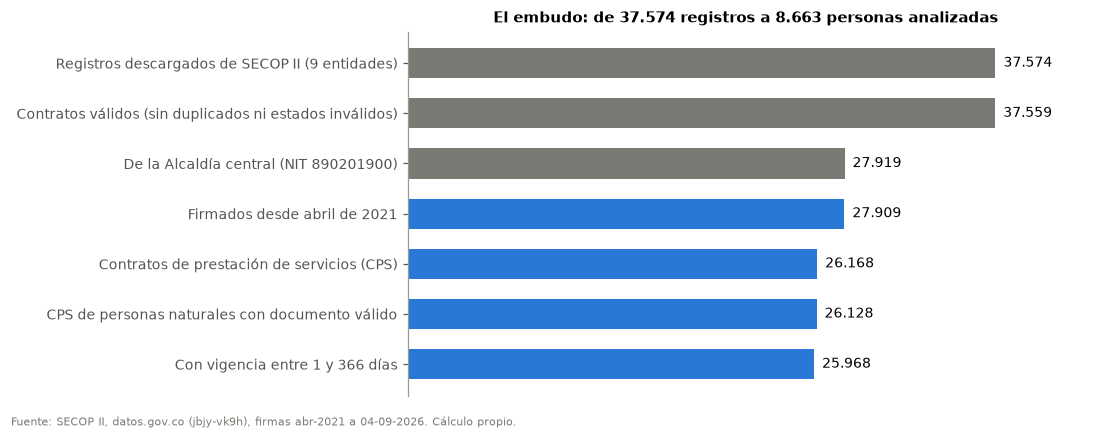

### Las decisiones y por qué

| Decisión | Alternativa descartada | Por qué |
|---|---|---|
| La Alcaldía se identifica por su NIT (890201900) | Filtrar por ciudad | La ciudad mezcla entidades autónomas (Concejo, Contraloría) con la Alcaldía. |
| Cada entidad por separado; nada se suma al alcalde automáticamente | Sumar todo lo de Barrancabermeja | El Concejo y los órganos de control no dependen del alcalde. |
| La persona es su número de documento | Usar el nombre | Los nombres cambian de escritura; el documento no. |
| El análisis empieza en abril de 2021 | Empezar en enero de 2021 | Antes de abril la Alcaldía publicaba en SECOP I: 734 registros de enero a marzo de 2021 y 31 de abril en adelante (verificado en el 01). |
| Comparar alcaldes solo en la ventana principal (ene–ago del año 3) | Comparar gobiernos completos o el año 2 | Es la única ventana en la misma etapa del mandato con cobertura completa en SECOP II. |
| Duración inclusiva (fin − inicio + 1) | Restar fechas sin más | Restar pierde un día por contrato y subestima la cobertura. |
| No sumar los días adicionados a la fecha final | Sumarlos | La prueba del 02 muestra que la fecha final ya los incluye. |
| Pesos constantes con el IPC del DANE | Pesos de cada año | Entre 2021 y 2026 la inflación cambia el poder de compra; se muestran ambas. |
| Seguimiento igual de 365 días para medir renovaciones, por año de terminación | Medir todas las esperas y agrupar por gobierno | El periodo más reciente tiene menos tiempo para mostrar esperas largas (sesgo de censura) y el año electoral pesa más que el gobierno. |
| Publicar conteos con fecha de firma en periodos de Ley de Garantías como dato, no como infracción | Callarlos o presentarlos como ilegales | El conteo es un hecho verificable; la legalidad depende de excepciones y expedientes. |
| Valor pactado, no pagado | Valor pagado | El pagado falta en contratos en ejecución. |
| No imputar datos faltantes | Rellenar con promedios | Rellenar inventa información. |
| Desempatar el subtipo por la profesión u oficio nombrado en el objeto | Dejar ambiguos los objetos que dicen 'profesionales y de apoyo' | El rol nombrado (arquitecto, técnico, auxiliar) es evidencia directa; la regla coincide con la etiqueta literal en más del 98 % de los casos. |
| Estados de publicación por reglas | Publicar todo | Evita convertir una coincidencia en acusación. |

### Las herramientas

Python con pocas librerías, para que cualquiera pueda repetirlo. Cada cuaderno se ejecuta con Run All, verifica las huellas de la etapa anterior y deja un manifiesto con las huellas de lo que produce. Dos ejecuciones completas dan datos, tablas y gráficas idénticos byte a byte; solo cambian la hora y el entorno anotados en los manifiestos.

| Librería | Versión | Para qué |
|---|---|---|
| pandas | 3.0.5 | Leer, limpiar, unir y resumir tablas. |
| numpy | 2.5.3 | Cálculos vectorizados: series diarias, percentiles, Gini. |
| matplotlib | 3.11.1 | Todas las gráficas. |
| openpyxl | (la que tenga instalada) | Leer el anexo del IPC del DANE (cuaderno 04). |
| pathlib, json, hashlib | biblioteca estándar | Rutas relativas, manifiestos y huellas sha256 de cada archivo. |
| urllib | biblioteca estándar | Descarga desde la API de datos.gov.co y verificaciones externas (cuaderno 01). |
| re, unicodedata | biblioteca estándar | Normalizar textos y reconocer tipos de contrato y dependencias. |
| IPython.display | Jupyter | Mostrar tablas, gráficas y texto en el cuaderno. |

### Cómo se contó

La historia sigue técnicas actuales de narrativa con datos: una gran idea en una frase; tres momentos (contexto, tensión y lo que significa); títulos de gráfica que ya dicen la conclusión; una sola cosa resaltada por gráfica; una persona compuesta para volver humanas las medianas; y, por honestidad, un 'qué no significa' en cada hallazgo y una prueba de estrés al final.

## Fuentes

- [SECOP II · Contratos electrónicos (datos.gov.co, jbjy-vk9h)](https://www.datos.gov.co/Gastos-Gubernamentales/SECOP-II-Contratos-Electr-nicos/jbjy-vk9h)
- [DANE · Índice de precios al consumidor (IPC)](https://www.dane.gov.co/index.php/estadisticas-por-tema/precios-y-inflacion/indice-de-precios-al-consumidor-ipc)
- [Ley de Garantías · presidencial_2022](https://www.infobae.com/america/colombia/2022/01/26/ley-de-garantias-entra-en-funcionamiento-este-sabado-29-de-enero-le-explicamos-en-que-consiste/)
- [Ley de Garantías · territorial_2023](https://www.eltiempo.com/politica/gobierno/ley-de-garantias-cuales-son-las-restricciones-por-elecciones-regionales-782201)
- [Ley de Garantías · territorial_art38_2026](https://www.colombiacompra.gov.co/wp-content/uploads/2025/10/Circular-006-ABC-de-Ley-de-Garantias-Dig.pdf)
- [Ley de Garantías · presidencial_2026](https://www.colombiacompra.gov.co/wp-content/uploads/2025/10/Circular-006-ABC-de-Ley-de-Garantias-Dig.pdf)
- [Salario mínimo 2026 · Decreto 1469 de 2025](https://www.alcaldiabogota.gov.co/sisjur//normas/Norma1.jsp?i=191925)
- [Salario mínimo 2026 · Decreto transitorio 0159 de 2026](https://chapmanwilches.com/en/gobierno-nacional-fija-el-salario-minimo-mensual-transitorio-para-2026-en-1-750-905-decreto-0159-de-2026-del-ministerio-del-trabajo/)
- [Registraduría · segunda vuelta presidencial del 21 de junio de 2026](https://www.registraduria.gov.co/Se-cerraron-las-urnas-de-la-segunda-vuelta-de-las-elecciones-presidenciales.html)


In [30]:
ins = pd.DataFrame(INSIGHTS)
PUBLICABLES = {"PUBLICABLE", "PUBLICABLE_CON_CAUTELA", "SOLO_DIRECCION"}
ins["en_historia"] = ins["estado_publicacion"].isin(PUBLICABLES)
pub = ins.loc[ins["en_historia"]].set_index("id")
ACTOS = [
    ("Acto 1 · El tamaño", "Primero, la escala: cuántos contratos, cuántas personas y cuánto dinero maneja cada alcalde."),
    ("Acto 2 · La vida de un contratista", "Detrás de los totales hay personas que encadenan contratos cortos, con pausas entre uno y otro."),
    ("Acto 3 · El dinero en el bolsillo", "Cuánto se pacta al mes, cómo cambia con la inflación y el salario mínimo, y cómo se reparte."),
    ("Acto 4 · Varias puertas", "Muchas personas no solo contratan con la Alcaldía: también con entidades del Distrito o autónomas."),
    ("Acto 5 · El reloj político", "El ritmo de firmas coincide con el calendario del presupuesto y de las elecciones, y en el cambio de gobierno la mayoría de contratistas no siguió."),
    ("Acto 6 · Más allá de las personas", "Dónde se contrata y en qué se va el resto del dinero: dependencias, obras y convenios."),
    ("Acto 7 · Lo que no salta a la vista", "Hallazgos que solo aparecen al seguir a las personas año tras año, y los límites de los datos."),
]
assert set(pub["acto"]) <= {a for a, _ in ACTOS}, set(pub["acto"])
PREGUNTAS = [
    ("¿Con qué excepción legal y en qué fecha real se suscribieron los CPS con fecha de firma dentro de la Ley de Garantías de 2022 (P16)?",
     "Se resuelve con los expedientes: fecha de suscripción física, causal de contratación directa y excepción del art. 33 invocada."),
    ("¿Los contratos interadministrativos firmados durante la restricción de 2025–2026 ejecutan recursos, y cómo se ajustan al art. 38 de la Ley 996 (P18)?",
     "Se resuelve con los expedientes, los estudios previos y el concepto jurídico de la Alcaldía."),
    ("¿Alguna prórroga de los contratos de enero de 2026 se usó para suplir contratación nueva durante la restricción (P15)?",
     "Se resuelve con los estudios previos de cada prórroga y su justificación."),
]
for q in ["Q07", "Q08", "Q11"]:
    if q in cat06.index and cat06.loc[q, "estado_publicacion"] == "SOLO_INVESTIGACION":
        PREGUNTAS.append((cat06.loc[q, "pregunta"], f"Por qué aún no se concluye: {cat06.loc[q, 'limitacion']}"))
NO_AFIRMAR = [
    "Que las tandas de firma o las prórrogas antes de elecciones tengan fines electorales: SECOP muestra fechas, no intenciones.",
    "Que quien no fue recontratado haya sido despedido o perseguido, o que quien repite sea favorecido.",
    "Que la caída de los honorarios reales sea decisión de un gobierno: empezó antes del cambio y la clasificación de subtipo no está validada.",
    "Que el valor mensual equivalente sea un salario o que la vigencia del contrato sean días trabajados.",
    "Que el Concejo, la Personería, la Contraloría o el Hospital Regional contraten por cuenta del alcalde.",
    "El sexo, la edad, la profesión o el barrio de los contratistas: SECOP II no los registra.",
] + [f"{r.afirmacion}: {r.razon}" for r in no_sost06.itertuples()] + \
    [f"{f['pregunta']} — {f['limitacion']}" for _, f in cat06.loc[cat06["estado_publicacion"].eq("NO_PUBLICABLE")].iterrows()]
KPIS = [
    (es(f"{len(cps):,}"), "CPS con personas firmados desde abril de 2021"),
    (es(f"{cps[PERSONA].nunique():,}"), "personas distintas contratadas"),
    (f"{t01['pct_contratos_cps'].median():.0f} % / {t01['pct_valor_cps'].median():.0f} %", "de los contratos / del valor son CPS (mediana anual)"),
    (es(f"{tot6['mediana_dias_espera']:.0f} días"), "espera típica entre un contrato y el siguiente (mediana)"),
    (f"{p4['pct_7_meses_o_mas'].min():.0f}–{p4['pct_7_meses_o_mas'].max():.0f} %", "de las personas suma 7 meses o más de contrato al año"),
    (es(f"{nucleo:,}"), f"personas con CPS todos los años de {anios_nucleo[0]} a {anios_nucleo[-1]}"),
]
FUENTES = [
    ("SECOP II · Contratos electrónicos (datos.gov.co, jbjy-vk9h)", "https://www.datos.gov.co/Gastos-Gubernamentales/SECOP-II-Contratos-Electr-nicos/jbjy-vk9h"),
    ("DANE · Índice de precios al consumidor (IPC)", "https://www.dane.gov.co/index.php/estadisticas-por-tema/precios-y-inflacion/indice-de-precios-al-consumidor-ipc"),
] + [(f"Ley de Garantías · {r.periodo}", u.strip()) for r in restr.itertuples() for u in str(r.fuente_url).split(";")][:4] + [
    ("Salario mínimo 2026 · Decreto 1469 de 2025", "https://www.alcaldiabogota.gov.co/sisjur//normas/Norma1.jsp?i=191925"),
    ("Salario mínimo 2026 · Decreto transitorio 0159 de 2026", "https://chapmanwilches.com/en/gobierno-nacional-fija-el-salario-minimo-mensual-transitorio-para-2026-en-1-750-905-decreto-0159-de-2026-del-ministerio-del-trabajo/"),
    ("Registraduría · segunda vuelta presidencial del 21 de junio de 2026", "https://www.registraduria.gov.co/Se-cerraron-las-urnas-de-la-segunda-vuelta-de-las-elecciones-presidenciales.html")]

bloques = []


N_ARGS = {"h1": 1, "h2": 1, "h3": 1, "dek": 1, "p": 1, "callout": 2, "quote": 1, "note": 2, "small": 1, "ul": 1, "ol": 1,
          "img": 2, "kpis": 1, "table": 1}


def B(tipo, *args):
    # Cada bloque recibe un número fijo de argumentos: si alguien separa un texto con comas, falla aquí en vez de cortarlo
    if N_ARGS.get(tipo) != len(args):
        raise ValueError(f"Bloque '{tipo}' espera {N_ARGS.get(tipo)} argumentos y recibió {len(args)}")
    bloques.append((tipo, *args))


B("h1", "¿Cómo contrata la Alcaldía de Barrancabermeja?")
B("dek", f"Lo que muestran los contratos publicados en SECOP II entre abril de 2021 y el {fecha_es(CORTE)}, contado de lo general a lo particular.")
B("callout", "La gran idea", f"La Alcaldía contrata a miles de personas con contratos cortos que se firman en oleadas que coinciden con el "
  f"calendario del presupuesto y de las elecciones. Las personas encadenan contratos con pausas de semanas entre uno y otro, y con el cambio de gobierno "
  f"{10 - round(pct_recon / 10)} de cada 10 contratistas no volvieron a tener CPS con la Alcaldía.")
B("kpis", KPIS)
B("h2", "Conozca a Ana, la contratista típica")
B("quote", RETRATO)
B("p", es(f"Esta historia recorre {len(central):,} contratos de la Alcaldía central (NIT 890201900), {len(cps):,} de ellos contratos de "
          f"prestación de servicios (CPS) con {cps[PERSONA].nunique():,} personas, durante el final del gobierno de Alfonso Eljach (desde abril de 2021) "
          f"y el de Jonathan Vásquez (desde enero de 2024). No describe empleos de planta, salarios ni pagos: describe lo que se pactó al firmar. "
          f"Ninguna persona contratista se identifica."))
B("ul", ["**Dato descriptivo:** conteo o suma de un universo validado.",
         "**Patrón estadístico:** regularidad que se repite en el tiempo o entre grupos.",
         "**Anomalía que requiere documentos:** algo que SECOP muestra pero solo un expediente explica; aquí va como pregunta.",
         "**Qué no significa:** cada hallazgo dice qué conclusión no se puede sacar de él."])
for acto, intro in ACTOS:
    ids = [i for i in pub.index if pub.loc[i, "acto"] == acto]
    if not ids:
        continue
    B("h2", acto)
    B("p", intro)
    for i in ids:
        f = pub.loc[i]
        B("h3", f"{f['pregunta']}")
        B("p", f"**{f['titulo']}.** {f['texto']}")
        for g in [x for x in str(f["grafico"]).split(";") if x]:
            B("img", RAIZ / g, f["titulo"])
        B("note", "Qué no significa", f["no_significa"])
        B("small", f"{f['nivel']} · {f['estado_publicacion'].replace('_', ' ').lower()} · universo: {f['universo']} · "
                   f"límite: {f['limitacion']} · tabla: {Path(f['tabla']).name}")
B("h2", "Preguntas que solo los expedientes pueden responder")
B("p", "Los datos muestran situaciones que merecen explicación, pero SECOP no basta para concluir. Se publican como preguntas, sin cifras:")
B("ol", [f"**{p}** {d}" for p, d in PREGUNTAS])
B("h2", "Prueba de estrés: ¿se caen las conclusiones?")
B("p", "Cada conclusión principal se recalculó con supuestos alternativos. Esto es lo que pasa:")
B("table", t_estres[["indicador", "valor_base", "supuesto_alternativo", "valor_alternativo", "conclusion"]].rename(columns={
    "indicador": "Indicador", "valor_base": "Resultado", "supuesto_alternativo": "Si se cambia a…", "valor_alternativo": "Resultado alternativo",
    "conclusion": "¿Se mantiene?"}))
B("h2", "Lo que estos datos no permiten afirmar")
B("ul", NO_AFIRMAR)
B("h2", "Epílogo · Cómo se hizo esta historia")
B("p", "**1. El origen.** Todo sale de SECOP II, el sistema público donde las entidades colombianas publican sus contratos. Se descargó por la "
       f"API de datos abiertos (datos.gov.co, conjunto jbjy-vk9h) una sola vez, con corte al {fecha_es(CORTE)}, y el archivo se congeló con una "
       "huella digital (sha256): nunca se modifica, y cualquiera puede repetir el análisis sobre exactamente los mismos datos.")
B("p", "**2. La limpieza (cuadernos 01 y 02).** Se separaron las nueve entidades por su NIT, se descartaron duplicados y contratos con estados "
       "inválidos, se identificó a cada persona por su documento y se distinguieron personas naturales, empresas y consorcios. Las fechas se "
       "midieron con duración inclusiva y se comprobó con los propios datos que la fecha final ya incluye las prórrogas.")
B("p", "**3. ¿Qué es un CPS? (cuaderno 03).** Un contrato cuenta como CPS si el tipo, la modalidad y el objeto lo indican y el contratista es una "
       f"persona natural. El objeto permite separar profesional y apoyo a la gestión; si dice ambas cosas, decide la profesión u oficio "
       f"nombrado (como arquitecto, como técnico). Esa clasificación coincide con la profesión nombrada en el {conc03['concordancia_pct'].min():.0f} % "
       f"de los casos verificables, pero está {'sin validación manual' if VALIDACION == 'SIN_VALIDACION_MANUAL' else VALIDACION.replace('_', ' ').lower()} "
       "y trae una plantilla para revisarla a mano.")
B("p", "**4. Comparar con justicia (cuaderno 04).** Los valores se llevan a pesos constantes con el IPC del DANE y los gobiernos se comparan en "
       "ventanas de la misma etapa del mandato. Cada comparación se repite en varias ventanas y recibe un dictamen de robustez.")
B("p", "**5. Seguir a las personas (cuaderno 05).** Los contratos de una persona se unen en episodios para medir continuidad, pausas y "
       "contratos simultáneos, y se cruzan con los periodos de la Ley de Garantías.")
B("p", "**6. Decidir qué se publica (cuadernos 06 y 07).** Cada hallazgo recibe un estado por reglas: publicable, con cautela, solo la "
       "dirección, solo para investigar o no publicable. Esta historia solo cuenta los tres primeros.")
B("img", g_embudo, "El embudo del dato")
B("h3", "Las decisiones y por qué")
B("table", DECISIONES.rename(columns={"decision": "Decisión", "alternativa_descartada": "Alternativa descartada", "por_que": "Por qué"}))
B("h3", "Las herramientas")
B("p", "Python con pocas librerías, para que cualquiera pueda repetirlo. Cada cuaderno se ejecuta con Run All, verifica las huellas de la etapa "
       "anterior y deja un manifiesto con las huellas de lo que produce. Dos ejecuciones completas dan datos, tablas y gráficas idénticos byte a byte; "
       "solo cambian la hora y el entorno anotados en los manifiestos.")
B("table", LIBRERIAS.rename(columns={"libreria": "Librería", "version": "Versión", "para_que": "Para qué"}))
B("h3", "Cómo se contó")
B("p", "La historia sigue técnicas actuales de narrativa con datos: una gran idea en una frase; tres momentos (contexto, tensión y lo que "
       "significa); títulos de gráfica que ya dicen la conclusión; una sola cosa resaltada por gráfica; una persona compuesta para volver "
       "humanas las medianas; y, por honestidad, un 'qué no significa' en cada hallazgo y una prueba de estrés al final.")
B("h2", "Fuentes")
B("ul", [f"[{t}]({u})" for t, u in FUENTES])


def md_inline(t):
    return str(t)


def html_inline(t):
    t = html.escape(str(t))
    t = re.sub(r"\[([^\]]+)\]\((https?://[^)]+)\)", r'<a href="\2">\1</a>', t)
    t = re.sub(r"\*\*(.+?)\*\*", r"<strong>\1</strong>", t)
    return re.sub(r"`(.+?)`", r"<code>\1</code>", t)


def tabla_md(df):
    cab = "| " + " | ".join(df.columns) + " |\n|" + "---|" * len(df.columns)
    return cab + "\n" + "\n".join("| " + " | ".join(str(v).replace("|", "/") for v in fila) + " |" for fila in df.itertuples(index=False))


def render_md(bl, incrustar=False):
    # incrustar=True pone las imágenes dentro del texto (para verlas en el cuaderno desde cualquier carpeta)
    out = []
    for t, *a in bl:
        if t == "h1": out.append(f"# {a[0]}")
        elif t == "h2": out.append(f"## {a[0]}")
        elif t == "h3": out.append(f"### {a[0]}")
        elif t == "dek": out.append(f"*{a[0]}*")
        elif t == "p": out.append(a[0])
        elif t == "callout": out.append(f"> **{a[0]}.** {a[1]}")
        elif t == "quote": out.append(f"> {a[0]}")
        elif t == "note": out.append(f"> **{a[0]}:** {a[1]}")
        elif t == "small": out.append(f"<sub>{a[0]}</sub>")
        elif t == "ul": out.append("\n".join(f"- {x}" for x in a[0]))
        elif t == "ol": out.append("\n".join(f"{k}. {x}" for k, x in enumerate(a[0], 1)))
        elif t == "img":
            if incrustar:
                out.append(f"![{a[1]}](data:image/png;base64,{base64.b64encode(Path(a[0]).read_bytes()).decode('ascii')})")
            else:
                out.append(f"![{a[1]}](graficos/{Path(a[0]).name})")
        elif t == "kpis": out.append("\n".join(f"- **{v}** {e}" for v, e in a[0]))
        elif t == "table": out.append(tabla_md(a[0]))
    return "\n\n".join(out) + "\n"


CSS = """
:root{--ink:#1d1d1b;--ink2:#55554f;--muted:#8a8a84;--bg:#fbfbf9;--card:#ffffff;--line:#e4e3de;--azul:#2a78d6;--naranja:#eb6834}
*{box-sizing:border-box}body{margin:0;background:var(--bg);color:var(--ink);font:17px/1.6 Georgia,'Iowan Old Style',serif}
main{max-width:860px;margin:0 auto;padding:40px 18px 80px}h1,h2,h3,.kpi b,small,table,.dek{font-family:system-ui,-apple-system,'Segoe UI',sans-serif}
h1{font-size:2.1rem;line-height:1.15;margin:0 0 .4rem}.dek{color:var(--ink2);font-size:1.1rem;margin:0 0 1.6rem}
h2{font-size:1.45rem;margin:3rem 0 .6rem;padding-top:1rem;border-top:3px solid var(--ink)}h3{font-size:1.1rem;margin:2rem 0 .4rem;color:var(--azul)}
p{margin:.6rem 0}img{max-width:100%;height:auto;display:block;margin:1rem auto;border:1px solid var(--line);border-radius:6px;background:#fff}
.callout{background:var(--card);border-left:6px solid var(--naranja);padding:14px 18px;border-radius:6px;margin:1.2rem 0;font-size:1.1rem}
.quote{font-style:italic;background:#f1f6fd;border-radius:8px;padding:16px 20px;margin:1rem 0}
.note{background:#f5f4f0;border-radius:6px;padding:10px 14px;margin:.8rem 0;font-size:.95rem}
small{display:block;color:var(--muted);font-size:.75rem;line-height:1.4;margin:.4rem 0 1rem}
.kpis{display:grid;grid-template-columns:repeat(auto-fit,minmax(230px,1fr));gap:12px;margin:1.2rem 0}
.kpi{background:var(--card);border:1px solid var(--line);border-radius:10px;padding:14px 16px}.kpi b{display:block;font-size:1.7rem;color:var(--azul)}
.kpi span{font-size:.9rem;color:var(--ink2)}table{border-collapse:collapse;width:100%;font-size:.82rem;margin:1rem 0;background:var(--card)}
th,td{border-bottom:1px solid var(--line);padding:6px 8px;text-align:left;vertical-align:top}th{background:#f1f0eb}
.tabla{overflow-x:auto}a{color:var(--azul)}code{font-size:.85em;background:#f1f0eb;padding:1px 4px;border-radius:3px}
"""


def render_html(bl):
    out = []
    for t, *a in bl:
        if t in ("h1", "h2", "h3"): out.append(f"<{t}>{html_inline(a[0])}</{t}>")
        elif t == "dek": out.append(f'<p class="dek">{html_inline(a[0])}</p>')
        elif t == "p": out.append(f"<p>{html_inline(a[0])}</p>")
        elif t == "callout": out.append(f'<div class="callout"><strong>{html_inline(a[0])}.</strong> {html_inline(a[1])}</div>')
        elif t == "quote": out.append(f'<div class="quote">{html_inline(a[0])}</div>')
        elif t == "note": out.append(f'<div class="note"><strong>{html_inline(a[0])}:</strong> {html_inline(a[1])}</div>')
        elif t == "small": out.append(f"<small>{html_inline(a[0])}</small>")
        elif t in ("ul", "ol"): out.append(f"<{t}>" + "".join(f"<li>{html_inline(x)}</li>" for x in a[0]) + f"</{t}>")
        elif t == "img":
            datos = base64.b64encode(Path(a[0]).read_bytes()).decode("ascii")
            out.append(f'<img src="data:image/png;base64,{datos}" alt="{html.escape(str(a[1]))}">')
        elif t == "kpis":
            out.append('<div class="kpis">' + "".join(f'<div class="kpi"><b>{html_inline(v)}</b><span>{html_inline(e)}</span></div>' for v, e in a[0]) + "</div>")
        elif t == "table":
            df = a[0]
            out.append('<div class="tabla"><table><tr>' + "".join(f"<th>{html_inline(c)}</th>" for c in df.columns) + "</tr>"
                       + "".join("<tr>" + "".join(f"<td>{html_inline(v)}</td>" for v in fila) + "</tr>" for fila in df.itertuples(index=False))
                       + "</table></div>")
    return ('<!DOCTYPE html><html lang="es"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">'
            f"<title>Cómo contrata Barrancabermeja</title><style>{CSS}</style></head><body><main>" + "\n".join(out) + "</main></body></html>\n")


historia = render_md(bloques)
historia_html = render_html(bloques)
display(Markdown(render_md(bloques, incrustar=True)))

## Controles de privacidad, coherencia y trazabilidad

In [31]:
docs = set(b["documento_identidad"].dropna().astype(str))
nombres = set(b.loc[b["es_natural"], "nombre_proveedor"].dropna())
texto_min = su.normalizar_texto(pd.Series([historia])).iloc[0]
numeros = set(re.findall(r"\b\d{6,11}\b", historia.replace(".", "")))
# Todas las tablas públicas de 05, 06 y 07 (lo de uso_interno_verificacion queda fuera)
tablas_pub = sorted(p_ for e_ in ("05_patrones", "06_hallazgos", "07_historia") for p_ in (RAIZ / "datos" / "salidas" / e_).rglob("*.csv")
                    if "uso_interno_verificacion" not in p_.parts)
PROHIBIDAS = ("documento", "nombre", "nit", "id_contrato", "url", "proceso")
cols_prohibidas = [f"{t.name}:{c}" for t in tablas_pub for c in pd.read_csv(t, nrows=0, encoding="utf-8-sig").columns
                   if any(p in su.normalizar_texto(pd.Series([c])).iloc[0] for p in PROHIBIDAS)]
celdas_texto = set()
for t in tablas_pub:
    d = pd.read_csv(t, dtype=str, encoding="utf-8-sig")
    for c in d.columns:
        celdas_texto |= set(d[c].dropna())
_ini = costo["fecha_inicio"].clip(lower=INICIO)
_fin = costo["fin_excl"].clip(upper=CORTE + pd.Timedelta(days=1))
_esperado = float((costo["valor_real"] / costo["duracion_dias_incl"] * (_fin - _ini).dt.days.clip(lower=0)).sum())

ctl = su.Controles()
ctl.agregar("Documentos de contratistas en la historia", len(numeros & docs), 0)
ctl.agregar("Nombres de personas naturales en la historia", sum(1 for n in nombres if len(n.split()) >= 3 and n in texto_min), 0)
ctl.agregar("Columnas con identificadores en tablas públicas (05, 06 y 07)", len(cols_prohibidas), 0)
ctl.agregar("Documentos o nombres en celdas de tablas públicas", len(celdas_texto & (docs | nombres)), 0)
ctl.agregar("Rótulos de periodo de la v1 en la historia", len(re.findall(r"2022[–-]2023|2024[–-]2025", historia)), 0)
ctl.agregar("Cifras de anomalías fuera de la historia", sum(f["texto"][:80] in historia for _, f in ins.loc[~ins["en_historia"]].iterrows()), 0)
ctl.agregar("Niveles y estados válidos", bool(ins["nivel"].isin(NIVELES).all() and ins["estado_publicacion"].isin(ESTADOS).all()), True)
ctl.agregar("Gráficas referidas existen", all((RAIZ / g).exists() for gs in ins["grafico"] for g in str(gs).split(";") if g), True)
ctl.agregar("Combinaciones multientidad con menos de 10 personas publicadas", int(combos["personas"].lt(10).sum()), 0)
ctl.agregar("Serie diaria: personas nunca negativas", bool(diario["personas_con_cps"].ge(0).all()), True)
ctl.agregar("Serie diaria: valor total = valor prorrateado (±0,1 %)", round(diario["valor_diario_real"].sum() / _esperado, 4), 1.0,
            pasa=abs(diario["valor_diario_real"].sum() / _esperado - 1) < 0.001)
ctl.agregar("Personas del universo = personas del 05", int(cps[PERSONA].nunique()), int(su.leer_csv(r05["bandas_recurrencia"])["personas"].sum()),
            severidad="Alta")
_lg05 = su.leer_csv(r05["periodos_ley_garantias"]).set_index("periodo")
ctl.agregar("Periodos del art. 33 (2022 y 2026) iguales a la referencia del 05",
            all(_lg05.loc[p_, c_] == restr.set_index("periodo").loc[p_, c_] for p_ in ("presidencial_2022", "presidencial_2026")
                for c_ in ("fecha_inicio", "fecha_fin")), True)
ctl.agregar("Textos sin atribuciones causales prohibidas",
            len(re.findall(r"\bporque\b|por diseño|sostiene la continuidad|se planea y el último se ejecuta", historia)), 0)
ctl.agregar("Ventanas comparables con igual número de meses", bool(VENTANAS.loc[VENTANAS["ventana"].ne(ORDEN_VENT[0])].groupby("ventana")["meses"].agg(lambda s: s.max() - s.min()).le(0.1).all()), True)
ctl.agregar("Salario mínimo disponible para cada año con CPS", bool(cps["anio"].isin(smmlv.index).all()), True)
ctl.agregar("El HTML contiene todas las gráficas de la historia", historia_html.count("data:image/png;base64,"), sum(1 for t in bloques if t[0] == "img"))
tabla_ctl = ctl.tabla()
display(tabla_ctl)

,prueba,resultado,esperado,severidad,pasa
0,Documentos de contratistas en la historia,0,0,Crítica,True
1,Nombres de personas naturales en la historia,0,0,Crítica,True
2,Columnas con identificadores en tablas pública...,0,0,Crítica,True
3,Documentos o nombres en celdas de tablas públicas,0,0,Crítica,True
4,Rótulos de periodo de la v1 en la historia,0,0,Crítica,True
5,Cifras de anomalías fuera de la historia,0,0,Crítica,True
6,Niveles y estados válidos,True,True,Crítica,True
7,Gráficas referidas existen,True,True,Crítica,True
8,Combinaciones multientidad con menos de 10 per...,0,0,Crítica,True
9,Serie diaria: personas nunca negativas,True,True,Crítica,True


## Escritura y cierre de la etapa

In [32]:
ruta_md = SALIDA / "historia_ciudadana.md"
ruta_md.write_text(historia, encoding="utf-8")
ruta_html = SALIDA / "historia_ciudadana.html"
ruta_html.write_text(historia_html, encoding="utf-8")
mapa = ins[["id", "acto", "pregunta", "titulo", "nivel", "estado_publicacion", "en_historia", "tabla", "grafico", "universo", "limitacion"]]
SALIDAS.update({
    "historia": ruta_md, "historia_html": ruta_html,
    "insights": su.guardar_csv(ins, SALIDA / "insights_ciudadanos.csv"),
    "mapa_evidencia": su.guardar_csv(mapa, SALIDA / "mapa_evidencia.csv"),
    "contratos_largos_interno": INTERNO / "contratos_mas_largos.csv",
    "interadministrativos_interno": INTERNO / "interadministrativos_en_restriccion_art38.csv",
    "controles": su.guardar_csv(tabla_ctl, SALIDA / "controles_07.csv"),
})
# Paquete público listo para compartir o subir a GitHub (copia de lo publicable, sin archivos de uso interno)
PUBLICACION = RAIZ / "publicacion"
if PUBLICACION.exists():
    for viejo in sorted(PUBLICACION.rglob("*"), reverse=True):
        viejo.unlink() if viejo.is_file() else viejo.rmdir()
for sub in ("", "graficos", "tablas"):
    (PUBLICACION / sub).mkdir(parents=True, exist_ok=True)
for origen, destino in [(ruta_md, PUBLICACION / ruta_md.name), (ruta_html, PUBLICACION / ruta_html.name),
                        *[(g, PUBLICACION / "graficos" / g.name) for g in sorted(GRAF.glob("*.png"))],
                        *[(t, PUBLICACION / "tablas" / t.name) for t in sorted(TAB.glob("*.csv"))]]:
    destino.write_bytes(origen.read_bytes())
su.guardar_csv(ins, PUBLICACION / "insights_ciudadanos.csv")
su.guardar_csv(mapa, PUBLICACION / "mapa_evidencia.csv")
print("Paquete público:", su.rel(PUBLICACION, RAIZ), "|", sum(1 for p in PUBLICACION.rglob("*") if p.is_file()), "archivos")

estado = "BLOQUEADO" if ctl.bloqueos() else "VALIDADO_REQUIERE_REVISION_EDITORIAL"
man = su.cerrar_etapa(RAIZ, ETAPA, VERSION_NB,
                      {k: su.huella_entrada(m) for k, m in {"01": man01, "03": man03, "04": man04, "05": man05, "06": man06}.items()},
                      SALIDAS,
                      reglas={"publicacion": "Solo hallazgos PUBLICABLE, PUBLICABLE_CON_CAUTELA o SOLO_DIRECCION entran a la historia.",
                              "anomalias": "SOLO_INVESTIGACION se publica como pregunta, sin cifras.",
                              "privacidad": "Sin nombres ni documentos; listas nominales solo en uso_interno_verificacion/.",
                              "valores": f"Pesos constantes de {MES_BASE:%Y-%m} (IPC DANE) y salarios mínimos del año de firma.",
                              "renovacion": "Seguimiento igual de 365 días por final de episodio."},
                      conteos={"hallazgos": len(ins), "en_historia": int(ins["en_historia"].sum()),
                               "preguntas_abiertas": len(PREGUNTAS), "filas_prueba_estres": len(t_estres)},
                      estado=estado, alertas=ctl.bloqueos() + ctl.alertas())
if ctl.bloqueos():
    raise RuntimeError(f"Etapa 07 bloqueada: {ctl.bloqueos()}")
print(man["estado"], "|", su.rel(ruta_md, RAIZ), "|", su.rel(ruta_html, RAIZ), "|", len(ins), "hallazgos,",
      int(ins["en_historia"].sum()), "en la historia")

Paquete público: publicacion | 57 archivos
VALIDADO_REQUIERE_REVISION_EDITORIAL | datos/salidas/07_historia/historia_ciudadana.md | datos/salidas/07_historia/historia_ciudadana.html | 26 hallazgos, 26 en la historia
